In [1]:
import numpy as np
import pandas as pd
from math import *
#scipy stat

from scipy.stats import linregress,norm, kurtosis, moment,iqr,binom, binomtest,gmean
from scipy.stats import t,ttest_ind
from scipy.stats import f,f_oneway
from scipy.stats import boxcox
from scipy.stats import skewnorm,skew
import matplotlib.pyplot as plt
import seaborn as sns
###################################################
'''Statemodels'''
###################################################
# # Ordinary Least Squares
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
import statsmodels.stats.power as smp
from statsmodels.stats.anova import anova_lm
from statsmodels.regression.linear_model import OLS
from statsmodels.robust.robust_linear_model import RLM
from statsmodels.robust.norms import LeastSquares, HuberT, RamsayE, AndrewWave, TukeyBiweight,\
    TrimmedMean, Hampel
from statsmodels.stats.outliers_influence import OLSInfluence,variance_inflation_factor
from statsmodels.stats import stattools

from statsmodels.graphics.gofplots import qqplot_2samples,qqplot
from statsmodels.graphics.plot_grids import scatter_ellipse
from statsmodels.graphics.regressionplots import influence_plot, plot_leverage_resid2

from patsy import dmatrices,dmatrix

###################################################
'''sklearn'''
###################################################

# preprocessing
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder
from sklearn.preprocessing import StandardScaler,MinMaxScaler                         
# linear_model
from sklearn.linear_model import Ridge,RidgeCV

#decomposition
from sklearn.decomposition import PCA
import os



In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input/Auto-mpg dataset/auto-mpg.csv'):
    for filename in filenames:
        path = os.path.join(dirname, filename)
        print(path)
path = "/kaggle/input/datasets/organizations/uciml/autompg-dataset/auto-mpg.csv"
# Replace with the actual path printed above
df = pd.read_csv(path)

# Preview the data
print(df.head())

    mpg  cylinders  displacement horsepower  weight  acceleration  model year  \
0  18.0          8         307.0        130    3504          12.0          70   
1  15.0          8         350.0        165    3693          11.5          70   
2  18.0          8         318.0        150    3436          11.0          70   
3  16.0          8         304.0        150    3433          12.0          70   
4  17.0          8         302.0        140    3449          10.5          70   

   origin                   car name  
0       1  chevrolet chevelle malibu  
1       1          buick skylark 320  
2       1         plymouth satellite  
3       1              amc rebel sst  
4       1                ford torino  


In [3]:
# Additional code
def tableDispFormatt(yourString):
    fixLen = 90
    startLine = '==============================='
    textLen = len(yourString)
    endLineLen = fixLen - (len(startLine)+textLen)
    endLine = ''
    for i in np.arange(0,endLineLen,1):
        endLine += '='
    print(startLine,yourString,endLine)

auto_mpg_mapping_dict = {
    'CYL': 'cylinders',
    'DISP': 'displacement',
    'HP': 'horsepower',
    'WGT': 'weight',
    'ACC': 'acceleration',
    'MYR': 'model year',
    'ORG2': 'origin_2',
    'ORG3': 'origin_3'
}
# Get keys as a list
keys_list = list(auto_mpg_mapping_dict.keys())
print(keys_list)

['CYL', 'DISP', 'HP', 'WGT', 'ACC', 'MYR', 'ORG2', 'ORG3']


In [4]:
def extract_ols_stats(fit_obj):
    """
    Extracts key statistics from a statsmodels OLS.fit() object
    and returns them in a pandas DataFrame.
    """
    # Robust covariance results
    robust = {
        "HC0": fit_obj.get_robustcov_results(cov_type="HC0"),
        "HC1": fit_obj.get_robustcov_results(cov_type="HC1"),
        "HC2": fit_obj.get_robustcov_results(cov_type="HC2"),
        "HC3": fit_obj.get_robustcov_results(cov_type="HC3"),
    }

    stats_dict = {
        "No. Observations": fit_obj.nobs,
        "df_model": fit_obj.df_model,
        "df_resid": fit_obj.df_resid,
        #===============================
        "R-squared": fit_obj.rsquared,
        "Adj. R-squared": fit_obj.rsquared_adj,
        "F-statistic": fit_obj.fvalue,
        "Prob (F-statistic)": fit_obj.f_pvalue,
        "Log-Likelihood": fit_obj.llf,
        "fvalue": fit_obj.fvalue,
        "f_pvalue": fit_obj.f_pvalue,
        "use_t": fit_obj.use_t,
        #===============================
        "AIC": fit_obj.aic,
        "BIC": fit_obj.bic,     
        #===============================
        "mse_model": fit_obj.mse_model,
        "mse_resid": fit_obj.mse_resid,
        "mse_total": fit_obj.mse_total,
        "ssr": fit_obj.ssr,
        #===============================
        "uncentered_tss": fit_obj.uncentered_tss,
        "centered_tss": fit_obj.centered_tss,
        "eigen_val_min":np.min(fit_obj.eigenvals),
        "eigen_val_max":np.max(fit_obj.eigenvals),
        "condition_number": fit_obj.condition_number,
    }

    # Convert dict to Series, then to DataFrame
    dfStats = pd.Series(stats_dict, name="stats").to_frame()
    return dfStats

df_extract_ols_stats = pd.DataFrame({})

In [5]:
# Clean horsepower column
df["horsepower"] = pd.to_numeric(df["horsepower"], errors="coerce")
df = df.dropna(subset=["horsepower"])
df.drop(['car name'],axis='columns',inplace=True)

#### 1. Auto Mpg Regressions, Residuals and Outlier analysis:

#### 1.1 Regression Analysis (Auto MPG Dataset)

For statistical regression analysis on the Auto MPG dataset, I plan to drop categorical variables and the model year feature. Although earlier exploration showed that both origin and model year are highly influential to MPG (miles per gallon), they represent external factors rather than direct physical attributes of the car.

- Origin (USA, Japan, Europe) reflects regional manufacturing philosophies and business strategies, which certainly affect MPG. However, it is not essential for a purely statistical analysis focused on technical design.

- Model year captures technological progress over time, but again, it is not a physical property of the vehicle.

By focusing only on numerical variables such as cylinders, displacement, horsepower, weight, and acceleration, we can better understand the technical drivers of fuel consumption.
The dataset does exhibit strong multicollinearity among these predictors. When categorical and numerical variables are combined, applying statistical diagnostics like F‑statistic, t‑statistic, or Cook’s distance becomes more complex and less interpretable. Dropping categorical variables simplifies the analysis, allowing us to concentrate on the technical aspects of vehicle design and to apply multicollinearity diagnostics more effectively.

For predictive modeling, categorical variables like origin and model year can improve accuracy. But for technical regression analysis, focusing on numerical predictors provides clearer insights into the engineering factors that drive fuel efficiency, while also making multicollinearity diagnostics more manageable.

**The scope of this work does not cover the full mathematics of linear regression. However, I have included the essential equations that I used in my regression analysis.**

#### 1.2. OLS Models:

Linear Regression Model Equation
For a dataset with n observations and p predictors, the linear regression model is:
$y_i=\beta _0+\beta _1x_{i1}+\beta _2x_{i2}+\cdots +\beta _px_{ip}+\varepsilon _i$
- $y_i$ → response variable (dependent variable)
- $x_{ij}$ → predictor variables (independent variables)
- $\beta _j$ → regression coefficients (parameters to estimate)
- $\varepsilon _i$ → error term (assumed i.i.d. with mean 0 and variance $\sigma ^2$)

In matrix form:

where:
- $\mathbf{y}$ is the $n\times 1$ vector of responses
- $\mathbf{X}$ is the $n\times (p+1$) design matrix (including intercept column of 1s)
-  is the $(p+1)\times 1$ vector of coefficients
-  is the $n\times 1$ vector of errors

#### 1.2.1. Least Squares Estimator

OLS estimator $\beta = (X'X)^{-1}X'y$

Solving the normal equations gives the closed-form solution:

- This formula exists if $\mathbf{X}'\mathbf{X}$ is invertible.
- Invertibility requires that the regressors (columns of $\mathbf{X}$) are linearly independent — i.e., no predictor is a perfect linear combination of others.

#### 1.2.2. Fitted regression model:

The fitted regression model corresponding to the levels of the regressor variables

$x'=[1,x_1,x_2,\ldots ,x_k]$

is

$\hat {y}=x'\hat {\beta }=\beta _0+\sum _{j=1}^k\beta _jx_j$

The vector of fitted values $\hat {y}_i$ corresponding to the observed values $y_i$ is

The $n\times n$ matrix

$H=X(X'X)^{-1}X'$

is usually called the hat matrix. It maps the vector of observed values into a vector of fitted values. The hat matrix and its properties play a central role in regression analysis.The difference between the observed value $y_i$ and the corresponding fitted value $\hat {y}_i$ is the residual $e_i=y_i-\hat {y}_i$
The n residuals may be conveniently written in matrix notation as.

#### 1.2.3. Properties of the Least-Squares Estimators

The estimator $\hat {\beta }$ is unbiased. This means that, on average, it correctly estimates the true parameter $\beta$ . Mathematically: $E(\hat {\beta })=\beta$.

$E(\hat {\beta })=E((X'X)^{-1}X'y)=E((X'X)^{-1}X'(X\beta +\varepsilon ))$

$=E((X'X)^{-1}X'X\beta +(X'X)^{-1}X'\varepsilon )=\beta$ 

since $E(\varepsilon )=0$ and $(X'X)^{-1}X'X=I$. Thus, $\hat {\beta }$ is an unbiased estimator of $\beta$.

In practice: if you repeated the regression many times with new samples, the average of all the estimated coefficients would equal the true coefficients

**Variance / Covariance**:

The variability of $\hat {\beta }$ is captured by its covariance matrix:
$\mathrm{Cov}(\hat {\beta })=\sigma ^2(X'X)^{-1}$ Each diagonal element gives the variance of a specific coefficient estimate. Each off-diagonal element gives the covariance between two coefficient estimates. Intuition: the more spread out or collinear your data is, the larger the variances will be.

**Gauss–Markov Theorem**: Under the classical assumptions (linear model, errors with mean zero, constant variance, no correlation), $\hat {\beta }$ is the Best Linear Unbiased Estimator (BLUE). “Best” here means it has the smallest variance among all linear unbiased estimators. In practice: ordinary least squares (OLS) is the most efficient unbiased method under these assumptions.

**Maximum Likelihood Estimator (MLE)**: If we further assume the errors are normally distributed, then $\hat {\beta }$ is also the MLE of $\beta$ . MLEs are not only unbiased but also achieve the minimum possible variance among all unbiased estimators. This makes OLS extremely powerful when normality holds.

**Estimation of $\sigma ^2$:**

As in simple linear regression, we may develop an estimator of **\sigma ^2** from the residual sum of squares:

$SS_{\mathrm{Res}}=\sum _{i=1}^n(y_i-\hat {y}_i)^2$

$=\sum _{i=1}^ne_i^2$

$=e'e$

Since this last equation becomes
$SS_{\text{Res}} = y'y - \hat{\beta}'X'y$

Variance Estimator

$\hat {\sigma }^2\ =\ MS_{res} = \frac{SS_{\mathrm{Res}}}{n-p}$

This is the unbiased estimate of the error variance.



####  1.3. Log-Likelihood estimation

The likelihood function tells us how probable the observed data is, given a set of parameters. In regression, the model is:

$y=X\beta +\varepsilon ,\quad \varepsilon \sim N(0,\sigma ^2I)$

The Error Term Assumption: $\varepsilon \sim N(0,\sigma ^2I)$
- $N$ (Normality):The error terms are assumed to follow a Normal (Gaussian) distribution.
- $0$ (Zero Mean): On average, the errors cancel out; the expected value of the error is zero.
- $\sigma ^2I$ (Variance-Covariance Matrix):
    - $\sigma ^2$ (Homoscedasticity): All error terms have the same constant variance, meaning the "noise" level is consistent across all observations.
    - $I$(Identity Matrix / Independence): This implies that error terms are uncorrelated with each other (no serial correlation). Each observation is independent of the others.


Each error term $\varepsilon _i$ follows a normal distribution:
$f(\varepsilon _i)=\frac{1}{\sqrt{2\pi }\sigma }e^{-\frac{\varepsilon _i^2}{2\sigma ^2}}$ Since errors are independent, the joint probability (likelihood) is the product of all densities:

$L(\beta ,\sigma ^2)=\prod _{i=1}^nf(\varepsilon _i)=\frac{1}{(2\pi )^{n/2}\sigma ^n}e^{-\frac{1}{2\sigma ^2}(y-X\beta )'(y-X\beta )}$

Intuition: The likelihood measures how well a particular choice of \beta  and \sigma ^2 explains the observed data.

**Log-Likelihood Function**

Products are messy, so we take the logarithm:

$\ln L(\beta ,\sigma ^2)=-\frac{n}{2}\ln (2\pi )-n\ln (\sigma )-\frac{1}{2\sigma ^2}(y-X\beta )'(y-X\beta )$

Log-likelihood is easier to work with because, It turns products into sums. It simplifies differentiation for optimization

**Estimation via Maximum Likelihood:**

The Maximum Likelihood Estimator (MLE) chooses parameters that maximize the log-likelihood. For regression:
Maximizing $\ln L$ with respect to $\beta$  is equivalent to minimizing $(y-X\beta )'(y-X\beta )$  which is the residual sum of squares ($MS_{RSS}$) Therefore, the MLE of $\beta$  is the same as the least-squares estimator $\hat {\beta }=(X'X)^{-1}X'y$. The MLE of variance is

$\hat {\sigma }^2=\frac{(y-X\hat {\beta })'(y-X\hat {\beta })}{n}$

**MLE vs. Unbiased Estimator:**

The unbiased estimator of variance divides by $n-p$ (degrees of freedom). The MLE divides by $n$. So:

MLE of $\sigma ^2$: $\frac{RSS}{n}$

Unbiased estimator of $\sigma ^2$: $\frac{RSS}{n-p}$

We usually prefer the unbiased version for inference, but the MLE is useful in likelihood-based methods (e.g., model comparison, information criteria).

#### 1.4 Methodology (How to proceed):

During the exploratory data analysis, several predictor variables demonstrated non‑linear relationships with the response variable. To ensure model validity and improve predictive performance, it is essential to apply appropriate transformations and extend the model to capture higher‑order effects. The modeling process will therefore proceed in a structured sequence:

#### Transformation of the Dependent Variable

The response variable, miles per gallon (mpg), will first be subjected to a Box–Cox transformation. This procedure identifies an optimal power parameter \lambda  that stabilizes variance and improves the normality of residuals, thereby enhancing the suitability of linear regression assumptions.

#### Transformation of Independent Variables

Predictor variables (X) will be examined for skewness, heteroscedasticity, and non‑linear patterns. Where necessary, transformations (e.g., logarithmic, square root, or reciprocal) will be applied to reduce distortion and improve linearity with the dependent variable.

#### Polynomial Model Extension

To capture complex relationships beyond simple linearity, polynomial regression terms of degree n will be introduced. This allows the model to approximate non‑linear trends while maintaining interpretability within the regression framework. The choice of polynomial order will be guided by diagnostic measures such as adjusted R^2, AIC, BIC, and residual analysis.


#### 1.5 Transformations

#### 1.5.1. Box-Cox Procedure (apply on y):

$y^{(\lambda )}=\begin{cases}\frac{y^{\lambda }-1}{\lambda y^{\lambda -1}},&\lambda \ne 0\\ \dot{y}\ln y,&\lambda =0\end{cases}$

where:

$\dot {y}=\exp \left( \frac{1}{n}\sum _{i=1}^n\ln y_i\right)$ 

is the geometric mean of the observations. Then fit the model $y^{(\lambda )}=X\beta +\epsilon$ 
by least squares (or maximum likelihood).

Qus: How to find appropriate value of $\lambda$ ?

$SS^*=SS_{\mathrm{Res}}(\hat {\lambda })\, e^{\chi _{\alpha ,1}^2/n}$

This expression relates the adjusted residual sum of squares $SS^*$ to the residual sum of squares at the estimated Box–Cox parameter $\hat {\lambda }$, scaled by an exponential factor involving the *chi‑squared distribution*.

where n = number of samples

$\alpha$ = 0.95 (Confidance intervals)

#### 1.5.1.1 Procedure to Estimate $\lambda$ 

- Define the Search Range:
Select candidate values of \lambda  within a reasonable interval, typically [-2,2]. Divide this range into at least 20 evenly spaced points (e.g., -2,-1.8,-1.7,\ldots ,1.9,2).

- Fit the Regression Model for Each $\lambda$ 
For every candidate \lambda , transform the dependent variable y using the Box–Cox formula and fit the regression model using ordinary least squares (OLS). Record the residual sum of squares $SS_{\mathrm{Res}}(\lambda )$.

- Compute the Adjusted Criterion
For each \lambda , calculate the adjusted residual sum of squares:

$SS^*(\lambda )=SS_{\mathrm{Res}}(\lambda )\cdot e^{\chi _{\alpha ,1}^2/n}$
- where $n$ is the sample size and $\chi _{\alpha ,1}^2$ is the chi‑squared quantile at significance level $\alpha$ .

- Select the Optimal $\lambda$ 
Identify the value of $\lambda$  that minimizes $SS^*(\lambda )$. This is the most suitable transformation parameter for stabilizing variance and improving model fit.

Notes
- The interval [-2,2] is a common rule of thumb, but the range can be adjusted depending on the dataset.
- The procedure ensures comparability across models with different transformations by incorporating the Jacobian scale factor.
- Once the optimal $\lambda$  is chosen, the transformed response variable can be used in subsequent regression analysis.

The Box–Cox transformation is essentially unaffected by linear scaling of the response variable.

Why Scaling Doesn’t Matter
- Suppose you multiply the response variable y by a positive constant c.
- The transformed variable becomes:
- Because the geometric mean $\dot {(cy)}=c\cdot \dot {y}$, the scaling factor cancels out in the denominator.
- The result is that the Box–Cox likelihood function (used to estimate $\lambda$ ) is invariant to scaling. In other words, multiplying y by a constant does not change the optimal $\lambda$ .

Box–Cox is designed to stabilize variance and normalize residuals. A simple rescaling of the dependent variable (like converting miles per gallon to kilometers per liter) doesn’t affect variance structure or distribution shape — it only changes units. Therefore, the transformation parameter \lambda  remains the same.


#### Model Formuals For regressions Analysis

In [6]:
formulas_single_line_sol_with_indecator_var = \
'mpg ~ CYL + DISP + HP + WGT + ACC + MYR + ORG2 + ORG3 + CYL*ORG2 + CYL*ORG3 + DISP*ORG2 + DISP*ORG3 + HP*ORG2 + HP*ORG3 + WGT*ORG2 + WGT*ORG3 + ACC*ORG2 + ACC*ORG3 + MYR*ORG2 + MYR*ORG3'
formulas_two_line_sol = 'mpg ~ CYL + DISP + HP + WGT + ACC + MYR + ORG2 + ORG3'

# Models with numerical variable only
formulas_numericals_only = 'mpg ~ cylinders + displacement + horsepower + weight + acceleration'
# Models Fuel Efficiency Model (empirical regression)

# Performance Model

dfScaled = df.copy()
# Select regressors
X = dfScaled[['cylinders', 'displacement', 'horsepower', 'weight','acceleration']]
# Apply standard scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Replace scaled values back into dataframe
dfScaled[['cylinders', 'displacement', 'horsepower', 'weight','acceleration']] = X_scaled


In [7]:
# Apply Box-Cox transformation on scaled to mpg
mpg_bc, lambda_mpg = boxcox(df['mpg'])
print(f"Optimal Box-Cox lambda for mpg (un-scaled data): {lambda_mpg:.4f}")

mpg_bc, lambda_mpg = boxcox(dfScaled['mpg'])
dfScaled['mpg_boxcox'] = mpg_bc
print(f"Optimal Box-Cox lambda for mpg (scaled data): {lambda_mpg:.4f}")

Optimal Box-Cox lambda for mpg (un-scaled data): 0.1912
Optimal Box-Cox lambda for mpg (scaled data): 0.1912


$\lambda$ is same for scaled and unscaled. So we can say Box–Cox transformation is essentially unaffected by linear scaling of the response variable.

#### 1.6 Box and Tidwell analytical procedure determining transformation on $x$:

This excerpt is describing the Box–Tidwell transformation method, which is used to determine the appropriate functional form of a regressor variable so that its relationship with the dependent variable becomes more linear and easier to model.

The model assumes that the response variable y is related to a power transformation of the regressor, defined as:

$E(y)=f(\xi ,\beta _0,\beta _1)=\beta _0+\beta _1\xi$ 

where

$\xi =\left\{ \, \begin{array}{ll}\textstyle x^{\alpha },&\textstyle \alpha \neq 0\\ \textstyle \ln x,&\textstyle \alpha =0\end{array}\right.$

The parameters $\beta _0$, $\beta _1$, and $\alpha$  are unknown. An initial guess for $\alpha$ , denoted $\alpha _0$, is typically set to 1, so that $\xi _0=x^{\alpha _0}=x$, meaning no transformation is applied in the first iteration. 

#### 1.6.1. Box–Tidwell Transformation Method:

The goal is to identify whether a predictor variable x should be transformed (e.g., raised to a power) so that its relationship with the dependent variable y is more linear.

#### Steps
- Start with a Linear Model:

Fit a regression model of the form:

$y=\beta _0+\beta _1x+\epsilon$ 

- Introduce a Power Transformation:

Replace $x$ with $x^{\theta }$, where $\theta$  is an unknown parameter to be estimated:

$y=\beta _0+\beta _1x^{\theta }+\epsilon$ 

- Reparameterize for Estimation:

To estimate $\theta$ , Box and Tidwell proposed an iterative method. The model is expanded to include an interaction term:

$y=\beta _0+\beta _1x+\beta _2(x\cdot \ln x)+\epsilon$ 

- Here, $\beta _2$ provides information about whether a transformation is needed.
- If $\beta _2=0$, then $\theta =1$ and no transformation is required.
- If $\beta _2\neq 0$, then the estimated transformation parameter is:
$\hat {\theta }=1+\frac{\beta _2}{\beta _1}$

- Iterative Refinement
    - Compute $\hat {\theta }$.
    - Transform $x\ to\ x^{\hat {\theta }}$.
    - Refit the regression model.
    - Repeat until convergence (i.e., $\hat {\theta }$ stabilizes).
- Interpretation
    - If $\hat {\theta }\approx 1$, the original variable is adequate.
    - If $\hat {\theta }\neq 1$, the variable should be transformed accordingly (e.g., square root, log, reciprocal, etc.).

In [8]:
def box_tidwell(df, dep_var, indep_var, other_vars, iterations=5):
    """
    Apply Box–Tidwell transformation to a single predictor.
    
    Parameters
    ----------
    df : pandas.DataFrame
        Dataset containing dependent and independent variables.
    dep_var : str
        Dependent variable (e.g., 'mpg').
    indep_var : str
        Predictor variable to test (e.g., 'horsepower').
    other_vars : list
        Other regressors to include in the model.
    iterations : int
        Number of iterations to refine alpha.
    
    Returns
    -------
    float : final alpha estimate
    """
    # Initial model without transformation
    formula_base = f"{dep_var} ~ {indep_var} + {' + '.join(other_vars)}"
    res_prev = smf.ols(formula=formula_base, data=df).fit()

    alpha = 1.0
    for i in range(iterations):
        # Add interaction term x*ln(x)
        df[f"{indep_var}_ln"] = df[indep_var] * np.log(df[indep_var])
        
        formula_bt = f"{dep_var} ~ {indep_var} + {indep_var}_ln + {' + '.join(other_vars)}"
        res_curr = smf.ols(formula=formula_bt, data=df).fit()
        
        # Compute alpha update
        alpha = 1.0 + (res_curr.params[f"{indep_var}_ln"] / res_prev.params[indep_var])
        print(f"Iteration {i+1}: alpha = {alpha:.4f}")
        
        # Update variable with new alpha
        df[indep_var] = df[indep_var] ** alpha
        
        # Refit base model with updated variable
        res_prev = smf.ols(formula=formula_base, data=df).fit()
        #print(formula_bt,'===',formula_base)
    return alpha

#### 1.6.2 Box–Tidwell apply on variable

In [9]:
# Apply on horsepower
df_bd_td = df.copy()
final_alpha = box_tidwell(
    df=df_bd_td,
    dep_var='mpg',
    indep_var='horsepower',
    other_vars=['cylinders','displacement','weight','acceleration'],
    iterations = 4
)
print(f"Final estimated alpha for horsepower: {final_alpha:.4f}")

# Apply on cylinders
df_bd_td = df.copy()
final_alpha = box_tidwell(
    df=df_bd_td,
    dep_var='mpg',
    indep_var='cylinders',
    other_vars=['horsepower','displacement','weight','acceleration'],
    iterations = 7
)
print(f"Final estimated alpha for cylinders: {final_alpha:.4f}")

# Apply on displacement
df_bd_td = df.copy()
final_alpha = box_tidwell(
    df=df_bd_td,
    dep_var='mpg',
    indep_var='displacement',
    other_vars=['cylinders','horsepower','weight','acceleration'],
    iterations = 1
)
print(f"Final estimated alpha for displacement: {final_alpha:.4f}")

# Apply on weight
df_bd_td = df.copy()
final_alpha = box_tidwell(
    df=df_bd_td,
    dep_var='mpg',
    indep_var='weight',
    other_vars=['cylinders','horsepower','displacement','acceleration'],
    iterations = 8
)
print(f"Final estimated alpha for weight: {final_alpha:.4f}")

# Apply on acceleration


Iteration 1: alpha = -5.1392
Iteration 2: alpha = -1.7086
Iteration 3: alpha = -1.9117
Iteration 4: alpha = 1.0644
Final estimated alpha for horsepower: 1.0644
Iteration 1: alpha = -14.5010
Iteration 2: alpha = 10.0338
Iteration 3: alpha = 0.8856
Iteration 4: alpha = 1.2549
Iteration 5: alpha = 1.1231
Iteration 6: alpha = 0.9194
Iteration 7: alpha = 0.9851
Final estimated alpha for cylinders: 0.9851
Iteration 1: alpha = -1039.9336
Final estimated alpha for displacement: -1039.9336
Iteration 1: alpha = -1.4280
Iteration 2: alpha = 0.8187
Iteration 3: alpha = 1.1015
Iteration 4: alpha = 0.9637
Iteration 5: alpha = 1.0161
Iteration 6: alpha = 0.9934
Iteration 7: alpha = 1.0028
Iteration 8: alpha = 0.9988
Final estimated alpha for weight: 0.9988


#### 1.7 Box-Cox transformations and scaling Data

In [10]:
df.columns = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year', 'origin']
mpg_bc, lambda_mpg = boxcox(df['mpg'])
# 4. Update column names
df.columns = ['MPG','CYL','DISP','HP','WGT','ACC','MYR','ORG']

# Apply OneHotEncoder on ORG
encoder = OneHotEncoder(drop="first", sparse_output=False)
encoded = encoder.fit_transform(df[["ORG"]])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(["ORG"]),
    index=df.index
)

# Use new variable df_encoded_org
df_encoded_org = pd.concat([df.drop(columns=["ORG"]), encoded_df], axis=1)

# Apply StandardScaler on numeric predictors
scaler = StandardScaler()
num_cols = ['CYL', 'DISP', 'HP', 'WGT', 'ACC', 'MYR']
df_encoded_org[num_cols] = scaler.fit_transform(df_encoded_org[num_cols])

# added box cox
df_encoded_org['MPG_BC']= mpg_bc
# Now df_encoded_org is ready for modeling
print(df_encoded_org.columns)

actual_y = df['MPG']
actual_y_bc = mpg_bc

# Apply OneHotEncoder on ['CYL', 'ORG']
encoder = OneHotEncoder(drop="first", sparse_output=False)
encoded = encoder.fit_transform(df[["CYL", "ORG"]])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(["CYL", "ORG"]),
    index=df.index
)

# Use new variable df_encoded_cyl_org
df_encoded_cyl_org = pd.concat([df.drop(columns=["CYL", "ORG"]), encoded_df], axis=1)

# Apply StandardScaler on numeric predictors
scaler = StandardScaler()
num_cols = ['DISP', 'HP', 'WGT', 'ACC', 'MYR']
df_encoded_cyl_org[num_cols] = scaler.fit_transform(df_encoded_cyl_org[num_cols])
# added box cox
df_encoded_cyl_org['MPG_BC']= mpg_bc
# Ready for modeling
print(df_encoded_cyl_org.columns)


Index(['MPG', 'CYL', 'DISP', 'HP', 'WGT', 'ACC', 'MYR', 'ORG_2', 'ORG_3',
       'MPG_BC'],
      dtype='object')
Index(['MPG', 'DISP', 'HP', 'WGT', 'ACC', 'MYR', 'CYL_4', 'CYL_5', 'CYL_6',
       'CYL_8', 'ORG_2', 'ORG_3', 'MPG_BC'],
      dtype='object')


#### 1.8 Indicator variable

We apply one-hot encoding to transform categorical variables into numerical variables. This process is called one-hot encoding. The resulting indicator variables are often referred to as dummy variables.

#### Q1: Explain mathematically why indicator (dummy) variables are required in statistical and machine learning models.

Now take 3 variable from housing Dataset 
- Horse power, accelerations     ==> Numerical variable
- origin                         ==> Categorical variable

now assume Let $y$ == mpg; $x_1$ == Horse powerea, $x_2$ == accelerations

So regressions models equations

$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \varepsilon $  ---- (i)

Now let origin i.e. $x_2$ have only two params i.e. YES and NO. Let assume YES = 1 & NO = 0

Now we can write equations (i)  when $x_2$ = YES = 1 in this situations equations (i) become

- $y = \beta_0 + \beta_1 x_1 + \beta_2*1 + \varepsilon$
- $y = \beta_0 + \beta_1 x_1 + \beta_2 + \varepsilon$
- $y = (\beta_0 + \beta_2) + \beta_1 x_1 + \varepsilon$  ----(ii)

when $x_2$ = NO = 0 in this situations equations (i) become
- $y = \beta_0 + \beta_1 x_1 + \beta_2*0 + \varepsilon$
- $y = \beta_0 + \beta_1 x_1 + \varepsilon$   ---- (iii)

Equations (ii) and (iii) have the same slope i.e. $\beta_2$ and different intercept i.e. equations (ii) intercept = $(\beta_0 + \beta_2)$ and equations (iii) have intercept = $\beta_0$.

SO equations (ii) and (iii) have common slope and different intercept. Hack!!! conditions of parallel line. This situations called two-line solutions — the regression model fits two parallel lines, one for each category 

Since both straight lines are assumed to have the same slope, it makes sense to combine the data from both mainroad types to produce a single estimate of this common parameter. This approach also gives one estimate of the common error variance σ² and more residual degrees of freedom than would result from fitting two separate regression lines.

Furthermore, **Multicollinearity risk** If you create dummy variables for all categories, you get perfect collinearity (the "dummy variable trap"). That’s why we drop one category as the baseline. **Interpretation challenge** The regression line splits into multiple lines depending on categories, which complicates interpretation if you don’t understand dummy coding.

Single-model approach is preferred because the analyst has only one final equation to work with instead of two, a much simpler practical result.

Qus: How we can achieve Single-model approach ?

Now we need to use one hot encoding tecgnique. This will modify the equations (i)

$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \beta_3 x_1 x_2 + \varepsilon$  ---- (iv) 

Now first considered main road face not available with house i.e. $x_2 = 0$ So equations (iv) become

- $y = \beta_0 + \beta_1 x_1 + \beta_2*0 + \beta_3 x_1*0 + \varepsilon$
- $y = \beta_0 + \beta_1 x_1 + \varepsilon$   ----- (v)

considered main road face available with house i.e. $x_2 = 1$ So equations (iv) become
- $y = \beta_0 + \beta_1 x_1 + \beta_2*1 + \beta_3 x_1*1 + \varepsilon$
- $y = (\beta_0 + \beta_2) + \beta_1 x_1 + \beta_3 x_1*1 + \varepsilon$
- $y = (\beta_0 + \beta_2) + (\beta_1 + \beta_3) x_1 + \varepsilon$   --- (vi)

A miracle has happened in the equations (vi). 

You can see slope of equations (v) $\beta_1$ and slope of equations (vi) $(\beta_1 + \beta_3)$.Slope are different and intercept of equations (v) $\beta_0$ and intercept of equations (vi) $(\beta_0 + \beta_2)$.

So this called Single-model approach.

**My goal is to understand how dummy variables work, how to create interaction terms in models, and why they are important. I also explain the difference between single-line solutions and two-line solutions. Finally, I highlight common issues such as mismatched symbols or variable names that may not align with the dataset used in the analysis.**


In [11]:
# Using multiped formulas for multiple models
formulas_two_line_org       = 'MPG ~ CYL + DISP + HP + WGT + ACC + MYR + ORG_2 + ORG_3'
formulas_two_line_org_bc    = 'MPG_BC ~ CYL + DISP + HP + WGT + ACC + MYR + ORG_2 + ORG_3'
formulas_single_line_org    = 'MPG ~ CYL + DISP + HP + WGT + ACC + MYR + ORG_2 + ORG_3 + ORG_2*CYL + ORG_2*DISP + ORG_2*HP + ORG_2*WGT + ORG_2*ACC + ORG_2*MYR + ORG_3*CYL + ORG_3*DISP + ORG_3*HP + ORG_3*WGT + ORG_3*ACC + ORG_3*MYR'
formulas_single_line_bc_org = 'MPG_BC ~ CYL + DISP + HP + WGT + ACC + MYR + ORG_2 + ORG_3 + ORG_2*CYL + ORG_2*DISP + ORG_2*HP + ORG_2*WGT + ORG_2*ACC + ORG_2*MYR + ORG_3*CYL + ORG_3*DISP + ORG_3*HP + ORG_3*WGT + ORG_3*ACC + ORG_3*MYR'


f1 = 'MPG ~ DISP + HP + WGT + ACC + MYR + CYL_4 + CYL_5 + CYL_6 + CYL_8 + ORG_2 + ORG_3 + '
f2 = 'CYL_4*DISP + CYL_4*HP + CYL_4*WGT + CYL_4*ACC + CYL_4*MYR + CYL_4*ORG_2 + CYL_4*ORG_3 + CYL_5*DISP + CYL_5*HP + CYL_5*WGT + CYL_5*ACC + CYL_5*MYR + CYL_5*ORG_2 + CYL_5*ORG_3 + CYL_6*DISP + CYL_6*HP + CYL_6*WGT + CYL_6*ACC + CYL_6*MYR + CYL_6*ORG_2 + CYL_6*ORG_3 + CYL_8*DISP + CYL_8*HP + CYL_8*WGT + CYL_8*ACC + CYL_8*MYR + CYL_8*ORG_2 + CYL_8*ORG_3 + '
f3 = 'ORG_2*DISP + ORG_2*HP + ORG_2*WGT + ORG_2*ACC + ORG_2*MYR + ORG_3*DISP + ORG_3*HP + ORG_3*WGT + ORG_3*ACC + ORG_3*MYR'
formulas_single_line_org_cyl = f1+f2+f3
f4 = 'MPG_BC ~ DISP + HP + WGT + ACC + MYR + CYL_4 + CYL_5 + CYL_6 + CYL_8 + ORG_2 + ORG_3 + '
formulas_single_line_org_cyl_bc = f4+f2+f3
formulas_two_line_org_cyl = 'MPG ~ DISP + HP + WGT + ACC + MYR + CYL_4 + CYL_5 + CYL_6 + CYL_8 + ORG_2 + ORG_3'

#### 1.9 OLS Models

#### Model 1:

Two line solutions regressions equations models with origin considered as a categorical variable.

In [12]:
model = smf.ols(formula = formulas_two_line_org, data=df_encoded_org)
res_two_line_org = model.fit()
df_extract_ols_stats['two_line_org'] = extract_ols_stats(res_two_line_org)

#### Models 2:

Two line solutions regressions equations models with box-cox transformations & origin considered as a categorical variable. 

In [13]:
model = smf.ols(formula = formulas_two_line_org_bc, data=df_encoded_org)
res_two_line_org_bc = model.fit()
df_extract_ols_stats['two_line_org_bc'] = extract_ols_stats(res_two_line_org_bc)

#### Models 3:
Single line solutions regressions equations models only origin considered as a categorical variable. 

In [14]:
model = smf.ols(formula = formulas_single_line_org, data=df_encoded_org)
res_one_line_org = model.fit()
df_extract_ols_stats['one_line_org'] = extract_ols_stats(res_one_line_org)

#### Models 4:
Single line solutions regressions equations models with box-cox transformations & origin considered as a categorical variable.  

In [15]:
model = smf.ols(formula = formulas_single_line_bc_org, data=df_encoded_org)
res_one_line_org_bc = model.fit()
df_extract_ols_stats['one_line_org_bc'] = extract_ols_stats(res_one_line_org_bc)

#### Models 5:
This is a special regression setup where we one‑hot encode both the cylinder and origin variables. After encoding, we can fit the model in a single line using the formula API.

In [16]:
model = smf.ols(formula = formulas_single_line_org_cyl, data=df_encoded_cyl_org)
res_one_line_org_cyl = model.fit()
df_extract_ols_stats['one_line_org_cyl'] = extract_ols_stats(res_one_line_org_cyl)

#### Models 6:

In [17]:
model = smf.ols(formula = formulas_two_line_org_cyl, data=df_encoded_cyl_org)
res_two_line_org_cyl = model.fit()
df_extract_ols_stats['two_line_org_cyl'] = extract_ols_stats(res_two_line_org_cyl)

#### Models 7:


In [18]:
model = smf.ols(formula = formulas_single_line_org_cyl_bc, data=df_encoded_cyl_org)
res_one_line_org_cyl_bc = model.fit()
df_extract_ols_stats['one_line_org_cyl_bc'] = extract_ols_stats(res_one_line_org_cyl_bc)

In [19]:
# Save DataFrame as text table into Notepad file
with open("output_table.txt", "w") as fwr:
    fwr.write(df_extract_ols_stats.to_string(index=True))


In [20]:
df_extract_ols_stats

,two_line_org,two_line_org_bc,one_line_org,one_line_org_bc,one_line_org_cyl,two_line_org_cyl,one_line_org_cyl_bc
No. Observations,392.0,392.0,392.0,392.0,392.0,392.0,392.0
df_model,8.0,8.0,20.0,20.0,38.0,11.0,38.0
df_resid,383.0,383.0,371.0,371.0,353.0,380.0,353.0
R-squared,0.824199,0.874108,0.867039,0.894487,0.897934,0.846916,0.912224
Adj. R-squared,0.820527,0.871478,0.859871,0.888799,0.886947,0.842484,0.902775
F-statistic,224.450686,332.411443,120.964648,157.257832,81.725067,191.117538,96.542167
Prob (F-statistic),0.0,0.0,0.0,0.0,0.0,0.0,0.0
Log-Likelihood,-1020.463913,41.876731,-965.722185,76.488455,-913.89242,-993.345069,112.561449
fvalue,224.450686,332.411443,120.964648,157.257832,81.725067,191.117538,96.542167
f_pvalue,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### 1.9.1 Model comparison matrix analysis:

Two_line_org, one_line_org, one_line_org_cyl, etc. are different regression setups (varying in whether you used one‑line vs two‑line formulas, Box‑Cox transformations, and whether cylinders were encoded). Each column shows the results for that specific model. 

- **No. Observations**: Sample size (always 392 here).
- **df model / df resid**: Degrees of freedom for the model and residuals. More predictors → higher df_model.
- **R-squared / Adj. R-squared**: Goodness of fit. Higher values mean the model explains more variance in MPG. Adjusted R² accounts for the number of predictors. But beware: models with extreme condition numbers are unreliable despite high R².
- **F-statistic / Prob(F-statistic)**: Overall significance of the regression. Very high F and p≈0 indicate strong explanatory power.
- **Log-Likelihood, AIC, BIC**: Information criteria. Lower values suggest better model fit (penalizing complexity).
- **mse_model / mse_resid / mse_total**: Mean squared errors for model, residuals, and total variation.
- **ssr**: Sum of squared residuals. Lower is better.
- **uncentered_tss / centered_tss**: Total sum of squares (variance in the dependent variable).
- **eigen_val_min / eigen_val_max / condition_number**: Diagnostics for multicollinearity and numerical stability. A very large condition number (like in one_line_org_cyl_bc) signals severe collinearity problems.

Now that we’ve defined the modes of each OLS model (two‑line vs one‑line, Box‑Cox vs raw, origin vs origin+cylinder categorical), let’s evaluate them strictly on the parameters you specified:
Parameters considered

- R-squared, Adj. R-squared → explanatory power
- Log-Likelihood, AIC, BIC → model fit and parsimony (higher log‑likelihood, lower AIC/BIC = better)
- mse_model, mse_resid, mse_total, ssr → error measures (lower = better)
- condition_number → numerical stability (lower = better; very high = unreliable)

#### 1.9.2 Model Performance Evaluation:

#### one_line_org_bc
- Single line solutions regressions equations models apply box-cox transformations on y & only origin considered as a categorical variable.
- Adj. R² = 0.889 (excellent explanatory power)
- Log‑Likelihood = 76.49 (high)
- AIC = -110.98, BIC = -27.58 (lowest among stable models)
- mse_resid = 0.0419, ssr = 15.54 (tiny residual error)
- Condition number ≈ 69.7 (high but manageable)
→ Best overall balance of fit, parsimony, and stability

#### one_line_org_cyl:
- Single line solutions regressions equations models now regressor variable origin & cylinder considered as a categorical
- Adj. R² = 0.887 (very strong)
- Log‑Likelihood = -913.89 (lower than Box‑Cox models)
- AIC = 1905.75, BIC = 2060.66 (higher complexity penalty)
- mse_resid = 6.89, ssr = 2611.11 (moderate error)
- Condition number ≈ 50.0 (stable)
→ Second best: strong fit, stable, but less parsimonious

#### two_line_org_bc
- Two line solutions regressions equations models apply box-cox transformations on y & regressor variable origin considered as a categorical variable.
- Adj. R² = 0.867 (solid)
- Log‑Likelihood = 41.88
- AIC = -65.75, BIC = -30.01 (good)
- mse_resid = 8.54, ssr = 3166.99
- Condition number ≈ 69.7 (borderline but acceptable)
→ Good fit, Box‑Cox helps, but weaker than one_line_org_bc

#### one_line_org
- Single line solutions regressions equations models only origin considered as a categorical variable.
- Adj. R² = 0.860
- Log‑Likelihood = -965.72
- AIC = 1973.44, BIC = 2056.84
- mse_resid = 8.54, ssr = 3166.99
- Condition number ≈ 69.7
→ Decent, but Box‑Cox version clearly outperforms.

#### two_line_org_cyl
- Two line solutions regressions equations models now regressor variable origin & cylinder considered as a categorical
- Adj. R² = 0.842
- Log‑Likelihood = -993.35
- AIC = 2010.69, BIC = 2058.35
- mse_resid = 9.60, ssr = 3646.31
- Condition number ≈ 50.0 (stable)
→ Stable but weaker fit

#### two_line_org
- Two line solutions regressions equations models with regressor variable origin considered as a categorical variable
- Adj. R² = 0.821 (lowest among all)
- Log‑Likelihood = -1020.46
- AIC = 2058.93, BIC = 2094.67 (worst)
- mse_resid = 10.93, ssr = 4187.39 (highest error)
- Condition number ≈ 12.1 (very stable, but poor fit)
→ Most stable, but weakest explanatory power.

#### 
- Two line solutions regressions equations models apply box-cox transformations on y & regressor variable origin & cylinder considered as a categorical
- Adj. R² = 0.903 (highest fit)
- Log‑Likelihood = 112.56 (best)
- AIC = -147.12 (best)
- mse_resid = 0.0366, ssr = 12.92 (tiny error)
- Condition number ≈ 1.39e16 (catastrophic instability)
→ Unreliable despite stellar fit. Should be avoided


#### Final Ranking (Best → Worst, considering reliability)
- one_line_org_bc → Best performing and reliable
- one_line_org_cyl → Strong fit, stable, but less parsimonious
- two_line_org_bc → Good fit, Box‑Cox helps
- one_line_org → Decent, but weaker than Box‑Cox
- two_line_org_cyl → Stable but weaker fit
- two_line_org → Very stable but weakest explanatory power
- one_line_org_cyl_bc → Highest fit but unusable due to instabilit

![alt text](image.png)

one_line_org_bc is the best performing and most reliable model. It balances explanatory power, low error, and acceptable stability. Models with Box‑Cox transformations generally outperform raw versions, but adding cylinders as categorical predictors (one_line_org_cyl_bc) introduces severe multicollinearity, making them unreliable.


#### 1.10 Scatter plot of Adj. R² vs Condition Number to visualize the trade‑off between fit and stability across your models

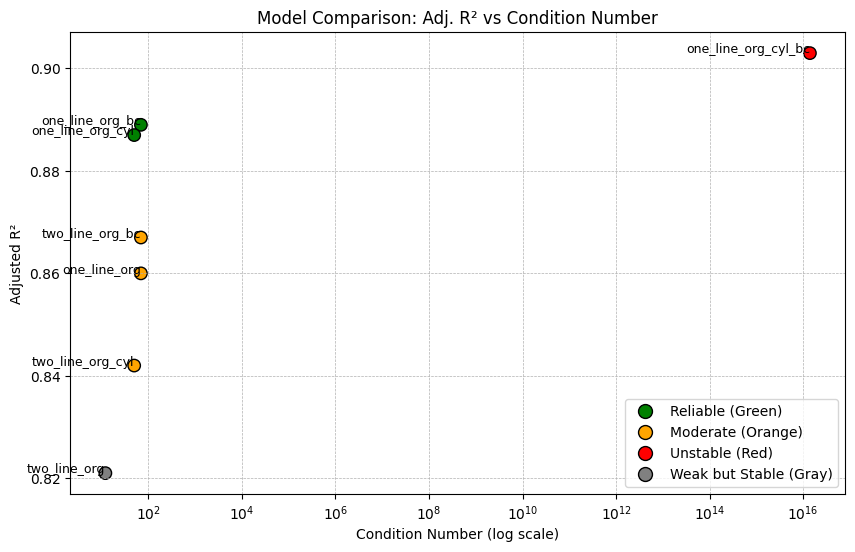

In [21]:
# Model results (Adj. R² and Condition Number)
models = {
    "two_line_org": {"adj_r2": 0.821, "cond_num": 12.12, "verdict": "gray"},
    "two_line_org_bc": {"adj_r2": 0.867, "cond_num": 69.68, "verdict": "yellow"},
    "one_line_org": {"adj_r2": 0.860, "cond_num": 69.68, "verdict": "yellow"},
    "one_line_org_bc": {"adj_r2": 0.889, "cond_num": 69.68, "verdict": "green"},
    "one_line_org_cyl": {"adj_r2": 0.887, "cond_num": 50.01, "verdict": "green"},
    "two_line_org_cyl": {"adj_r2": 0.842, "cond_num": 50.01, "verdict": "yellow"},
    "one_line_org_cyl_bc": {"adj_r2": 0.903, "cond_num": 1.39e16, "verdict": "red"},
}

# Color mapping
color_map = {
    "green": "green",
    "yellow": "orange",
    "red": "red",
    "gray": "gray"
}

# Extract values
x = [v["cond_num"] for v in models.values()]
y = [v["adj_r2"] for v in models.values()]
labels = list(models.keys())
colors = [color_map[v["verdict"]] for v in models.values()]

# Plot
plt.figure(figsize=(10,6))
plt.scatter(x, y, c=colors, s=80, edgecolors="black")

# Annotate points
for i, label in enumerate(labels):
    plt.text(x[i], y[i], label, fontsize=9, ha="right")

plt.xscale("log")  # log scale for condition number
plt.xlabel("Condition Number (log scale)")
plt.ylabel("Adjusted R²")
plt.title("Model Comparison: Adj. R² vs Condition Number")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)

# Legend
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label='Reliable (Green)',
               markerfacecolor='green', markersize=10, markeredgecolor="black"),
    plt.Line2D([0], [0], marker='o', color='w', label='Moderate (Orange)',
               markerfacecolor='orange', markersize=10, markeredgecolor="black"),
    plt.Line2D([0], [0], marker='o', color='w', label='Unstable (Red)',
               markerfacecolor='red', markersize=10, markeredgecolor="black"),
    plt.Line2D([0], [0], marker='o', color='w', label='Weak but Stable (Gray)',
               markerfacecolor='gray', markersize=10, markeredgecolor="black"),
]
plt.legend(handles=legend_elements, loc="lower right")

plt.show()

So the chart visually confirms what the numeric table suggested: Box‑Cox transformed one‑line models (especially one_line_org_bc) are the most reliable performers overall.


#### 1.11 Residual Diagnostics:

Additions nots:

Residual analysis builds on several mathematical foundations. To interpret results correctly, we should first review a few essential terms and concepts.



#### Residual Diagnostics

1. Durbin–Watson statistic (DW):

 Used in regression analysis to detect autocorrelation (serial correlation) in the residuals. The DW statistic tests whether residuals are correlated with their immediate lag (residual at time $t$ vs residual at time $t-1$). If autocorrelation exists, OLS estimates are still unbiased, *but standard errors are wrong, leading to misleading t‑tests and F‑tests*.

Formula
$DW=\frac{\sum _{t=2}^n(e_t-e_{t-1})^2}{\sum _{t=1}^ne_t^2}$
- $e_t$ = residual at observation $t$
- Numerator = squared differences between consecutive residuals
- Denominator = sum of squared residuals

##### DW ranges from 0 to 4:
- ≈ 2 → No autocorrelation (ideal).
- < 2 → Positive autocorrelation (residuals follow each other).
- $>$ 2 → Negative autocorrelation (residuals alternate signs).
- Extreme values (close to 0 or 4) indicate strong correlation patterns.

#### Jarque–Bera (JB) test:

Used to check whether a dataset (often regression residuals) follows a normal distribution. It focuses on two key aspects of normality: skewness and kurtosis. Many statistical methods (OLS regression, t‑tests, F‑tests) assume normality of residuals. If residuals are not normal, inference (confidence intervals, hypothesis tests) may be invalid.

The JB test statistic is:

$JB=\frac{n}{6}\left( S^2+\frac{1}{4}(K-3)^2\right)$ 

where
- $n$ = number of observations
- $S$ = sample skewness (measure of symmetry; normal distribution has $S$=0)
- $K$ = sample kurtosis (measure of tail heaviness; normal distribution has $K$=3)

- JB ≈ 0 → residuals are close to normal (skewness ≈ 0, kurtosis ≈ 3).
- Large JB value → residuals deviate from normality.
- The test is usually compared against a chi‑square distribution with 2 degrees of freedom.
- p‑value > 0.05 → fail to reject normality (data may be normal).
- p‑value < 0.05 → reject normality (data is not normal).

#### Omnibus test for normality:

Omnibus test for normality is a joint test that evaluates whether a dataset deviates from a normal distribution by combining information about skewness and kurtosis.

- Null Hypothesis
    - $H_0$: The data are drawn from a normal distribution (skewness = 0, kurtosis = 3).
    - $H_1$: The data are not normally distributed (skewness or kurtosis significantly different)

- The p-value is the probability of observing a test statistic as extreme as (or more extreme than) the one calculated, assuming $H_0$ is true.
- For both JB and K² tests:
$p=1-F_{\chi ^2(2)}(T)$
- where T is the test statistic (JB or K²), and $F_{\chi ^2(2)}$ is the cumulative distribution function of the chi-square distribution with 2 degrees of freedom.

- p-value test:
    - The p-value is the probability of observing a test statistic as extreme as (or more extreme than) the one calculated, assuming $H_0$ is true.
    - For both JB and K² tests:
    $p=1-F_{\chi ^2(2)}(T)$
    - where T is the test statistic (JB or K²), and $F_{\chi ^2(2)}$ is the cumulative distribution function of the chi-square distribution with 2 degrees of freedom.



In [22]:
def regression_diagnostics(residuals):
    results = {}

    # Durbin-Watson
    results["durbin_watson"] = stattools.durbin_watson(residuals)

    # Jarque-Bera (returns statistic, p-value, skew, kurtosis)
    jb_stat, jb_pvalue, skew, kurtosis = stattools.jarque_bera(residuals)
    results["jarque_bera_stat"] = round(jb_stat,4)
    results["jarque_bera_pvalue"] = round(jb_pvalue,4)

    # Omnibus normality test (returns statistic, p-value)
    omni_stat, omni_pvalue = stattools.omni_normtest(residuals)
    results["omni_normtest_stat"] = round(omni_stat,4)
    results["omni_normtest_pvalue"] = round(omni_pvalue,4)

    # Robust measures (if available in your version)
    try:
        results["medcouple"] = np.round(stattools.medcouple(residuals),6)
    except Exception:
        results["medcouple"] = None   

    return pd.Series(results)

In [23]:
dfResidualsAnalysis = pd.DataFrame({})

diagnostics = regression_diagnostics(res_two_line_org.resid)
dfResidualsAnalysis['two_line_org'] = diagnostics
dfResidualsAnalysis.index = diagnostics.index

diagnostics = regression_diagnostics(res_two_line_org_bc.resid)
dfResidualsAnalysis['two_line_org_bc'] = diagnostics

diagnostics = regression_diagnostics(res_one_line_org.resid)
dfResidualsAnalysis['one_line_org'] = diagnostics

diagnostics = regression_diagnostics(res_one_line_org_bc.resid)
dfResidualsAnalysis['one_line_org_bc'] = diagnostics

diagnostics = regression_diagnostics(res_one_line_org_cyl.resid)
dfResidualsAnalysis['one_line_org_cyl'] = diagnostics

diagnostics = regression_diagnostics(res_two_line_org_cyl.resid)
dfResidualsAnalysis['two_line_org_cyl'] = diagnostics

diagnostics = regression_diagnostics(res_one_line_org_cyl_bc.resid)
dfResidualsAnalysis['one_line_org_cyl_bc'] = diagnostics

# Save DataFrame as text table into Notepad file
with open("residuals_analysis01.txt", "w") as fwr:
    fwr.write(dfResidualsAnalysis.to_string(index=True))

#### 1.12 Four skewness measures in Kim & White

These measures are designed to be less sensitive to outliers and non-normality than the classical skewness statistic.

- sk1: The conventional skewness estimator (based on third standardized moment).
- sk2: Quartile-based skewness
    - $SK2=\frac{(Q_{0.75}-Q_{0.5})-(Q_{0.5}-Q_{0.25})}{Q_{0.75}-Q_{0.25}}$
    - This compares distances between quartiles, making it robust to extreme values.
- sk3: Mean–median difference standardized by mean absolute deviation
    - $SK3=\frac{\mu -\mathrm{median}}{E[|y-\mu |]}$
    - Captures asymmetry using central tendency differences.
- sk4: Mean–median difference standardized by standard deviation
    - $SK4=\frac{\mu -\mathrm{median}}{\sigma }$

Kurtosis Measures (Kim & White):

They also propose robust kurtosis measures based on quantile ranges:
- Moors’ Kurtosis (Octile-based)
    - $K_M=\frac{(P_{87.5}-P_{62.5})+(P_{37.5}-P_{12.5})}{P_{75}-P_{25}}$    
    - Captures tail heaviness without relying on fourth moments.
- Quantile-based Kurtosis (Generalized)
    - $K(p)=\frac{Q_{1-p}-Q_p}{Q_{0.75}-Q_{0.25}}$
    - Ratio of tail spread to interquartile range.
    - Flexible and robust against outliers.


**Traditional skewness/kurtosis** (moment-based) can be misleading in financial data or heavy-tailed distributions. **Kim & White’s measures are robust**, quantile-driven, and resistant to outliers, making them more reliable for empirical work in economics and finance.



In [24]:
def robust_moments(residuals, round_decimals=4):
    """
    Compute Kim & White's robust skewness (sk1–sk4),
    robust kurtosis (kr1–kr4), and expected robust kurtosis.
    
    Parameters
    ----------
    residuals : array-like
        Residuals from an OLS fit or any numeric series.
    round_decimals : int, optional
        Number of decimal places to round results (default=4).
    
    Returns
    -------
    pd.DataFrame
        DataFrame with index ['sk1','sk2','sk3','sk4']
        and columns ['rbst_skew','rbst_kur','rbst_expected_kur'].
    """
    # Initialize
    sk_vals, kr_vals, exp_kur = [None]*4, [None]*4, None
    
    # Robust skewness
    try:
        sk_vals = stattools.robust_skewness(residuals)
    except Exception as e:
        print(f"Error computing robust skewness: {e}")
    
    # Robust kurtosis
    try:
        kr_vals = stattools.robust_kurtosis(residuals)
    except Exception as e:
        print(f"Error computing robust kurtosis: {e}")
    
    # Expected robust kurtosis
    try:
        exp_kur = stattools.expected_robust_kurtosis(len(residuals))
    except Exception as e:
        #print(f"Not Suported computing expected robust kurtosis: {e}")
        pass
    
    # Apply rounding to numeric values
    def safe_round(val):
        return round(val, round_decimals) if isinstance(val, (int, float)) else val
    
    sk_vals = [safe_round(v) for v in sk_vals]
    kr_vals = [safe_round(v) for v in kr_vals]
    exp_kur = safe_round(exp_kur)
    
    # Build DataFrame
    dfRobustSkew = pd.DataFrame({
        "rbst_skew": sk_vals,
        "rbst_kur": kr_vals,
        "rbst_expected_kur": [exp_kur]*4
    }, index=["sk1","sk2","sk3","sk4"])    
    return dfRobustSkew

In [25]:
tableDispFormatt('Model: two_line_org')
print(robust_moments(res_two_line_org.resid))

tableDispFormatt('Model: two_line_org_bc')
print(robust_moments(res_two_line_org_bc.resid))

tableDispFormatt('Model: one_line_org')
print(robust_moments(res_one_line_org.resid))

tableDispFormatt('Model: one_line_org_bc')
print(robust_moments(res_one_line_org_bc.resid))

tableDispFormatt('Model: one_line_org_cyl')
print(robust_moments(res_one_line_org_cyl.resid))

tableDispFormatt('Model: two_line_org_cyl')
print(robust_moments(res_two_line_org_cyl.resid))

tableDispFormatt('Model: one_line_org_cyl_bc')
print(robust_moments(res_one_line_org_cyl_bc.resid))

=============================== Model: two_line_org ========================================
     rbst_skew  rbst_kur rbst_expected_kur
sk1     0.4437    1.1498              None
sk2     0.0255   -0.0670              None
sk3     0.0392    0.2688              None
sk4     0.0301    0.4173              None
=============================== Model: two_line_org_bc =====================================
     rbst_skew  rbst_kur rbst_expected_kur
sk1    -0.1237    0.5660              None
sk2    -0.0327    0.1742              None
sk3    -0.0224    0.2233              None
sk4    -0.0172    0.5698              None
=============================== Model: one_line_org ========================================
     rbst_skew  rbst_kur rbst_expected_kur
sk1     0.6921    1.9407              None
sk2    -0.0876    0.1115              None
sk3     0.0526    0.4122              None
sk4     0.0388    0.9142              None
=============================== Model: one_line_org_bc =====================

#### 2. Anomaly Detection

#### 2.1 Model Adequacy Checking:

The fitting of the linear regression model, estimation of parameters testing of hypothesis properties of the
estimator, is based on the following major assumptions:
1. The relationship between the study variable and explanatory variables is linear, at least approximately.
2. The error term has zero mean.
3. The error term has a constant variance.
4. The errors are uncorrelated.
5. The errors are normally distributed.

The validity of these assumptions is needed for the results to be meaningful. If these assumptions are violated, the result can be incorrect and may have serious consequences. If these departures are small, the final result may not be changed significantly. But if the deviations are large, the model obtained may become unstable in the sense that a different sample could lead to an entirely different model with opposite conclusions. So such **underlying assumptions have to be verified before attempting to regression modeling**.

##### Checking of the linear relationship between study and explanatory variables (Correlation Plots):

To check the assumption of linearity between the study variable and the explanatory variables, the scatter plot
matrix of the data can be used.

Option to present the scatterplot is
- display the scatterplots in the upper triangular part of the plot matrix.
- Mention the corresponding correlation coefficients in the lower triangular part of the matrix.

Such an arrangement helps in examining of plot and corresponding correlation coefficient together. The
pairwise correlation coefficient should always be interpreted in conjunction with the corresponding scatter
plots because
- the correlation coefficient measures only the linear relationship and
- the correlation coefficient is non-robust, i.e., one or two observations can substantially influence its
value in the data.

#### 2.2 Plot scatter_ellipse

TODO Facing Issue

#### 2.3 Residual analysis:

Residuals are simply the differences between observed values and the fitted (predicted) values from your regression model. In text form, the definition is:

$e_i=y_i-\hat {y}_i,\quad i=1,2,\ldots ,n$

- $y_i$ = actual observed value
- $\hat {y}_i$ = fitted value from the regression
- $e_i$ = residual (the error term for observation i)

Residual analysis is crucial because it helps you check whether your regression assumptions hold:

Residuals in Ordinary Least Squares (OLS) regression have some important statistical properties:

**Zero mean**

$E(e_i)=E(y_i-\hat {y}_i)=0$

This means the residuals average out to zero, since the fitted regression line balances the deviations.

**Variance estimate**

The average variance of residuals is estimated by

$\frac{1}{n-k}\sum _{i=1}^ne_i^2=\frac{SS_{res}}{n-k}=MS_{res}$
- where $n$ is the number of observations, $k$ is the number of parameters, $SS_{res}$ is the residual sum of squares, and $MS_{res}$ is the mean square of residuals.

**Non-independence**

Residuals are not fully independent because they have only $n-k$ degrees of freedom. This arises from the fact that the regression model imposes constraints on the residuals.

**Practical implication**

Even though residuals are not independent, this usually does not cause problems for model adequacy checking, provided the sample size $n$ is reasonably large compared to the number of predictors $k$.

The analysis of residuals help in finding the model inadequacies.

#### 2.3.1 Methods for scaling residuals:

Methods for scaling residuals are techniques used in regression diagnostics to make raw residuals more interpretable and comparable across observations. Raw residuals ($e_i=y_i-\hat {y}_i$) can vary in scale depending on leverage, variance, or sample size, so scaling helps standardize them for analysis.

#### 2.3.2 Common methods:

1. **Standardized residuals** are a scaled version of raw residuals that make them easier to interpret and compare across observations.

The definition is:

$d_i=\frac{e_i}{\sqrt{MS_{res}}},\quad i=1,2,\ldots ,n$

- $e_i$ = raw residual for observation i
- $MS_{res}$ = mean square of residuals, an estimate of residual variance
Properties
- $E(d_i)=0$ → standardized residuals have mean zero
- $\mathrm{Var}(d_i)\approx 1$ → they are roughly unit variance
- Large values of $d_i (commonly |d_i|\geq 3)$ suggest potential outliers

2. **Studentized residuals**:

A studentized residual is a standardized version of a residual, specifically designed for outlier detection. Unlike raw residuals, which have different variances depending on the data point's location (leverage), studentized residuals are scaled so they all have a consistent variance.

$r_i=\frac{e_i}{\sqrt{MS_{res}(1-h_{ii})}},\quad i=1,2,\ldots ,n$
- $e_i$ = raw residual for observation $i$
- $MS_{res}$ = mean square residual (an estimate of variance)
- $h_{ii}$ = leverage of observation $i$ (from the hat matrix)

Properties
- They account for the fact that high-leverage points naturally have smaller residuals.
- By dividing by $\sqrt{1-h_{ii}}$, studentized residuals highlight unusual points more clearly.
- Large values (commonly $|r_i|>2$ or $|r_i|>3$) suggest potential outliers.

In many situations, especially with large datasets, the variance of residuals stabilizes. When that happens, there may be little difference between *standardized residuals* ($d_i$) and *studentized residuals* ($r_i$). In such cases, both often convey equivalent information.
However, the distinction becomes important when:
- A point has a large residual, and
- That same point also has large leverage ($h_{ii}$).


#### 2.2.3 Distinction between standardized residuals and studentized residuals

- *Standardized residuals*: simple scaling by overall variance. They give a quick sense of whether residuals are unusually large relative to the model’s error variance.
    - Mean   $E(d_i)=0$
    - Variance $\mathrm{Var}(d_i)\approx 1$
    - Outlier threshold: $|d_i|\geq 3$ often flagged

- *Studentized residuals*: more refined. They recognize that observations with high leverage (influential predictors) naturally shrink residuals, so they adjust for that. This makes them more reliable for spotting true outliers.
    - Mean $E(r_i)=0$
    - $\mathrm{Var}(r_i)\approx 1$, but more precise
    - Better for detecting outliers, especially in high-leverage points
    - Outlier threshold: $|r_i|>2$ or $|r_i|>3$ often flagged.

#### 2.3.4 Regression Variable Hull (RVH) New observation high-leverage points fall within the range of the existing data:

The Regression Variable Hull (RVH) is a geometric concept used in regression diagnostics. It represents the smallest convex set that contains all the original data points:

$x_i=(x_{i1},x_{i2},\ldots ,x_{ik}),\quad i=1,2,\ldots ,n$

RVH helps identify high-leverage points and whether new observations fall within the range of the existing data. It provides a geometric way to assess influence and extrapolation risk in regression models.


- The leverage values $h_{ii}$ depend on the Euclidean distance of each point $x_i$ from the centroid of the predictor space.
- The point with the largest leverage, $h_{\mathrm{max}}$, lies on the boundary of the RVH.
- The set of points x satisfying
$x'(X'X)^{-1}x\leq h_{\mathrm{max}}$
- forms an ellipsoid that encloses all points inside the RVH.
- For a new point $x_0=(x_{01},x_{02},\ldots ,x_{0k})$, its location relative to the RVH is evaluated using
    - $h_{00}=x_0'(X'X)^{-1}x_0$
    - If $h_{00}>h_{\mathrm{max}}$, the point lies outside the ellipsoid (outside the RVH).
    - If $h_{00}<h_{\mathrm{max}}$, the point lies inside the RVH.
    - A smaller value of $h_{00}$ means the point is closer to the centroid of the predictor space.

#### 2.3.5 PRESS statistic:

The PRESS statistic (Predicted Residual Sum of Squares) is a diagnostic measure used in regression analysis to evaluate how well a model predicts new data. It is based on leave-one-out cross-validation.

PRESS is generally regarded as a measure of how well a regression model will perform in predicting new data. A model with a small value of PRESS is desired.

$PRESS=\sum _{i=1}^n\left[ y_i-\hat {y}_{(i)}\right] ^2$

This can also be expressed using leverage values $h_{ii}$:

$PRESS=\sum _{i=1}^n\left( \frac{e_i}{1-h_{ii}}\right) ^2$

where
- $y_i$ = observed value
- $\hat {y}_{(i)}$ = predicted value for y_$i when the model is fit without observation $i
- $e_i$ = residual for observation $i$
- $h_{ii}$ = leverage of observation $i$ (from the hat matrix)

##### 2.3.6 Related measure: Predictive $R^2$
$R_{\mathrm{prediction}}^2=1-\frac{PRESS}{SS_T}$
- $SS_T$ = total sum of squares
- This statistic shows how much variance is explained in a predictive sense, rather than just in-sample fit

- ***Smaller PRESS*** → better predictive performance.
- **Large PRESS residuals** → indicate influential or poorly predicted points.
- $R_{\mathrm{prediction}}^2$ is often lower than the usual $R^2$, since it reflects out-of-sample predictive ability.

This makes PRESS especially useful for model selection and diagnostics, because it avoids the optimistic bias of ordinary residuals.


In [26]:
def compute_residuals(res):
    """
    Compute raw residuals and standardized residuals.
    """     
    dfStandardizedResid = pd.DataFrame()
    dfStandardizedResid['ei'] = res.resid
    dfStandardizedResid['di'] = res.resid / np.sqrt(res.mse_resid)  # standardized residuals
    return dfStandardizedResid

def compute_studentized_residuals(res):
    """
    Compute studentized residuals (internal and external).
    """
    infl = OLSInfluence(res)
    dfRstudent = pd.DataFrame()
    dfRstudent['ri_internal'] = infl.resid_studentized_internal
    dfRstudent['ri_external'] = infl.resid_studentized_external  # R-student
    return dfRstudent

def compute_leverage_and_press(res):
    """
    Compute leverage (hat matrix diagonal) and PRESS residuals/statistic.
    """
    infl = OLSInfluence(res)
    dfPress = pd.DataFrame()
    dfPress['hii'] = infl.hat_matrix_diag
    dfPress['press_resid'] = infl.resid_press
    dfPress['PRESS'] = np.square(res.resid / (1 - infl.hat_matrix_diag))
    return dfPress

def collect_all_diagnostics(res):
    """
    Wrapper to collect all diagnostics in one DataFrame.
    """
    infl = OLSInfluence(res)
    h_bar = 2 * (res.df_model + 1) / res.nobs  # average leverage

    dfResidAnalysis = pd.DataFrame()
    dfResidAnalysis['ei'] = res.resid
    dfResidAnalysis['di'] = res.resid / np.sqrt(res.mse_resid)
    dfResidAnalysis['ri_internal'] = infl.resid_studentized_internal
    dfResidAnalysis['ri_external'] = infl.resid_studentized_external
    dfResidAnalysis['hii'] = infl.hat_matrix_diag
    dfResidAnalysis['press_resid'] = infl.resid_press
    dfResidAnalysis['PRESS'] = np.square(res.resid / (1 - infl.hat_matrix_diag))
    dfResidAnalysis['h_bar'] = h_bar
    return dfResidAnalysis



In [27]:
dfResidAnalysis = collect_all_diagnostics(res_one_line_org_bc)
h_bar = 2 * (res_one_line_org_bc.df_model + 1) / res_one_line_org_bc.nobs

#### 2.4 Find Outliear:
$h_{ii}$ > $\hat h$ ==> Outliear

In [28]:
outliear_standrd_res = dfResidAnalysis.loc[dfResidAnalysis['hii'] > h_bar]
index_standerd_res = outliear_standrd_res.index.values
residuals_disp = False
tableDispFormatt('Outliear Index')
print('Residuals Cutoff Points: ',round(h_bar,3),' \nOutliear Index are : \n',outliear_standrd_res.index.values + 1)
for idx in outliear_standrd_res.index.values:
    if residuals_disp == True:
        print(dfResidAnalysis.loc[idx:idx+1,:])

=============================== Outliear Index =============================================
Residuals Cutoff Points:  0.107  
Outliear Index are : 
 [ 14  20  24  29  51  52  55  56  60  72 109 112 118 124 132 145 172 210
 211 212 242 244 276 277 278 298 300 320 327 328 329 330 334 335 359 360
 361 362 363 376 381 391 395]


#### 2.5 Standardized residuals threshold ( $|d_i|\geq 3$)


In [29]:
# Detect outliers based on standardized residuals
outliers_std_res = dfResidAnalysis.loc[np.abs(dfResidAnalysis['di']) >= 3]
index_std_res = outliers_std_res.index.values

residuals_disp = False
tableDispFormatt('Outlier Index Due to Standardized Residuals')

print('Standard Residuals Cutoff: |di| >= 3',
      '\nOutlier Index are:\n', index_std_res)

for idx in index_std_res:
    if residuals_disp:
        print(dfResidAnalysis.loc[idx:idx+1, :])


=============================== Outlier Index Due to Standardized Residuals ================
Standard Residuals Cutoff: |di| >= 3 
Outlier Index are:
 [166 322 364 387]


#### 2.6 Studentized residuals conventional threshold is $|r_i|>2$ or $|r_i|>3$

Adjust the threshold to 2 if you want a more sensitive detection.


In [30]:
# Detect outliers based on studentized residuals
outliers_student_res = dfResidAnalysis.loc[np.abs(dfResidAnalysis['ri_internal']) >= 3]
index_student_res = outliers_student_res.index.values

residuals_disp = False
tableDispFormatt('Outlier Index Due to Studentized Residuals')

print('Studentized Residuals Cutoff: |ri| >= 3',
      '\nOutlier Index are:\n', index_student_res)

for idx in index_student_res:
    if residuals_disp:
        print(dfResidAnalysis.loc[idx:idx+1, :])

=============================== Outlier Index Due to Studentized Residuals =================
Studentized Residuals Cutoff: |ri| >= 3 
Outlier Index are:
 [166 322 364 387]


#### 2.7 Cook’s Distance (Cook’s D):

Cook’s Distance (Cook’s D) is a regression diagnostic that measures how much influence each observation has on the fitted regression model. It combines information about residual size and leverage.

Cook’s D for observation $i$ is:

$D_i=\frac{(\hat {\beta }-\hat {\beta }_{(i)})'X'X(\hat {\beta }-\hat {\beta }_{(i)})}{p\cdot \hat {\sigma }^2}$

- $\hat {\beta }$ = estimated regression coefficients using all data
- $\hat {\beta }_{(i)}$ = estimated coefficients with observation i deleted
- $X$ = design matrix
- $p$ = number of predictors (including intercept)
- $\hat {\sigma }^2$ = mean squared error
This measures the squared distance between the full-model coefficients and the leave-one-out coefficients, scaled by variance

- Cook’s D can be computed more directly as:

$D_i=\frac{r_i^2}{p}\cdot \frac{h_{ii}}{1-h_{ii}}$

- $r_i$ = studentized residual for observation i
- $h_{ii}$ = leverage of observation i (diagonal of the hat matrix)
- $p$ = number of predictors

- *Small $D_i$* → observation has little influence.
- *Large $D_i$* → observation strongly affects regression coefficients.
- Rule of thumb:
    - $D_i>1$ often indicates a highly influential point.
    - Some use $D_i>\frac{4}{n}$ (where $n$ is sample size) as a cutoff

Cook’s D asks: “If I remove this point, how much do my regression coefficients change?”
- High residuals alone don’t guarantee influence (low-leverage points may not matter).
- High leverage alone doesn’t guarantee influence (if residual is small, the point fits well).
- Cook’s D combines both to flag points that are both unusual and impactful.

#### Cook’s Distance (D_i) is assessed by comparing its magnitude to an F-distribution cutoff

The influence of data points in regression analysis is measured using the statistic D_i. Its magnitude is assessed by comparing it to an F-distribution $F_{\alpha ,p,n-p}$. If $D_i=F_{0.5,p,n-p}$, then deleting point $i$ would move $\hat {\beta }_{(i)}$ to the boundary of an approximate $50%$ confidence region for $\beta$ . This indicates a large displacement and shows that the least-squares estimate is sensitive to the ith data point. Since $F_{0.5,p,n-p}=1$, points for which $D_i>1$ are usually considered influential. A cutoff of unity is recommended because of the similarity of $D_i$ to the equation for the normal-theory confidence ellipsoid. Although $D_i$ is not an F statistic, the cutoff of unity works well in practice.

In practice, when $F_{0.5,p,n-p}=1$  points with $D_i>1$ are usually considered influential. Cook’s D is not itself an F-statistic, but the comparison to the F-distribution provides a theoretical basis for cutoff values. Cook’s D is not itself an F-statistic, but the comparison to the F-distribution provides a theoretical basis for cutoff values.

#### Guidelines commonly used for assessing influence with $D_i$:
- If $D_i>0.5$, the $i^{th}$ data point is worthy of further investigation as it may be influential.
- If $D_i>1$, the $i^{th}$ data point is quite likely to be influential.
- If $D_i$ sticks out like a sore thumb compared to the other $D_i$ values, it is almost certainly influential


- Interpreting Cook's Distance:
    - High Cook's Distance:
        -   Indicates that the observation has a significant impact on the regression model's results. Removing it would lead to noticeable changes in the regression coefficients and predicted values.

    - Low Cook's Distance:
        -   Suggests that the observation has minimal influence on the model, and its removal would not significantly alter the results.

In [31]:
def cooks_distance(res, threshold=1.0):
    """
    Computes Cook's Distance and returns indices of influential points.
    
    Parameters:
        res (RegressionResultsWrapper): Fitted OLS model
        threshold (float): Cutoff for influence (default 0.5)
    
    Returns:
        dict: Dictionary with Cook’s D values and indices above thresholds
    """
    infl = res.get_influence()
    cooks_d = infl.summary_frame()['cooks_d']
    ser = pd.Series(cooks_d.tolist())
    indices_gt_threshold = ser.loc[ser > threshold].index.values + 1
    indices_gt_1 = ser.loc[ser > 1.0].index.values + 1
    results = {
        #"cooks_d_values": ser,
        "indices_gt_threshold": indices_gt_threshold if len(indices_gt_threshold) > 0 else "No influential points found (threshold)",
        "indices_gt_1": indices_gt_1 if len(indices_gt_1) > 0 else "No influential points found (>1)"

    }
    return results

def cooks_distance_fstat(res, q_values=[0.92, 0.35,0.20,0.01]):
    """
    Computes Cook’s Distance cutoffs using F-statistic method.
    
    Parameters:
        res (RegressionResultsWrapper): Fitted OLS model
        q_values (list): Quantiles for F distribution
    
    Returns:
        dict: Dictionary with Cook’s D indices for each quantile
    """
    ser = res.get_influence().summary_frame()['cooks_d']
    ser = pd.Series(ser.tolist())

    results = {}
    for q in q_values:
        ssig = f.isf(q=1. - q, dfn=res.df_model, dfd=res.df_resid, loc=0, scale=1)
        indices = ser.loc[ser > ssig].index.values + 1
        results[f"indices_q_{int(q*100)}"] = indices if len(indices) > 0 else f"No influential points found (@ {int(q*100)}%)"
    return results



In [32]:
# Best performing and reliable
cook_results = cooks_distance(res = res_one_line_org_bc,threshold=1.0)
q_values=[0.92, 0.35,0.20,0.01]
fstat_results = cooks_distance_fstat(res = res_one_line_org_bc,q_values=q_values)
print("Cook’s Distance Results:", cook_results)
print("F-statistic Method Results:", fstat_results)

Cook’s Distance Results: {'indices_gt_threshold': 'No influential points found (threshold)', 'indices_gt_1': 'No influential points found (>1)'}
F-statistic Method Results: {'indices_q_92': 'No influential points found (@ 92%)', 'indices_q_35': 'No influential points found (@ 35%)', 'indices_q_20': 'No influential points found (@ 20%)', 'indices_q_1': 'No influential points found (@ 1%)'}


#### 2.8 DFBETAS:

DFBETAS (Difference in Betas) is a diagnostic statistic that measures the specific influence of a single observation on each individual regression coefficient $\beta$.

While *Studentized Residuals* tell you if a point is an outlier, DFBETAS tell you how much your model's "story" (the slopes) would change if you deleted that specific point.

$\mathrm{DFBETAS_{\mathnormal{j,i}}}=\frac{\hat {\beta }_j-\hat {\beta }_{j(i)}}{\sqrt{S_{(i)}^2C_{jj}}}$

This measures how much the regression coefficient $\beta _j$ changes, in standard deviation units, if the $i^{th}$ observation is deleted.

Cutoff Criterion:

$\mathrm{If\  }|\mathrm{DFBETAS_{\mathnormal{j,i}}}|>\frac{2}{\sqrt{n}},\mathrm{\  then\  the\  }i^{th}\mathrm{\  observation\  warrants\  examination.}$

#### 2.9 DFFITS:

*DFFITS* (Difference in Fits) is a diagnostic statistic that measures how much a single observation influences its own predicted value.
While *DFBETAS* focuses on the individual regression coefficients (the slopes), DFFITS looks at the "bottom line": *If I delete this observation, how much does the model's prediction for this specific point move?*
 

$DFFITS_i=\left( \frac{h_{ii}}{1-h_{ii}}\right) ^{1/2}\frac{e_i}{S_{(i)}(1-h_{ii})^{1/2}}=\left( \frac{h_{ii}}{1-h_{ii}}\right) ^{1/2}t_i$

**Cutoff Criterion:**

Welsch suggests that any observation for which

$|\mathrm{DFFITS_{\mathnormal{i}}}|>2\sqrt{\frac{p}{n}}$ warrants attention.

DFFITS and Cook’s Distance are both measures used to identify influential data points in regression analysis. They assess the impact of removing an observation on the model’s fitted values. DFFITS focuses on the change in predicted values for a specific observation. Cook’s Distance considers the overall influence of an observation on all predicted values.


In [33]:
def dffits_influence(res):
    """
    Computes DFFITS values and flags influential observations.
    
    Parameters:
        res (RegressionResultsWrapper): Fitted OLS model (result of OLS.fit())
    
    Returns:
        dict: Dictionary containing DFFITS values, cutoff, and indices above cutoff
    """
    k = res.df_model
    p = k + 1
    cutoff = 2.0 * np.sqrt(p / res.nobs)

    infl = res.get_influence()
    dffits = infl.summary_frame()['dffits']

    indices = dffits.loc[np.abs(dffits) > cutoff].index.values + 1

    results = {
        #"dffits_values": dffits,
        "cutoff": cutoff,
        "indices_gt_cutoff": indices if len(indices) > 0 else "No influential points found"
    }
    return results

def dfbetas_influence(res):
    """
    Computes DFBETAS values and flags influential observations for each regressor.
    
    Parameters:
        res (RegressionResultsWrapper): Fitted OLS model (result of OLS.fit())
    
    Returns:
        pd.DataFrame: DataFrame with regressor names, cutoff, and influential indices
    """
    cutoff = 2.0 / np.sqrt(res.nobs)

    infl = res.get_influence()
    clm_name = infl.summary_frame().columns.values.tolist()

    # Collect only DFBETAS columns (exclude cooks_d and later influence measures)
    dfbetas_name = []
    for idx in clm_name:
        if idx == 'cooks_d':
            break
        dfbetas_name.append(idx)

    dfbetas = infl.summary_frame()[dfbetas_name]

    # Build structured results
    records = []
    for idx in dfbetas_name:
        indices = dfbetas.loc[np.abs(dfbetas[idx]) > cutoff].index.values + 1
        if len(indices) > 0:
            records.append({"regressor": idx, "cutoff": cutoff, "influential_points": indices})
        else:
            records.append({"regressor": idx, "cutoff": cutoff, "influential_points": "No influential points found"})

    # Convert to DataFrame
    results_df = pd.DataFrame(records)
    return results_df


In [34]:
dffits_results = dffits_influence(res = res_one_line_org_bc)
print("DFFITS Results:", dffits_results)

dfbetas_results = dfbetas_influence(res = res_one_line_org_bc)

#print("DFBETAS Results:", dfbetas_results)
# Save DataFrame as text table into Notepad file
with open("DFBETAS_result.txt", "w") as fwr:
    fwr.write(dfbetas_results.to_string(index=True))

DFFITS Results: {'cutoff': np.float64(0.4629100498862757), 'indices_gt_cutoff': array([ 14,  21,  23,  24,  51,  53,  55,  60, 103, 109, 112, 125, 156,
       167, 210, 211, 242, 271, 276, 277, 278, 298, 299, 301, 310, 323,
       325, 327, 328, 330, 333, 334, 335, 361, 365, 378, 388])}


#### 2.10 COVRATIO:

COVRATIO (Covariance Ratio) is a regression diagnostic that measures how the inclusion or exclusion of a single observation affects the precision of the estimated regression coefficients. It looks at changes in the variance–covariance matrix of the regression parameters when an observation is removed.

$\mathrm{COVRATIO_{\mathnormal{i}}}=\left( \frac{S_{(i)}^2}{MS_{Res}}\right) \left( \frac{1}{1-h_{ii}}\right)$ 
- $h_{ii}$: leverage of the $i^{th}$ observation
- $\frac{1}{1-h_{ii}}$: ratio of $|(X'_{(i)}X_{(i)})^{-1}|\ to\ |(X'X)^{-1}|$
- $S_{(i)}^2$: variance estimate with the i^{th} observation deleted
- $MS_{Res}$: mean squared residuals from the full model

- $COVRATIO{}_i>1$ → the observation improves precision (reduces variance of estimates).
- $COVRATIO{}_i<1$ → the observation degrades precision (increases variance of estimates).


Complements other diagnostics: While Cook’s Distance, DFFITS, and DFBETAS focus on influence on fitted values or coefficients, COVRATIO specifically evaluates the effect on precision of estimation. Detects stabilizing vs. destabilizing points, Some data points may not shift coefficients much but can still inflate variances, making estimates less reliable. Robust model assessment By combining COVRATIO with other influence measures, analysts get a fuller picture of whether a point is influential due to leverage, residual size, or its effect on variance




In [35]:
def covratio_influence(res):
    """
    Computes Covariance Ratio (COVRATIO) and flags influential observations.
    
    Parameters:
        res (RegressionResultsWrapper): Fitted OLS model (result of OLS.fit())
    
    Returns:
        dict: Dictionary with cutoff values, COVRATIO series, and flagged indices
    """
    p = res.df_model + 1  # number of parameters including intercept
    n = res.nobs

    # Cutoff values (Belsley, Kuh, Welsch rule of thumb)
    covratio_cutoff_upr  = 1 + (3 * p / n)
    covratio_cutoff_lowr = 1 - (3 * p / n)

    infl = OLSInfluence(res)
    cov_ser = pd.Series(infl.cov_ratio)

    indices_upr = cov_ser.loc[cov_ser > covratio_cutoff_upr].index.values + 1
    indices_lowr = cov_ser.loc[cov_ser < covratio_cutoff_lowr].index.values + 1

    results = {
        #"covratio_values": cov_ser,
        "upper_cutoff": covratio_cutoff_upr,
        "lower_cutoff": covratio_cutoff_lowr,
        "indices_gt_upper": indices_upr if len(indices_upr) > 0 else "No influential points found (upper cutoff)",
        "indices_lt_lower": indices_lowr if len(indices_lowr) > 0 else "No influential points found (lower cutoff)"
    }
    return results


In [36]:
covratio_results = covratio_influence(res = res_one_line_org_bc)
print("COVRATIO Results:", covratio_results)

COVRATIO Results: {'upper_cutoff': 1.1607142857142858, 'lower_cutoff': 0.8392857142857143, 'indices_gt_upper': array([ 14,  20,  28,  29,  55,  71, 123, 130, 147, 170, 202, 210, 240,
       242, 274, 276, 296, 298, 318, 327, 332, 354, 355, 356, 357, 358,
       370, 375, 385, 389]), 'indices_lt_lower': array([111, 124, 165, 269, 297, 299, 321, 360, 362, 382])}


In [37]:
def influence_dashboard(res):
    """
    Runs Cook's D, residuals, DFFITS, DFBETAS, and COVRATIO diagnostics.
    
    Parameters:
        res (RegressionResultsWrapper): Fitted OLS model (result of OLS.fit())
    
    Returns:
        pd.DataFrame: Consolidated influence diagnostics per observation
    """
    infl = OLSInfluence(res)
    n = res.nobs
    p = res.df_model + 1

    # --- Cook's Distance ---
    cooks_d = infl.cooks_distance[0]
    cooks_flag = np.where(cooks_d > 1, True, False)

    # --- Standardized & Studentized Residuals ---
    std_resid = infl.resid_studentized_internal
    stud_resid = infl.resid_studentized_external
    std_flag = np.where(np.abs(std_resid) > 2, True, False)
    stud_flag = np.where(np.abs(stud_resid) > 2, True, False)

    # --- DFFITS ---
    dffits = infl.dffits[0]
    dffits_cutoff = 2 * np.sqrt(p / n)
    dffits_flag = np.where(np.abs(dffits) > dffits_cutoff, True, False)

    # --- DFBETAS ---
    dfbetas = infl.dfbetas
    dfbetas_cutoff = 2 / np.sqrt(n)
    dfbetas_flag = (np.abs(dfbetas) > dfbetas_cutoff).any(axis=1)

    # --- COVRATIO ---
    covratio = infl.cov_ratio
    covratio_cutoff_upr = 1 + (3 * p / n)
    covratio_cutoff_lowr = 1 - (3 * p / n)
    covratio_flag = np.where((covratio > covratio_cutoff_upr) | (covratio < covratio_cutoff_lowr), True, False)

    # --- Consolidated DataFrame ---
    dfInfluencedashboard = pd.DataFrame({
        "CooksD": cooks_d,
        "CooksD_flag": cooks_flag,
        "StdResid": std_resid,
        "StdResid_flag": std_flag,
        "StudResid": stud_resid,
        "StudResid_flag": stud_flag,
        "DFFITS": dffits,
        "DFFITS_flag": dffits_flag,
        "COVRATIO": covratio,
        "COVRATIO_flag": covratio_flag,
        "DFBETAS_flag": dfbetas_flag
    }, index=np.arange(1, n+1))  # index starts at 1 for observation numbers

    return dfInfluencedashboard

In [38]:
dashboard = influence_dashboard(res_one_line_org_bc)
with open("influence dashboard.txt", "w") as fwr:
    fwr.write(dashboard.to_string(index=True))

# Assuming 'dashboard' is the DataFrame returned by influence_dashboard(res)
# Count True/False per flag column
flag_counts = {}
for col in dashboard.columns:
    if "_flag" in col:  # only look at flag columns
        flag_counts[col] = dashboard[col].value_counts().to_dict()

# Convert to DataFrame for readability
flag_summary = pd.DataFrame(flag_counts).fillna(0).astype(int)

print("Flag frequency per diagnostic:")
print(flag_summary)

# Optional: overall frequency across all flags
overall_counts = dashboard[[c for c in dashboard.columns if "_flag" in c]].stack().value_counts()
#print("\nOverall frequency across all flags:")
#print(overall_counts)

Flag frequency per diagnostic:
       CooksD_flag  StdResid_flag  StudResid_flag  DFFITS_flag  COVRATIO_flag  \
False          392            370             370          355            352   
True             0             22              22           37             40   

       DFBETAS_flag  
False           255  
True            137  


##### We didn't found any influence point in cooks d. But i found Influence point in standard and studentized residual. Also found influence point from dffitts ana covratio. Can you tell me which result are more reliable ?

Different diagnostics don’t always agree, and that’s exactly why statisticians recommend using a suite of influence measures rather than relying on just one. Each of these metrics is "reliable," but they measure different aspects of a data point's impact. The reason you found anomalies in some but not in Cook’s Distance is likely due to the specific sensitivity of each test.

#### Why the Results Differ ?

**Cook’s Distance ($D$)**: Measures the global impact. It asks: "If I remove this point, how much do all predicted values in the dataset change?" Because it averages influence across the entire model, it is often more "conservative." A point might be a massive outlier but not move the entire model enough to cross the common threshold ($D>1$).

**Studentized Residuals**: Measure outlyingness only in the-direction. High values ($usually >|3|$) mean the model is very bad at predicting that specific point. It doesn't necessarily mean the point is "influential" (changing the slope); it just means it's an outlier.

**DFFITS**: Measures local impact. It asks: "If I remove this point, how much does the prediction for this specific point change?" It is much more sensitive than Cook's in identifying points that "pull" the regression line toward themselves.

**COVRATIO**: Measures precision. It checks if a point improves or worsens the stability of your coefficient estimates. A point can have low influence on the slope (low Cook's $D$) but still be a problem because it significantly inflates the standard error of your model.

#### Which is More Reliable?

No single measure is “most reliable.” Each highlights a different aspect of influence. If Cook’s D shows nothing but DFFITS, DFBETAS, or COVRATIO do, it means the point doesn’t globally distort predictions but does affect specific coefficients or variance precision. Consensus across multiple diagnostics is the strongest evidence. For example: A point flagged by studentized residuals + DFFITS + COVRATIO is almost certainly influential, even if Cook’s D is quiet. If only one measure flags it (say, just residuals), you should investigate but not overreact.

![alt text](image-1.png)

When evaluating influence points, we remove outliers one at a time and observe the effect on model performance metrics such as $MS_{res}$, $R^2$, and $R_{adj}^2$.
- If removing an observation improves the model — for example, $MS_{res}$ decreases and the other evaluation metrics move toward more desirable values — then that point is considered not useful. Such points degrade the model’s quality and should be treated as outliers.
- If removing an observation causes the model to perform worse — for example, $MS_{res}$ increases or precision metrics deteriorate — then that point is considered a leverage point. These observations are valuable because they contribute positively to the stability and explanatory power of the model.


####  2.11 Influence plot and Leverage plot


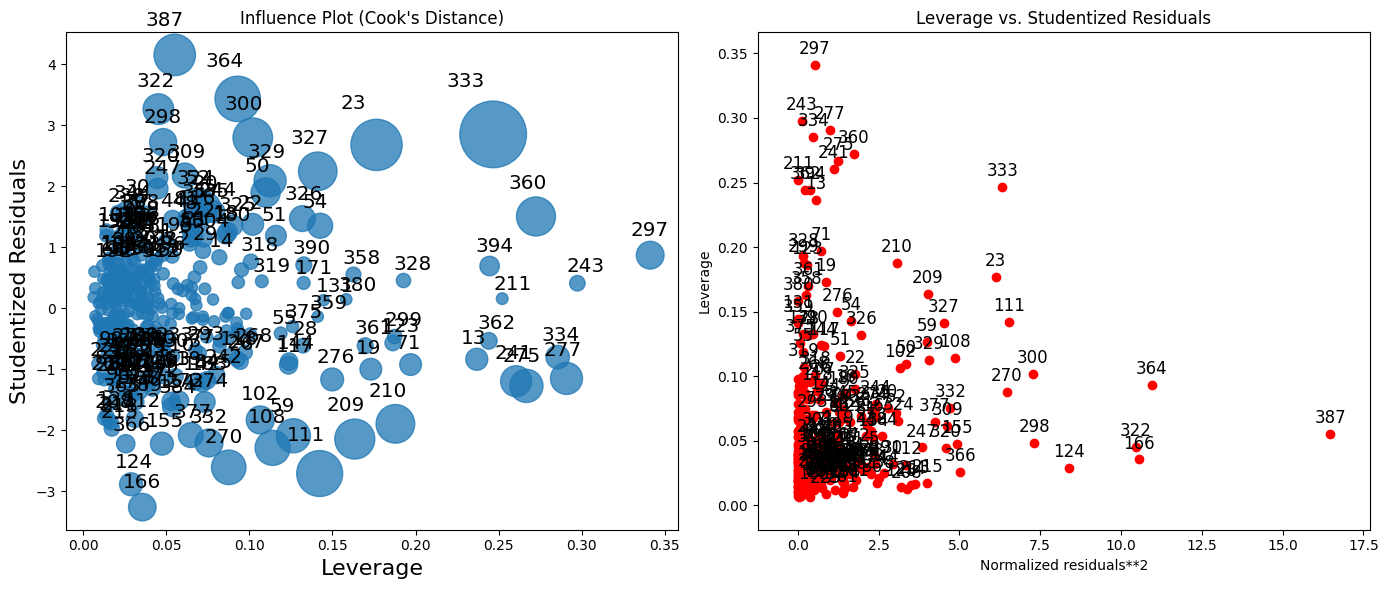

In [39]:
def influence_leverage_plots(res, alpha=0.7, color="blue"):
    """
    Plots influence_plot and plot_leverage_resid2 side by side with custom alpha and color.
    
    Parameters:
        res (RegressionResultsWrapper): Fitted OLS model (result of OLS.fit())
        alpha (float): Transparency level for points (default=0.7)
        color (str): Color for points (default="blue")
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Influence plot
    influence_plot(res, ax=axes[0], criterion="cooks", alpha=alpha, color=color)
    axes[0].set_title("Influence Plot (Cook's Distance)")

    # Leverage vs. Studentized Residuals plot
    plot_leverage_resid2(res, ax=axes[1], alpha=alpha, color=color)
    axes[1].set_title("Leverage vs. Studentized Residuals")

    plt.tight_layout()
    plt.show()

influence_leverage_plots(res = res_one_line_org_bc,alpha=0.5, color="red")

Cook’s Distance shows how much each point shifts the regression.Leverage vs. Residuals shows which points are both unusual and extreme. The labeled points in your plots are the ones you should examine closely  they may be driving your model’s results more than they should.


In [40]:
# Best performing and reliable
cook_results = cooks_distance(res = res_one_line_org_bc,threshold=1.0)
q_values=[0.92, 0.35,0.20,0.01]
fstat_results = cooks_distance_fstat(res = res_one_line_org_bc,q_values=q_values)
print("Cook’s Distance Results:", cook_results)
print("F-statistic Method Results:", fstat_results)

Cook’s Distance Results: {'indices_gt_threshold': 'No influential points found (threshold)', 'indices_gt_1': 'No influential points found (>1)'}
F-statistic Method Results: {'indices_q_92': 'No influential points found (@ 92%)', 'indices_q_35': 'No influential points found (@ 35%)', 'indices_q_20': 'No influential points found (@ 20%)', 'indices_q_1': 'No influential points found (@ 1%)'}


In [41]:
def regression_diagnostics(results, actual, subtitle="Residual Diagnostics"):
    """
    Wrapper function to generate goodness-of-fit plots for residual analysis.
    
    Parameters:
    results (RegressionResultsWrapper): Fitted regression results object from statsmodels
    actual (array-like): Actual observed values
    subtitle (str): Subtitle for the entire figure
    """
    residuals = results.resid
    fitted = results.fittedvalues
    standardized_resid = residuals / residuals.std()
    predicted = results.predict()

    # Compute skewness and kurtosis
    resid_skew = skew(residuals)
    resid_kurt = kurtosis(residuals, fisher=True)  # excess kurtosis

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle(subtitle, fontsize=16)

    # Q-Q Plot of residuals
    sm.qqplot(residuals, line='r', ax=axes[0,0])
    axes[0,0].set_title("Q-Q Plot (Residuals)")

    # P-P Plot of residuals
    probplot = sm.ProbPlot(residuals)
    probplot.ppplot(line='r', ax=axes[0,1])
    axes[0,1].set_title("P-P Plot (Residuals)")

    # Residuals vs Fitted
    axes[0,2].scatter(fitted, residuals, edgecolor='k', alpha=0.7)
    axes[0,2].axhline(0, color='red', linestyle='--')
    axes[0,2].set_xlabel("Fitted values")
    axes[0,2].set_ylabel("Residuals")
    axes[0,2].set_title("Residuals vs Fitted")

    # Histogram with skewness & kurtosis
    sns.histplot(residuals, bins=50, edgecolor='black', kde =True,alpha=0.7,ax = axes[1,0])
    axes[1,0].set_title("Histogram of Residuals")
    axes[1,0].set_xlabel("Residuals")
    axes[1,0].set_ylabel("Frequency")
    stats_text = f"Skewness = {resid_skew:.2f}\nKurtosis = {resid_kurt:.2f}"
    axes[1,0].text(0.95, 0.95, stats_text,
                   transform=axes[1,0].transAxes,
                   fontsize=10, va='top', ha='right',
                   bbox=dict(facecolor='red', alpha=0.7))

    # Scale-Location Plot
    axes[1,1].scatter(fitted, standardized_resid, edgecolor='k', alpha=0.7)
    axes[1,1].axhline(0, color='red', linestyle='--')
    axes[1,1].set_xlabel("Fitted values")
    axes[1,1].set_ylabel("Standardized Residuals")
    axes[1,1].set_title("Scale-Location Plot")

    # QQ Plot: Actual vs Predicted
    qqplot_2samples(actual, predicted, line='r', ax=axes[1,2])
    axes[1,2].set_title("QQ Plot: Actual vs Predicted")
    axes[1,2].set_xlabel("Actual Quantiles")
    axes[1,2].set_ylabel("Predicted Quantiles")

    plt.tight_layout(rect=[0, 0, 1, 1.00])
    plt.show() 

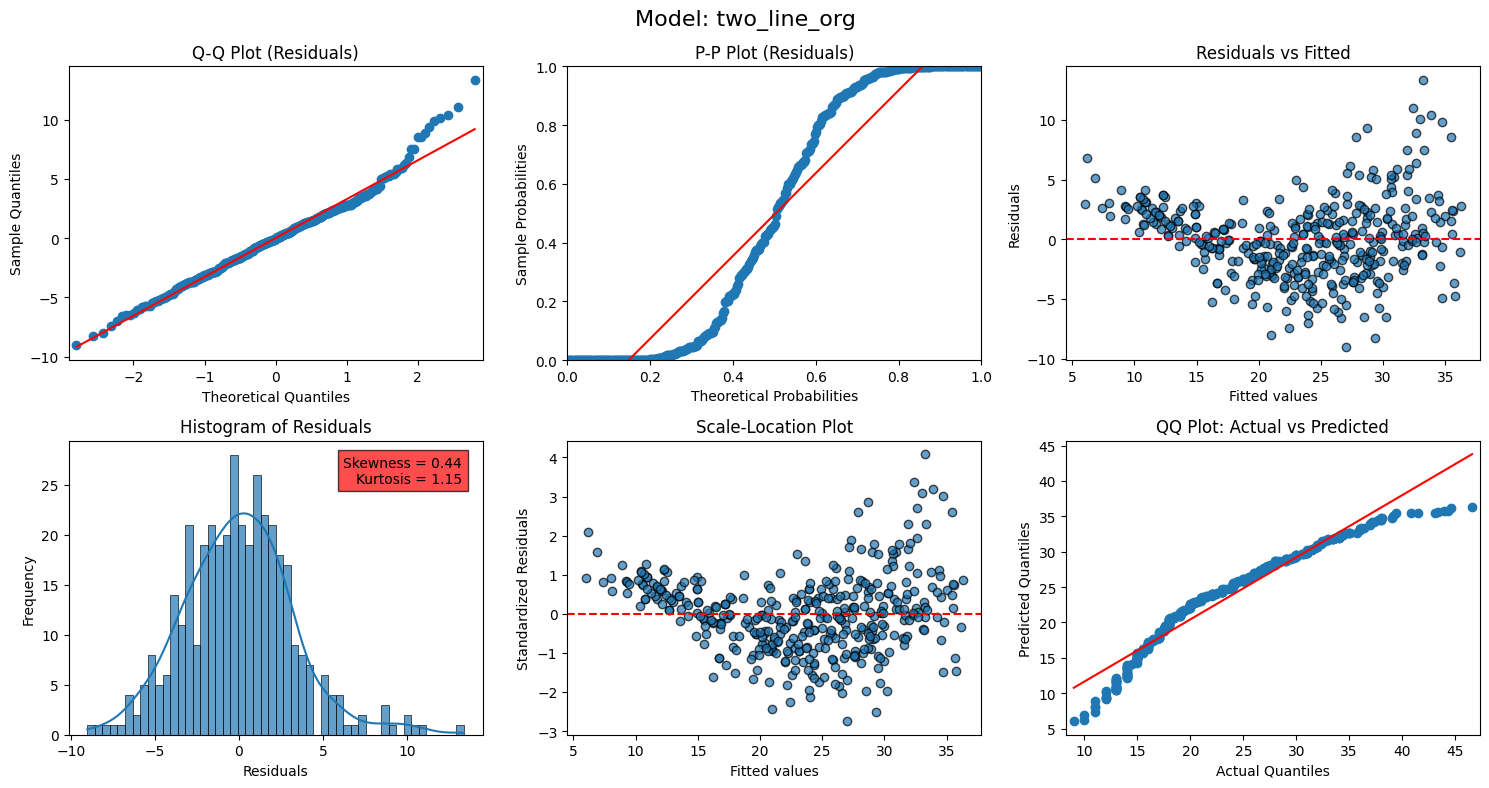

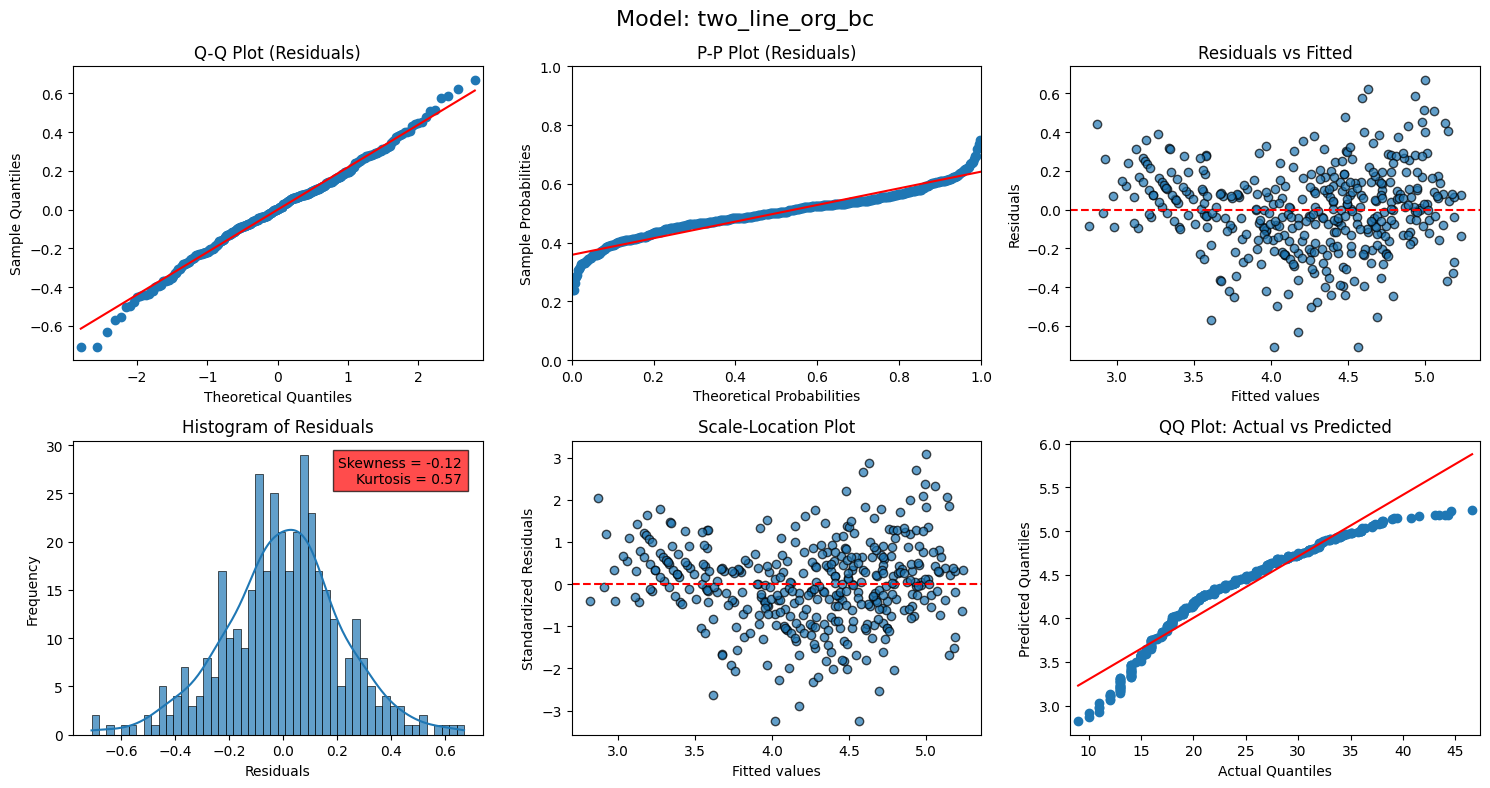

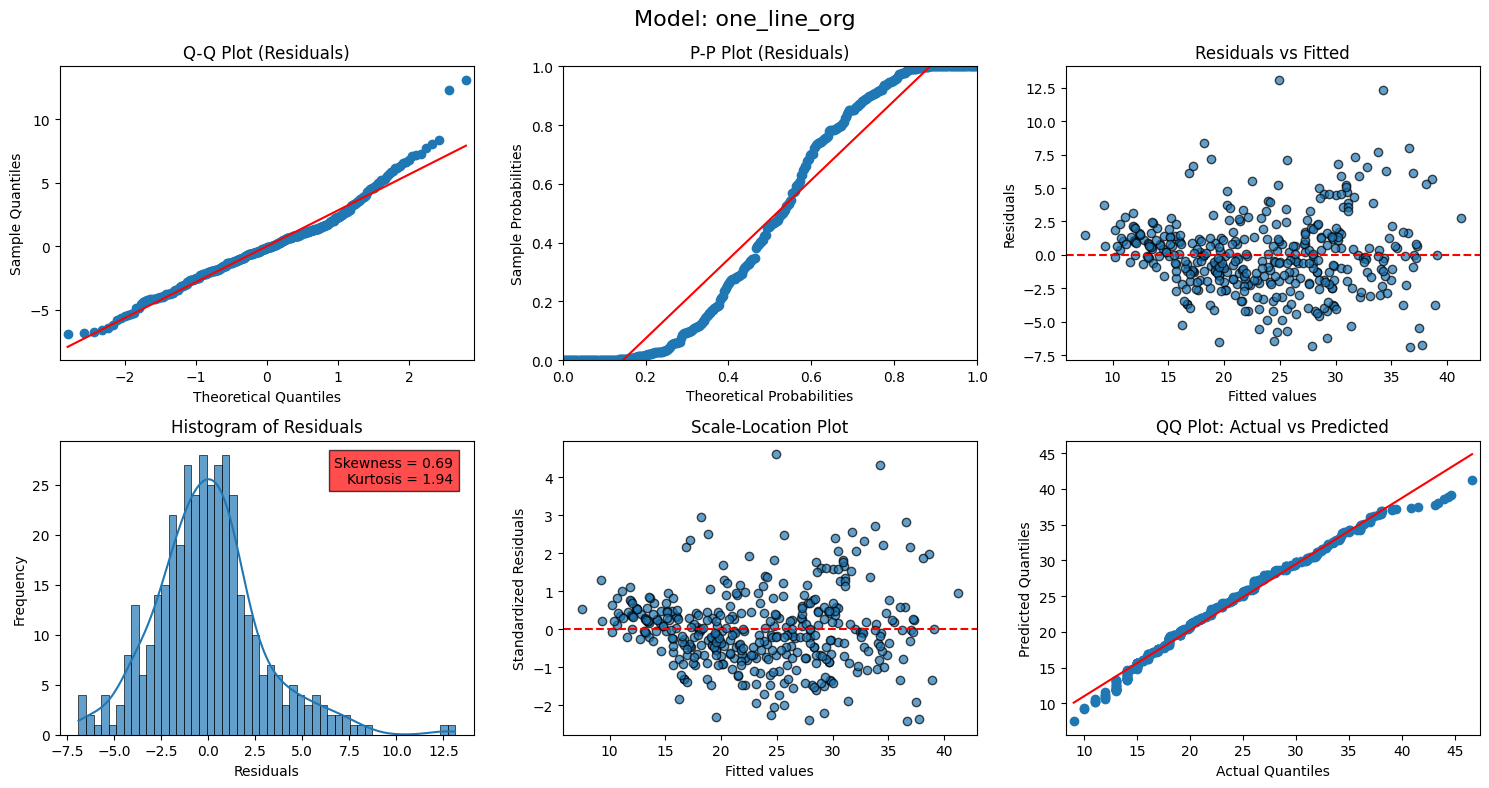

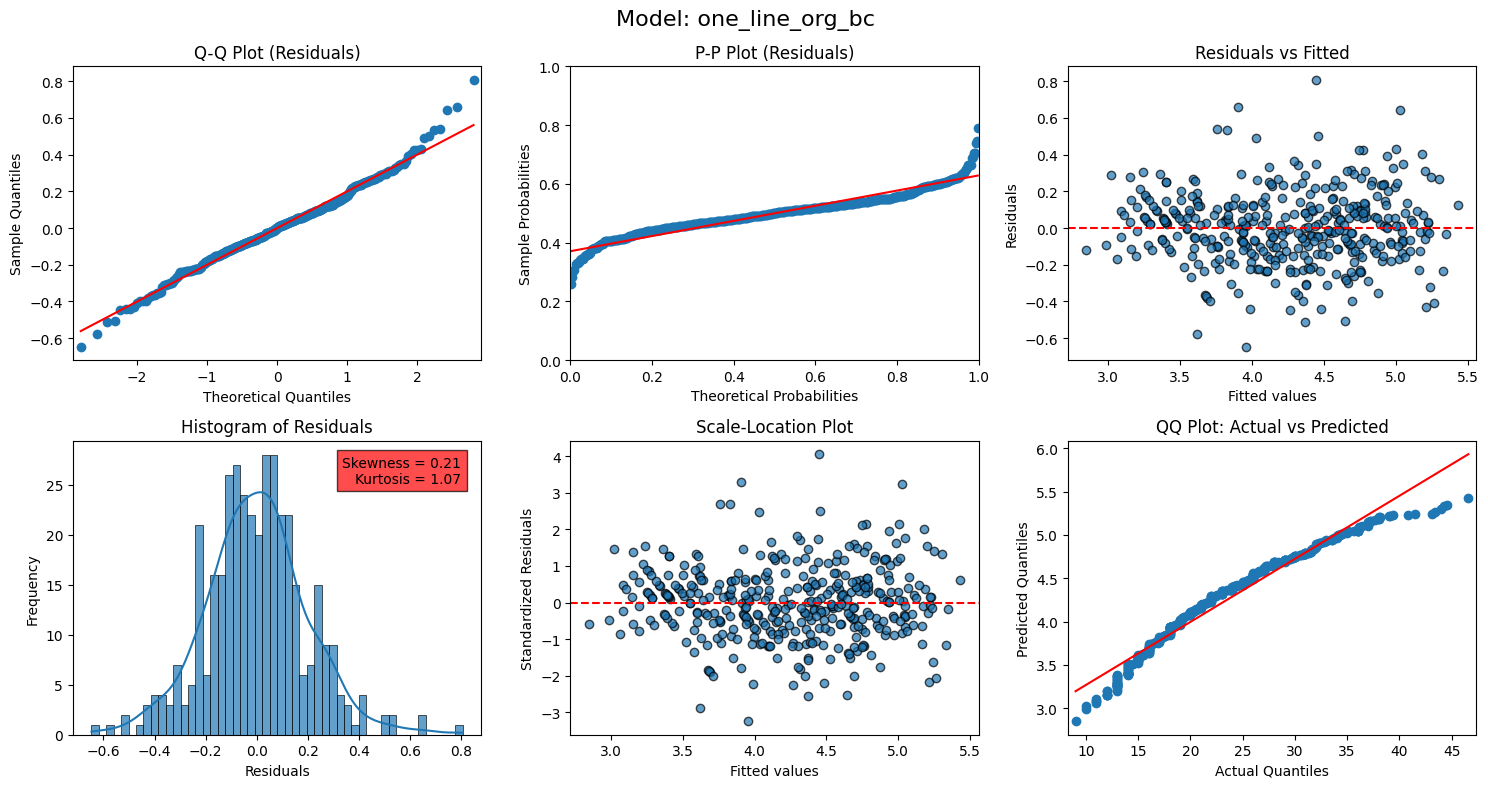

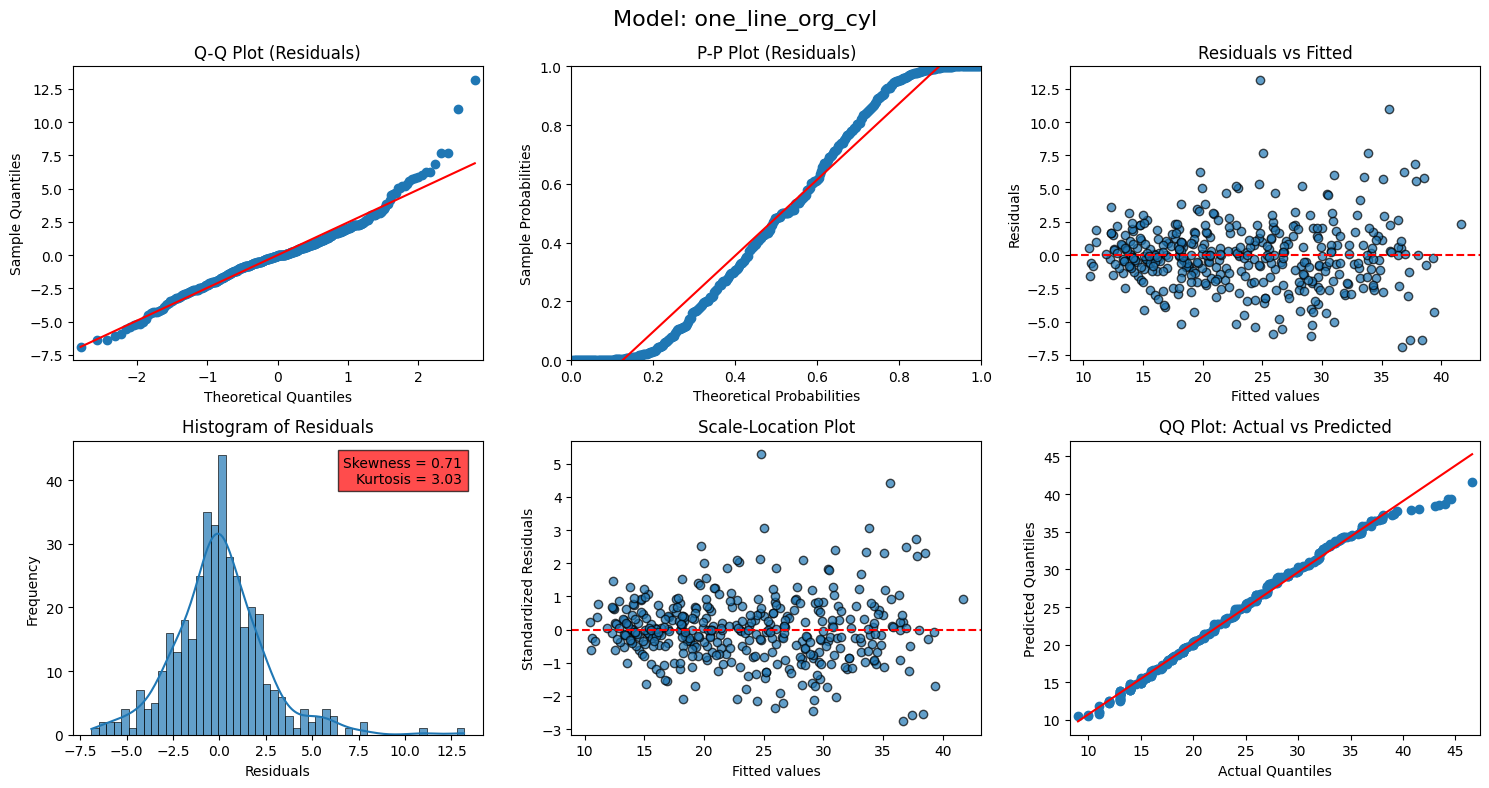

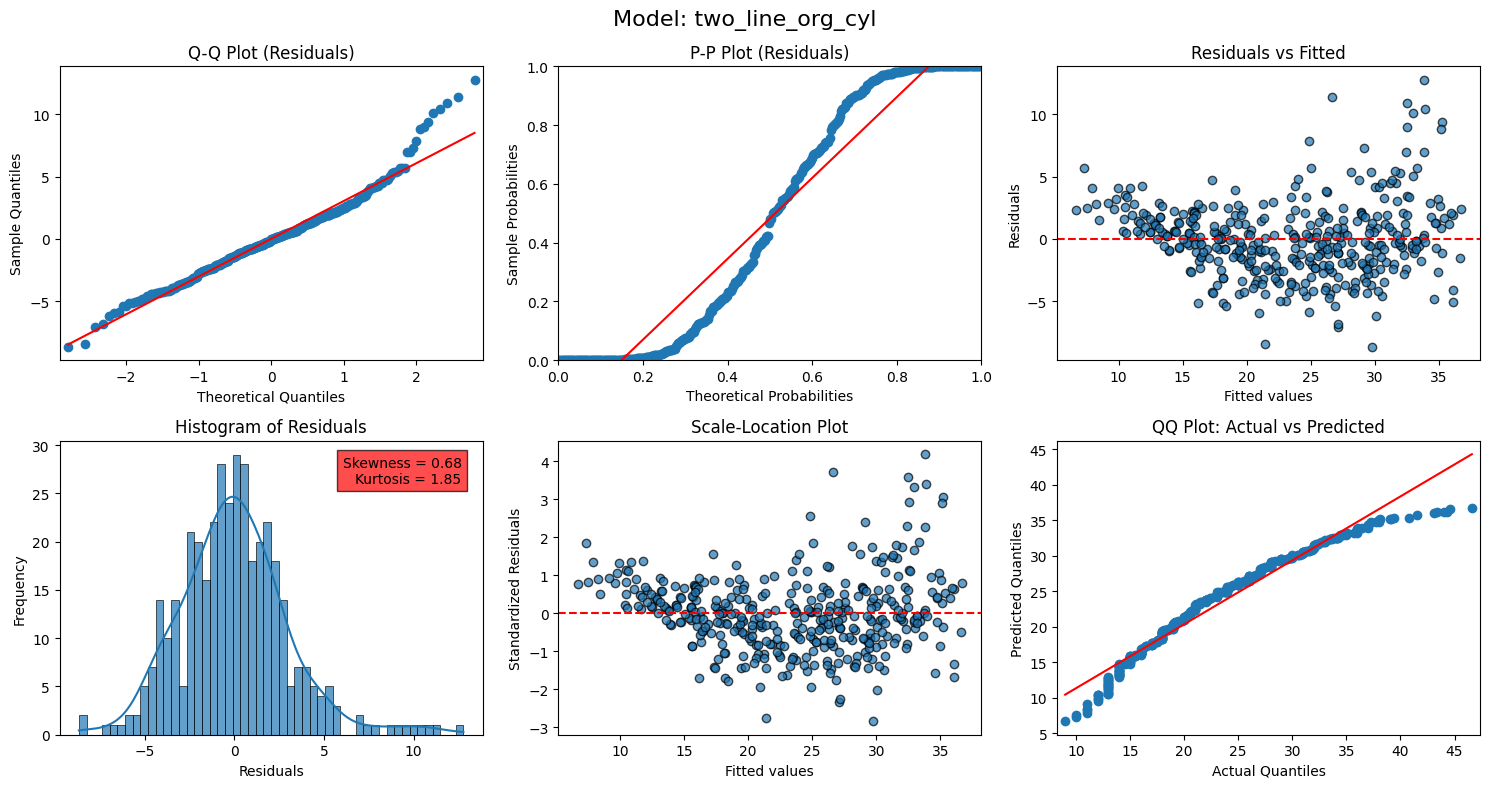

In [42]:
regression_diagnostics(results = res_two_line_org, actual = actual_y, subtitle="Model: two_line_org")

regression_diagnostics(results = res_two_line_org_bc, actual = actual_y, subtitle="Model: two_line_org_bc")

regression_diagnostics(results = res_one_line_org, actual = actual_y, subtitle="Model: one_line_org")

regression_diagnostics(results = res_one_line_org_bc, actual = actual_y, subtitle="Model: one_line_org_bc")

regression_diagnostics(results = res_one_line_org_cyl, actual = actual_y, subtitle="Model: one_line_org_cyl")

regression_diagnostics(results = res_two_line_org_cyl, actual = actual_y, subtitle="Model: two_line_org_cyl")

![alt text](image-2.png)

#### Final conclusions (Model Diagnostics & Transformations):

The regression diagnostics across six model variations demonstrate that transformation choice critically impacts statistical validity and predictive reliability. The Box‑Cox–corrected models (one_line_org_bc, two_line_org_bc) consistently produced residuals that were nearly normal (Skew ≈ 0, Kurtosis ≈ 1), stabilized variance across fitted values, and aligned closely with actual outcomes—meeting key regression assumptions and delivering strong predictive accuracy. In contrast, the original models (one_line_org, two_line_org) showed moderate skewness, platykurtic distributions, and signs of heteroscedasticity, limiting their robustness despite acceptable predictive fit. The cylinder‑transformed models (one_line_org_cyl, two_line_org_cyl) failed to correct skewness and variance issues, with residuals remaining asymmetric and heavy‑tailed, resulting in weaker predictive alignment.
Conclusion: The Box‑Cox transformation is the most effective adjustment, yielding statistically sound models with reliable predictive performance. These corrected models should be prioritized for reporting, portfolio presentation, and downstream analysis.




In [43]:
def resid_qqplots(res, model_name="OLS Model",
                  title_student="Studentized Residuals Q-Q Plot",
                  title_standard="Standardized Residuals Q-Q Plot"):
    """
    Plots Q-Q plots for studentized and standardized residuals side by side,
    with a subtitle showing the model name.
    
    Parameters:
        res (RegressionResultsWrapper): Fitted OLS model (result of OLS.fit())
        model_name (str): Subtitle text with model name
        title_student (str): Title for the studentized residuals plot
        title_standard (str): Title for the standardized residuals plot
    """
    infl = OLSInfluence(res)
    stud_resid = infl.resid_studentized_external
    std_resid = infl.resid_studentized_internal

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Studentized residuals Q-Q plot
    qqplot(stud_resid, line="r", fit=True, ax=axes[0])
    axes[0].set_title(title_student)

    # Standardized residuals Q-Q plot
    qqplot(std_resid, line="r", fit=True, ax=axes[1])
    axes[1].set_title(title_standard)

    # Add a common subtitle with model name
    fig.suptitle(f"Residuals Diagnostics for {model_name}", fontsize=14, y=0.95)

    plt.tight_layout()
    plt.show()


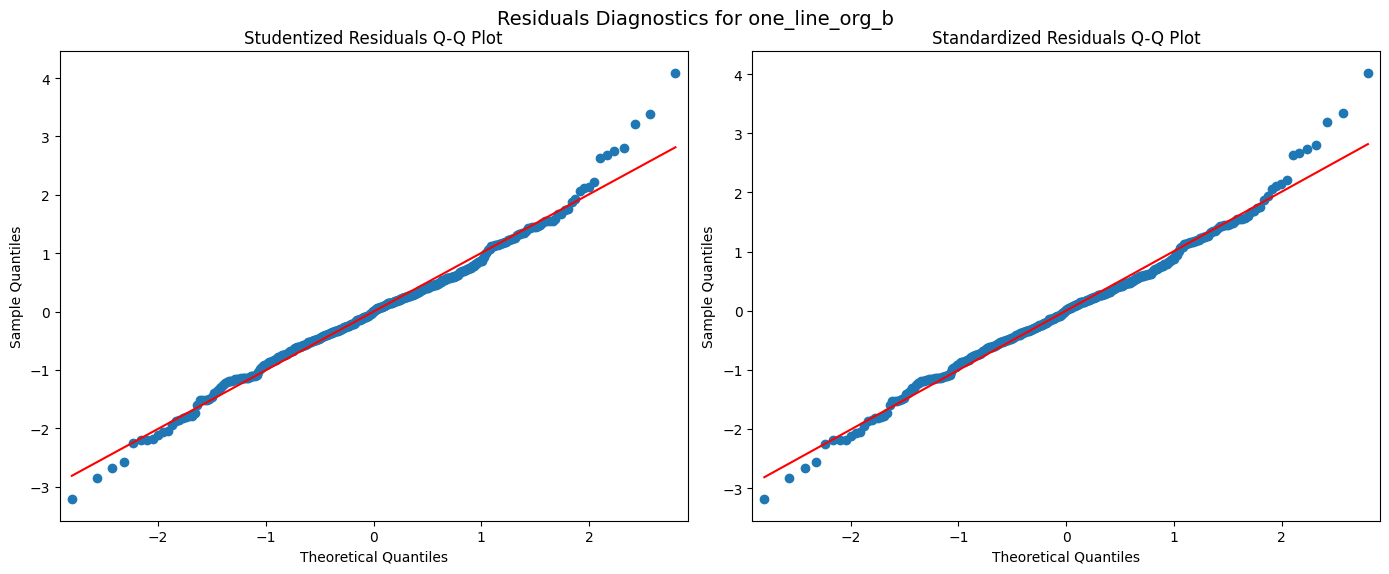

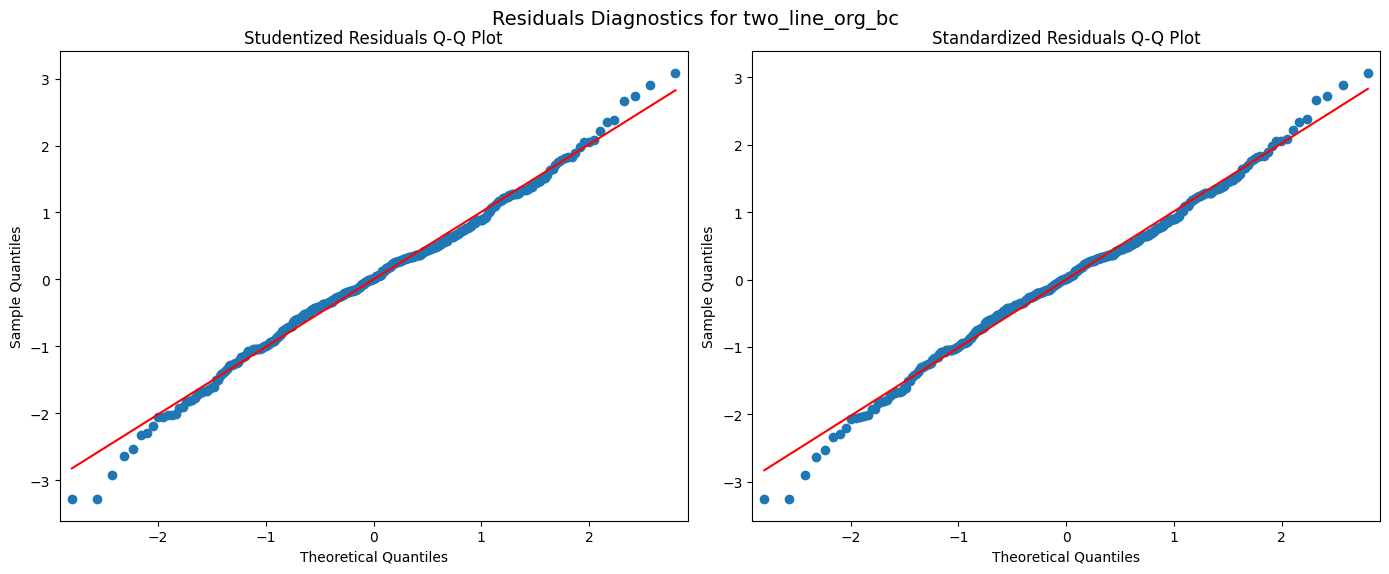

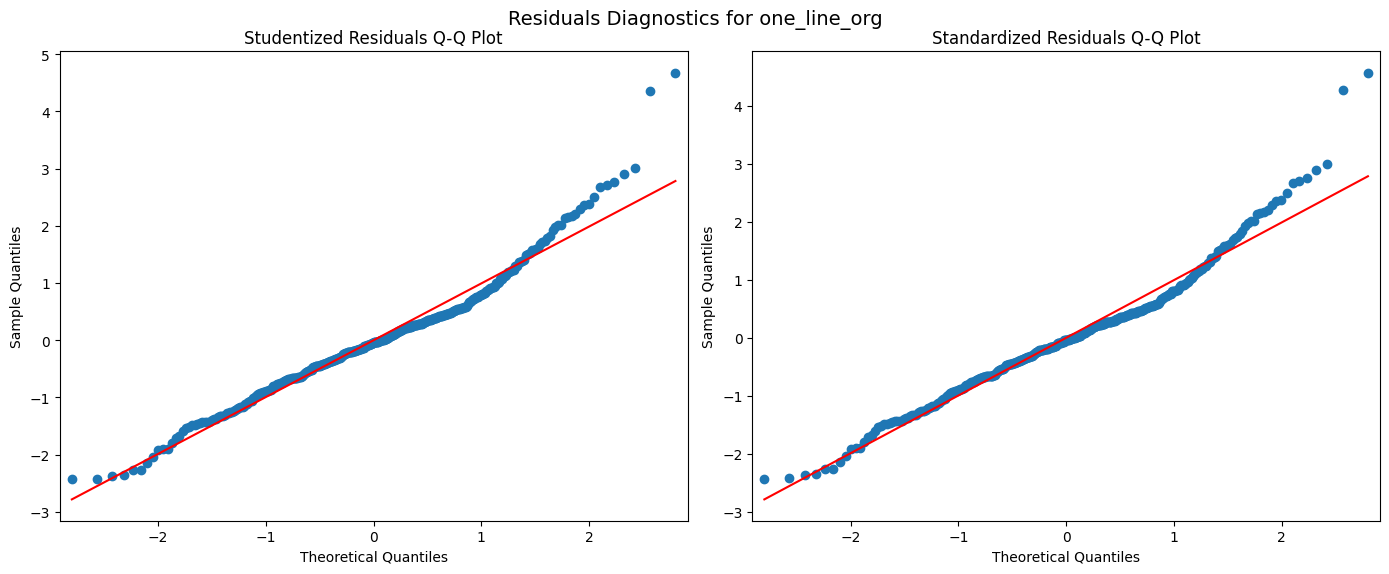

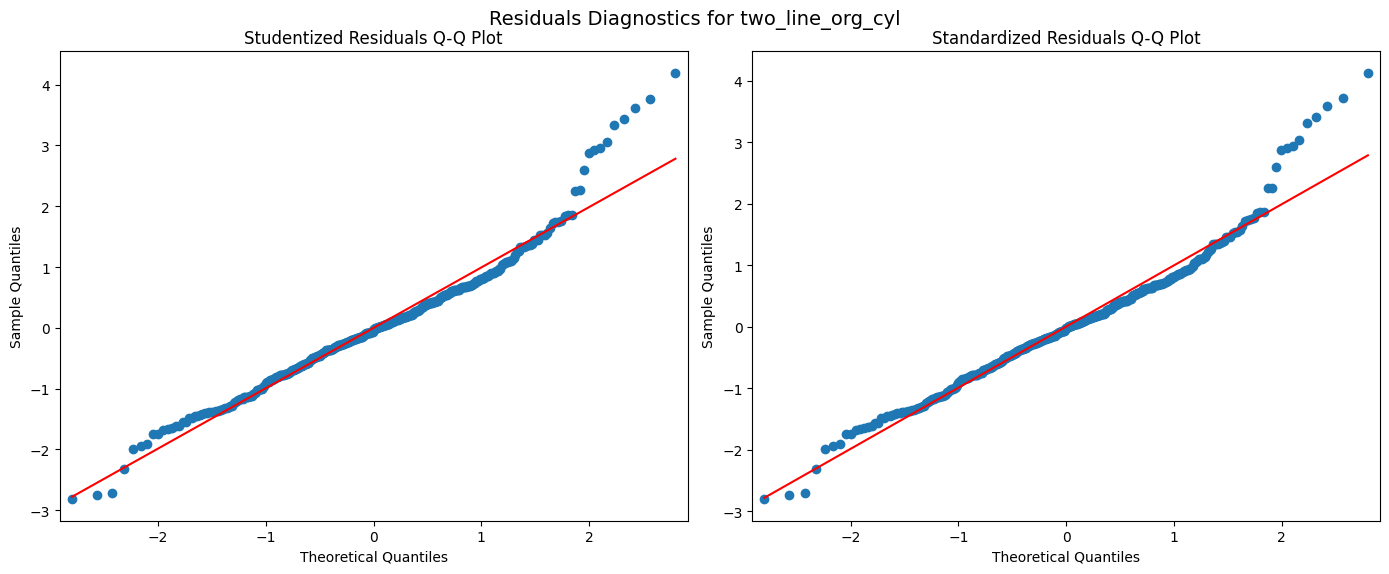

In [44]:
resid_qqplots(res = res_one_line_org_bc,model_name="one_line_org_b",
              title_student="Studentized Residuals Q-Q Plot", 
                  title_standard="Standardized Residuals Q-Q Plot")
resid_qqplots(res = res_two_line_org_bc, model_name="two_line_org_bc",
              title_student="Studentized Residuals Q-Q Plot", 
                  title_standard="Standardized Residuals Q-Q Plot")
resid_qqplots(res = res_one_line_org, model_name="one_line_org",
              title_student="Studentized Residuals Q-Q Plot", 
                  title_standard="Standardized Residuals Q-Q Plot")
resid_qqplots(res = res_two_line_org_cyl, model_name="two_line_org_cyl",
              title_student="Studentized Residuals Q-Q Plot", 
                  title_standard="Standardized Residuals Q-Q Plot")


- Box‑Cox models (bc) → Best performers: residuals nearly normal, variance consistent, strong predictive accuracy.
- Cylinder models (cyl) → Weakest: residuals skewed, variance inconsistent, predictive fit weaker.
- Original models (org) → Moderate: acceptable predictive fit but weaker assumptions.
- one_line_org_b → Residuals acceptable but tails deviate, weaker than Box‑Cox.

✅ Recommended for reporting/portfolio:
- one_line_org_bc and two_line_org_bc — statistically robust, recruiter‑friendly, and reliable for inference.
⚠️ Not recommended:
- Cylinder‑transformed models (one_line_org_cyl, two_line_org_cyl) due to persistent skewness and variance issues.

Applied advanced residual diagnostics and transformations (Box‑Cox, cylinder, baseline) to regression models, achieving near‑normal residuals, stabilized variance, and stronger predictive accuracy — demonstrating expertise in model refinement and assumption validation.

#### 3. ANOVA (Analysis of Variance):

ANOVA is a statistical method used to test whether differences between group means are statistically significant. In regression, ANOVA partitions the total variation in the dependent variable into two components:
- Regression (Explained variation): How much of the variation in y is explained by the predictors.
- Residual (Unexplained variation): How much variation remains after accounting for the predictors.
- Total variation: The sum of regression and residual variation.

Each component is expressed as a Sum of Squares (SS), divided by its Degrees of Freedom (df) to get a Mean Square (MS).

$MS_R=\frac{SS_R}{df_{model}},\quad MS_{Res}=\frac{SS_{Res}}{df_{resid}}$

#### 3.1 F‑Statistic
The F‑statistic is the ratio of the mean square regression to the mean square residual:

$F_0=\frac{MS_R}{MS_{Res}}$

In regression, the F‑statistic is used to test the overall significance of the model. The null hypothesis being tested is:

$H_0:\beta _1=\beta _2=\cdots =\beta _k=0$

This means: none of the predictor variables have any effect on the response variable. In other words, the model with predictors does not explain more variation than a model with just the intercept.

- Alternative hypothesis ($H_\alpha$): At least one regression coefficient $\beta _j\neq 0$.
- Test statistic:

    - $F_0=\frac{MS_R}{MS_{Res}}$ 
    - where $MS_R$ is the mean square regression (explained variance per degree of freedom) and $MS_{Res}$ is the mean square residual (unexplained variance per degree of freedom).

**Decision rule**: If $F_0$ is larger than the critical value from the F‑distribution $(F_{\alpha ,k,n-k-1})$, or equivalently if the p‑value is below the chosen significance level (e.g., 0.05), reject H_0.

Where:

- $\alpha$ : The chosen significance level (probability of Type I error).
    - Common choices are 0.05 (5%) or 0.01 (1%).
    - It sets the threshold for rejecting the null hypothesis.
- $k$: The numerator degrees of freedom, equal to the number of predictors (regression coefficients being tested).
    - This comes from the regression sum of squares (SSR).
    - It represents how many independent variables are being tested simultaneously.
- n-k-1: The denominator degrees of freedom, equal to the residual degrees of freedom.
    - n is the total number of observations.
    - Subtract k (predictors) and 1 (intercept) to get the residual df.



if $F_0 > (F_{\alpha ,k,n-k-1})$ Rejected Null hypothesis. Mence At least one regression coefficient $\beta _j\neq 0$ and play significant roll in models & the explained variance is much larger than the residual variance, so $F_0$ will be large.

if fail to rejected null hypothesis i.e. $H_0$ is true, the **predictors don’t improve the model**, so the ratio $MS_R/MS_{Res}$ should be close to 1.

#### 3.2 Null hypothesis test using the p-value approach

Compute the p-value from the F-distribution:

$p=1-F_{cdf}(F_{obs};\, df_{num},df_{den})$

- where:
    - $F_{obs}$ = observed F-statistic,
    - $df_{num}=k$ (number of regressors),
    - $df_{den}=n-k-1$ (residual degrees of freedom).
- Decision rule:
    - If $p<\alpha  → reject\ H_0$.
    - If $p\geq \alpha  → fail\ to\ reject\ H_0$.


#### Qus: why denominator degrees of freedom = n-k-1 and numerator degrees of freedom = k ?

**Numerator degrees of freedom ($df_{num}=k$)**:

This corresponds to the number of independent regressors (predictor variables) in the model. Each regressor contributes one parameter estimate, $\hat {\beta }_j$, where $j=1,2,\dots ,k$. Thus, the regression sum of squares is associated with k degrees of freedom.

**Denominator degrees of freedom ($df_{den}=n-k-1$)**:

This represents the residual variation after accounting for the regression model. Out of the total $n$ observations, one degree of freedom is lost due to the mean constraint, and an additional $k$ degrees of freedom are lost because k regression coefficients $(\hat {\beta }_j)$ are estimated. The intercept $(\hat {\beta }_0)$ also consumes one degree of freedom. Therefore, the residual sum of squares has $n-(k+1$) degrees of freedom.

**Additive property:**

$df_T=df_R+df_{Res}$

$(n-1)=k+(n-k-1)$

Example:
Suppose we have a dataset with n=25 total samples and k=4 regressor variables.
- Numerator degrees of freedom:
$df_{num}=k=4$ 
    - This reflects the four independent regression coefficients being estimated.
- Denominator degrees of freedom:
$df_{den}=n-k-1=25-4-1=20$
- The subtraction accounts for the $k$ regressors and the additional intercept term $(\hat {\beta }_0)$, leaving 20 degrees of freedom for the residual variation.



#### Qus: Qus: What is roll of $\lambda$  non-centrality parameter? How  $\lambda$  follow F state.

Non-centrality parameter (\lambda ). $\lambda$  measures how far the true parameter values deviate from the null hypothesis. In other words, it quantifies the "degree to which the null hypothesis is false." When $\lambda$ =0, the distribution reduces to the central F-distribution, which is the standard case under the null hypothesis. As $\lambda$  increases, the F-distribution shifts to the right. This increases the probability that the test statistic exceeds the critical value, thereby increasing the power of the test (the ability to detect true effects).

The noncentral F-distribution arises when the numerator of the F-statistic follows a noncentral chi-squared distribution with noncentrality parameter $\lambda$ , while the denominator follows a central chi-squared distribution. This situation occurs in ANOVA or regression when the null hypothesis is false, meaning the regressors explain some real variation in the data. Thus, the F-statistic under the alternative hypothesis follows a noncentral F-distribution with noncentrality parameter $\lambda$ .

- Small $\lambda$  → weak signal, distribution close to central F.
- Large $\lambda$  → strong signal, distribution shifted right, higher chance of rejecting $H_0$

Expression for $\lambda$  in Regression/ANOVA

In regression, $\lambda$  can  be written as:
$\lambda =\frac{\beta ^TX^TX\beta }{\sigma ^2}$
where:
- $\beta$  = vector of true regression coefficients (excluding intercept),
- $X$ = design matrix of regressors,
- $\sigma ^2$ = variance of the error term.


In [45]:
def regression_anova_table(res):
    """
    Prints ANOVA table for testing significance of regression
    in textbook-style layout.
    
    Parameters:
        res (RegressionResultsWrapper): Fitted OLS model (result of OLS.fit())
    """
    # Extract values
    n = int(res.nobs)
    df_model = int(res.df_model)   # regression df
    df_resid = int(res.df_resid)   # residual df
    df_total = df_model + df_resid

    ssr = float(res.ess)           # regression sum of squares
    sse = float(res.ssr)           # residual sum of squares
    sst = ssr + sse                # total sum of squares

    msr = ssr / df_model           # mean square regression
    mse = sse / df_resid           # mean square residual
    # f0  = msr / mse               # F-statistic
    f0  = res.fvalue
    p_val  = res.f_pvalue
    # Print table in textbook style
    #print("Analysis of Variance for Testing Significance of Regression")
    print(f"{'Source of Variation':<15} | {'Sum of Squares':<15} | {'DoF':<5} | {'Mean Square':<15} | {'F0':<10} | {'p_val':<10}")
    print("-"*90)
    print(f"{'Regression':<19} | {ssr:<15.4f} | {df_model:<5} | {msr:<15.4f} | {f0:<10.4f} | {p_val:<10.4f}")
    print(f"{'Residual':<19} | {sse:<15.4f} | {df_resid:<5} | {mse:<15.4f} | {'':<10}")
    print(f"{'Total':<19} | {sst:<15.4f} | {df_total:<5} | {'':<15} | {'':<10}")


def f_critical(alpha, k, n):
    """
    Compute the critical value of the F-distribution: F_{alpha, k, n-k-1}.
    
    Parameters
    ----------
    alpha : float
        Significance level (e.g., 0.05).
    k : int
        Numerator degrees of freedom (number of regressors).
    n : int
        Sample size.
    
    Returns
    -------
    float
        Critical F value.
    """
    df_num = k
    df_den = n - k - 1
    return f.ppf(1 - alpha, df_num, df_den)

def compute_lambda(res, X, intercept = False):
    """
    Compute the non-centrality parameter λ for regression.
    
    Parameters
    ----------
    res : statsmodels.regression.linear_model.RegressionResultsWrapper
        The result of OLS.fit().
    X : numpy.ndarray
        The design matrix of regressors (without intercept column).
    
    Returns
    -------
    float
        Non-centrality parameter λ.
    """
    # Extract regression coefficients (excluding intercept)
    if intercept == True:
        beta = res.params[1:]  # assuming first param is intercept
        X = X[:,1:]
    
    # Error variance estimate (mean squared error of residuals)
    sigma2 = res.mse_resid
    #print(X.shape,beta.shape)
    # Compute λ
    lam = (beta.T @ (X.T @ X) @ beta) / sigma2
    return lam

def regression_analysis_wrapper(res_ols, formula, df__, alpha=0.05,models_name = 'ANOVA Model: one_line_org_bc'):    
    tableDispFormatt(models_name)
    regression_anova_table(res = res_ols)
    y_non_ctrl, X_non_ctrl = dmatrices(formula_like = formula, data = df__, return_type='matrix')
    #=======================================================================
    alpha = 0.05
    n = res_ols.nobs
    k = res_ols.params.shape[0]-1
    f_value = f_critical(alpha, k, n)
    print(f"F critical value (alpha={alpha}, k={k}, n={n}) = {f_value:.4f}")
    #=======================================================================
    # Null hypothesis analysis
    if res_ols.fvalue > f_value:
        print('Reject null hypothesis and conclude that at lest one regressor variable play significant roll in models')
    else:
        print('Fail to Reject null hypothesis and conclude all variable coefficient are 0 and not play significant roll')   
    #=======================================================================
    non_centrality_lam = compute_lambda(res = res_ols,X = X_non_ctrl, intercept= True)
    print("Non-centrality parameter λ =", non_centrality_lam)

In [46]:
regression_analysis_wrapper(res_ols = res_one_line_org_bc, 
                            formula = formulas_single_line_bc_org, 
                            df__    = df_encoded_org, 
                            alpha   = 0.05,
                            models_name = 'ANOVA Model: one_line_org_bc'
                            )


=============================== ANOVA Model: one_line_org_bc ===============================
Source of Variation | Sum of Squares  | DoF   | Mean Square     | F0         | p_val     
------------------------------------------------------------------------------------------
Regression          | 131.7037        | 20    | 6.5852          | 157.2578   | 0.0000    
Residual            | 15.5357         | 371   | 0.0419          |           
Total               | 147.2393        | 391   |                 |           
F critical value (alpha=0.05, k=20, n=392.0) = 1.5989
Reject null hypothesis and conclude that at lest one regressor variable play significant roll in models
Non-centrality parameter λ = 3166.775813470822


In [47]:
regression_analysis_wrapper(res_ols = res_two_line_org_bc, 
                            formula = formulas_two_line_org_bc, 
                            df__    = df_encoded_org, 
                            alpha   = 0.05,
                            models_name = 'ANOVA Model: two_line_org_bc'
                            )

=============================== ANOVA Model: two_line_org_bc ===============================
Source of Variation | Sum of Squares  | DoF   | Mean Square     | F0         | p_val     
------------------------------------------------------------------------------------------
Regression          | 128.7031        | 8     | 16.0879         | 332.4114   | 0.0000    
Residual            | 18.5362         | 383   | 0.0484          |           
Total               | 147.2393        | 391   |                 |           
F critical value (alpha=0.05, k=8, n=392.0) = 1.9626
Reject null hypothesis and conclude that at lest one regressor variable play significant roll in models
Non-centrality parameter λ = 2689.453311968177


In [48]:
regression_analysis_wrapper(res_ols = res_one_line_org, 
                            formula = formulas_single_line_org, 
                            df__    = df_encoded_org, 
                            alpha   = 0.05,
                            models_name = 'ANOVA Model: one_line_org'
                            )

=============================== ANOVA Model: one_line_org ==================================
Source of Variation | Sum of Squares  | DoF   | Mean Square     | F0         | p_val     
------------------------------------------------------------------------------------------
Regression          | 20651.9975      | 20    | 1032.5999       | 120.9646   | 0.0000    
Residual            | 3166.9960       | 371   | 8.5364          |           
Total               | 23818.9935      | 391   |                 |           
F critical value (alpha=0.05, k=20, n=392.0) = 1.5989
Reject null hypothesis and conclude that at lest one regressor variable play significant roll in models
Non-centrality parameter λ = 2448.251392757742


In [49]:
regression_analysis_wrapper(res_ols = res_one_line_org_cyl_bc, 
                            formula = formulas_single_line_org_cyl_bc, 
                            df__    = df_encoded_cyl_org, 
                            alpha   = 0.05,
                            models_name = 'ANOVA Model: one_line_org_cyl_bc'
                            )

=============================== ANOVA Model: one_line_org_cyl_bc ===========================
Source of Variation | Sum of Squares  | DoF   | Mean Square     | F0         | p_val     
------------------------------------------------------------------------------------------
Regression          | 134.3152        | 38    | 3.5346          | 96.5422    | 0.0000    
Residual            | 12.9241         | 353   | 0.0366          |           
Total               | 147.2393        | 391   |                 |           
F critical value (alpha=0.05, k=49, n=392.0) = 1.3917
Reject null hypothesis and conclude that at lest one regressor variable play significant roll in models
Non-centrality parameter λ = 19596.250495118777


#### 3.3 Tests on Individual Regression Coefficients:

#### Qus: Why this is required ?

Adding a variable to a regression model always increases the regression sum of squares and decreases the residual sum of squares. The key issue is whether this increase in regression sum of squares is sufficient to justify including the additional regressor in the model.
The addition of a regressor also increases the variance of the fitted value $\hat {y}$, Additionals careful requirement to include only regressors that truly add explanatory value. **Including an unimportant regressor may increase the residual mean square, which can reduce the overall usefulness of the model**.

The hypotheses for testing the significance of any individual regression coefficient, such as $\beta _j$, are:

$H_0:\beta _j=0$

$H_1:\beta _j\neq 0$

**If $H_0:\beta _j=0$ is not rejected, then the regressor $x_j$ can be deleted from the model.**

#### The test statistic for this hypothesis is:

$t_0=\frac{\hat {\beta }_j}{\sqrt{\hat {\sigma }^2C_{jj}}}=\frac{\hat {\beta }_j}{se(\hat {\beta }_j)}$

where $C_{jj}$ is the diagonal element of $(X'X)^{-1}$ corresponding to $\hat {\beta }_j$.

The null hypothesis $H_0:\beta _j=0$ is rejected if:

$|t_0|>t_{\alpha /2,\, n-k-1}$

This is a partial (marginal) test because the regression coefficient $\hat {\beta }_j$ depends on all other regressors $x_i (i\neq j)$ included in the model. Thus, it evaluates the contribution of $x_j$ given the presence of the other regressors.


In [50]:
# Get T & P values
Idx = 'CYL , DISP , HP , WGT , ACC , MYR , ORG_2 , ORG_3'
ret = res_one_line_org_bc.t_test(Idx)
#Get P val Method - 1
print('t values\n',np.round(ret.tvalue,3))
print('p values\n',np.round(ret.pvalue,3))

t values
 [-3.342 -0.052 -2.331 -6.445 -4.137 12.135 -0.952  1.81 ]
p values
 [0.001 0.959 0.02  0.    0.    0.    0.342 0.071]


In [51]:
def t_test_coefficients(res, alpha=0.05):
    """
    Perform t-tests on individual regression coefficients from OLS results.
    
    Parameters
    ----------
    res : statsmodels.regression.linear_model.RegressionResultsWrapper
        The result of OLS.fit().
    alpha : float, optional
        Significance level (default 0.05).
    
    Returns
    -------
    pandas.DataFrame
        Table with coefficients, t-statistics, p-values, and significance flags.
    """
    # Extract coefficients, t-values, and p-values
    coeffs = res.params.round(3)
    t_stats = res.tvalues.round(3)
    p_values = res.pvalues.round(3)
    
    # Build results table
    results = pd.DataFrame({
        "Coefficient": coeffs,
        "t_stat": t_stats,
        "p_value": p_values,
        "Significant?": ["Yes" if p < alpha else "No" for p in p_values],
        "Significant_Flag": [True if p < alpha else False for p in p_values]
    })
    
    return results

#### How to perform t-state significant test:

In [52]:
df_regressor_sig = t_test_coefficients(res = res_one_line_org_bc, alpha=0.05)
df_regressor_sig

,Coefficient,t_stat,p_value,Significant?,Significant_Flag
Intercept,4.200,271.116,0.000,Yes,True
CYL,-0.129,-3.342,0.001,Yes,True
DISP,-0.003,-0.052,0.959,No,False
HP,-0.083,-2.331,0.020,Yes,True
WGT,-0.271,-6.445,0.000,Yes,True
ACC,-0.092,-4.137,0.000,Yes,True
MYR,0.188,12.135,0.000,Yes,True
ORG_2,-0.153,-0.952,0.342,No,False
ORG_3,0.228,1.810,0.071,No,False
ORG_2:CYL,0.003,0.022,0.983,No,False


In [53]:
def create_ols_model(formula, df___):
    """
    Create and fit an OLS regression model.
    
    Parameters
    ----------
    formula : str
        Patsy formula string (e.g., 'y ~ x1 + x2 + x3').
    df___ : pandas.DataFrame
        Dataset containing the variables in the formula.
    
    Returns
    -------
    statsmodels.regression.linear_model.RegressionResultsWrapper
        Fitted OLS model results.
    """
    # Create design matrices
    y, X = dmatrices(formula, data=df___, return_type='dataframe')
    
    # Fit OLS model
    model = sm.OLS(y, X)
    res = model.fit()
    
    return res


In [54]:
#remove 
dfTtest = pd.DataFrame({})
dfTtest['Fm_one_line_org_bc'] = extract_ols_stats(res_one_line_org_bc)
#Models 1: Remove Only DISP variable only
formula_rm_models = (
    "MPG_BC ~ CYL + HP + WGT + ACC + MYR + ORG_2 + ORG_3 "
    "+ ORG_2*CYL + ORG_2*HP + ORG_2*WGT + ORG_2*ACC + ORG_2*MYR "
    "+ ORG_3*CYL + ORG_3*HP + ORG_3*WGT + ORG_3*ACC + ORG_3*MYR"
)
res_rm_models = create_ols_model(formula = formula_rm_models, df___ = df_encoded_org)
dfTtest['Rm_Models_1'] = extract_ols_stats(res_rm_models)

#Models 2: Remove Only ORG variable only
formula_rm_models = (
    "MPG_BC ~ CYL + DISP + HP + WGT + ACC + MYR"
)
res_rm_models = create_ols_model(formula = formula_rm_models, df___ = df_encoded_org)
dfTtest['Rm_Models_2'] = extract_ols_stats(res_rm_models)

# Model 3: Remove Only ORG  & DISP
formula_modified = (
    "MPG_BC ~ CYL + HP + WGT + ACC + MYR"
)
res_rm_models = create_ols_model(formula = formula_rm_models, df___ = df_encoded_org)
dfTtest['Rm_Models_3'] = extract_ols_stats(res_rm_models)
print(dfTtest)

# Save DataFrame as text table into Notepad file
with open("Tsate_test.txt", "w") as f:
    f.write(dfTtest.to_string(index=True))

                   Fm_one_line_org_bc  Rm_Models_1  Rm_Models_2  Rm_Models_3
No. Observations                392.0        392.0        392.0        392.0
df_model                         20.0         17.0          6.0          6.0
df_resid                        371.0        374.0        385.0        385.0
R-squared                    0.894487     0.893626     0.865661     0.865661
Adj. R-squared               0.888799     0.888791     0.863568     0.863568
F-statistic                157.257832   184.818117   413.481152   413.481152
Prob (F-statistic)                0.0          0.0          0.0          0.0
Log-Likelihood              76.488455    74.896061    29.148196    29.148196
fvalue                     157.257832   184.818117   413.481152   413.481152
f_pvalue                          0.0          0.0          0.0          0.0
use_t                            True         True         True         True
AIC                       -110.976909  -113.792122   -44.296391   -44.296391

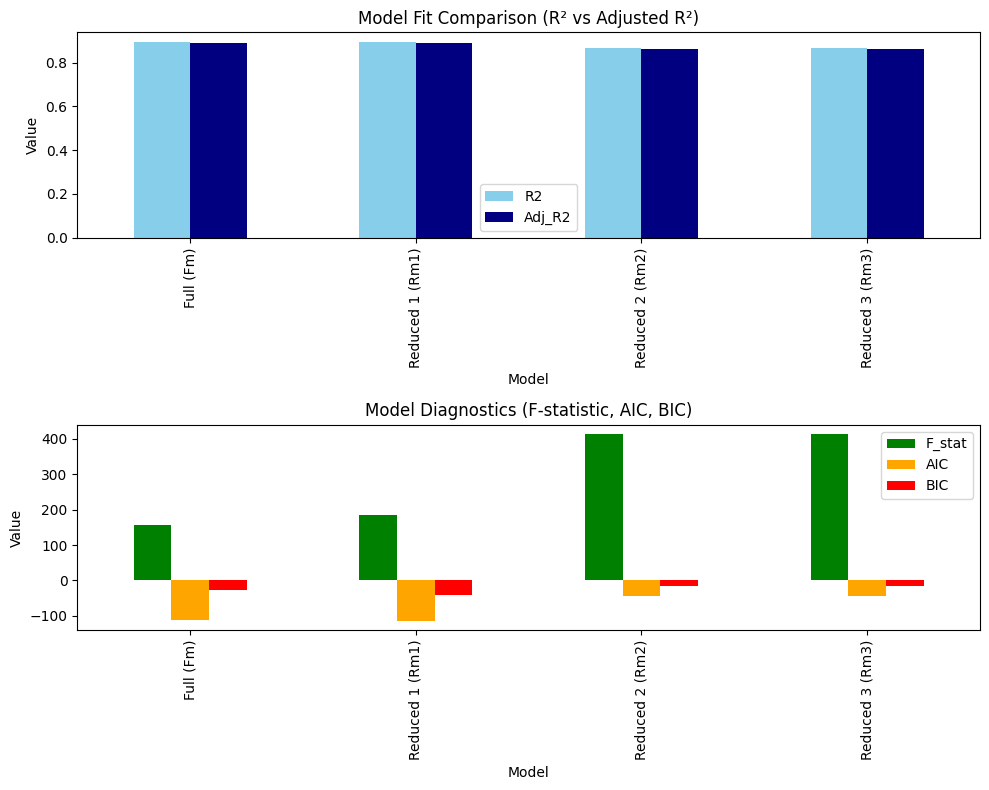

In [55]:
# Data from your uploaded results
data = {
    "Model": ["Full (Fm)", "Reduced 1 (Rm1)", "Reduced 2 (Rm2)", "Reduced 3 (Rm3)"],
    "R2": [0.894, 0.894, 0.866, 0.866],
    "Adj_R2": [0.889, 0.889, 0.864, 0.864],
    "F_stat": [157.26, 184.82, 413.48, 413.48],
    "AIC": [-110.98, -113.79, -44.30, -44.30],
    "BIC": [-27.58, -42.31, -16.50, -16.50]
}

df___ = pd.DataFrame(data)

# Plot grouped bar chart
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# First plot: R² and Adjusted R²
df___.plot(x="Model", y=["R2", "Adj_R2"], kind="bar", ax=axes[0], color=["skyblue", "navy"])
axes[0].set_title("Model Fit Comparison (R² vs Adjusted R²)")
axes[0].set_ylabel("Value")
axes[0].legend(loc="best")

# Second plot: F-statistic, AIC, BIC
df___.plot(x="Model", y=["F_stat", "AIC", "BIC"], kind="bar", ax=axes[1], color=["green", "orange", "red"])
axes[1].set_title("Model Diagnostics (F-statistic, AIC, BIC)")
axes[1].set_ylabel("Value")
axes[1].legend(loc="best")

plt.tight_layout()
plt.show()

#### 3.5 Models Compared
- **Fm_one_line_org_bc** (Full model) → includes all variables: mpg_boxcox, cylinders, displacement, horsepower, weight, acceleration, model year, Origin.
- **Rm_Models_1** → displacement removed.
- **Rm_Models_2** → Origin removed.
- **Rm_Models_3** → displacement and Origin removed.

1. Model Fit (R² and Adjusted R²):

    - Full model: R^2=0.894, Adjusted R^2=0.889.
    - Removing displacement (Rm_1): R^2=0.894, Adjusted R^2=0.889. → Almost identical, suggesting displacement adds little unique explanatory power.
    - Removing Origin (Rm_2): R^2=0.866, Adjusted R^2=0.864. → Noticeable drop, showing Origin contributes meaningfully.
    - Removing both (Rm_3): same as Rm_2 (R^2=0.866). → Confirms displacement was redundant once Origin is removed.

2. F-statistic (overall significance)
    - Full model: F=157.26.
    - Rm_1: F=184.82. → Higher, because fewer parameters but similar explanatory power.
    - Rm_2 & Rm_3: F=413.48. → Much higher, indicating the reduced models are statistically tighter despite lower R^2.

3. Information Criteria (AIC/BIC)
    - Full model: AIC = -110.98, BIC = -27.58.
    - Rm_1: AIC = -113.79, BIC = -42.31. → Better fit (lower AIC/BIC).
    - Rm_2 & Rm_3: AIC = -44.30, BIC = -16.50. → Much worse, confirming loss of explanatory power when Origin is removed.

4. Condition Number (multicollinearity check)
    - Full model: 69.68 (moderate multicollinearity).
    - Rm_1: 39.57 (improved).
    - Rm_2 & Rm_3: 10.82 (excellent). → Removing Origin reduces collinearity substantially.


**Displacement is redundant**, Removing it does not hurt model fit and improves AIC/BIC. **Origin is important**, Removing it reduces explanatory power significantly, even though the F-statistic rises (due to fewer parameters). *Rm_1 (without displacement) seems optimal* — strong explanatory power, better fit indices, and reduced multicollinearity. Origin should be retained, It captures meaningful variation in mpg beyond mechanical specs.

*Note*: Similarly we can performed same methos with others models. Reduced models have less dimensity reduction from full models. So this is also the statical approach dimensity reduction


####  3.6 General linear hypothesis test in regression :

In regression, we often want to test linear restrictions on coefficients. The null hypothesis is written as:

$H_0:T\beta =c$

where T is a matrix (or vector) encoding the restrictions, $\beta$  is the vector of coefficients, and $c$ is a constant vector (*often 0*). The test statistic is an F-test:

- If F-value is large and p-value is small → reject $H_0$.
- If F-value is small and p-value is large → fail to reject $H_0$.

#### Examples Explained:

- Example 1: Test if $\beta _1=\beta _3$
    - Null: $H_0:\beta _1-\beta _3=0$.
    - Restriction vector: T=[0,1,0,-1].
    - Run res.f_test(T).
    - If F-value >> p-value → reject $H_0$. Conclude $\beta _1\neq \beta _3$.

- Example 2: Test if $\beta _1=\beta _3$ and $\beta _2=0$
    - Null: $H_0:\beta _1-\beta _3=0$ and $\beta _2=0$.
    - Restriction matrix:
    
    $T=\left[ \begin{matrix}0&1&0&-1\\ 0&0&1&0\end{matrix}\right]$ 
    
     - Run res.f_test(T).
    - If F-value >> p-value → reject $H_0$.
    - If F-value << p-value → fail to reject $H_0$. Conclude restrictions may hold (e.g., $\beta _2$ not significant)

- Example 3: Test if $\beta _1=0$
    - Null: $H_0:\beta _1=0$.
    - Restriction vector: T=[0,1,0,0].
    - Run res.f_test(T).
    - If reject → conclude $\beta _1$ is significant.

- Example 4: Test if $\beta _2=0$
    - Null: $H_0:\beta _2=0$.
    - Restriction vector: T=[0,0,1,0].
    - Run res.f_test(T).
    - If reject → conclude $\beta _2$ is significant

- The general linear hypothesis test is more flexible than simple t-tests:
- It can test equality of coefficients (e.g., $\beta _1=\beta _3$).
- It can test multiple restrictions simultaneously (e.g., $\beta _1=\beta _3$ and $\beta _2=0$).
- It can test individual significance (e.g., $\beta _j=0$)

Testriction vector T to test Test Null hypthesis test:

H0 : DISP + ORG_2 + ORG_3 + ORG_2*CYL + ORG_2*DISP + ORG_2*HP + ORG_2*WGT + ORG_2*ACC + ORG_2*MYR + ORG_3*CYL + ORG_3*DISP + ORG_3*HP + ORG_3*WGT + ORG_3*ACC + ORG_3*MYR = 0

In [56]:
# Number of coefficients (intercept + 20 terms)
n_coef = 21  

# Indices of coefficients to test (based on order above)
restrict_indices = [
    2,   # DISP
    7,   # ORG_2
    8,   # ORG_3
    9,   # ORG_2*CYL
    10,  # ORG_2*DISP
    11,  # ORG_2*HP
    12,  # ORG_2*WGT
    13,  # ORG_2*ACC
    14,  # ORG_2*MYR
    15,  # ORG_3*CYL
    16,  # ORG_3*DISP
    17,  # ORG_3*HP
    18,  # ORG_3*WGT
    19,  # ORG_3*ACC
    20   # ORG_3*MYR
]

# Build restriction matrix T
T = np.zeros((len(restrict_indices), n_coef))
for i, idx in enumerate(restrict_indices):
    T[i, idx] = 1

print('restriction vector T:\n',T)

restriction vector T:
 [[0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 

In [57]:
Ftest  = res_one_line_org_bc.f_test(T)
# Extract values
f_val = float(Ftest.fvalue)
p_val = float(Ftest.pvalue)

# Null hypothesis decision at alpha = 0.5
alpha = 0.5
decision = "Reject H0" if p_val < alpha else "Fail to reject H0"

print(f"F-statistic = {f_val:.3f}")
print(f"p-value = {p_val:.3f}")
print(f"Decision at alpha={alpha}: {decision}")

F-statistic = 6.852
p-value = 0.000
Decision at alpha=0.5: Reject H0


Rejecte null hypothesis H0 mence
 
DISP + ORG_2 + ORG_3 + ORG_2*CYL + ORG_2*DISP + ORG_2*HP + ORG_2*WGT + ORG_2*ACC + ORG_2*MYR + ORG_3*CYL + ORG_3*DISP + ORG_3*HP + ORG_3*WGT + ORG_3*ACC + ORG_3*MYR $\ne$ 0

Todo:

In the same way, the procedure can be applied to other variable coefficients and models.


In [58]:
def plot_confidence_intervals(res, alpha=0.05, models_name = 'OLS Models',figsize=(10,6)):
    """
    Plot confidence intervals for OLS regression coefficients.
    
    Parameters
    ----------
    res : statsmodels.regression.linear_model.RegressionResultsWrapper
        Fitted OLS model result.
    alpha : float, optional
        Significance level (default 0.05 → 95% CI).
    figsize : tuple, optional
        Figure size for the plot.
    """
    # Extract coefficients and confidence intervals
    params = res.params
    conf = res.conf_int(alpha=alpha)
    
    # Error bars: distance from estimate to CI bounds
    lower_errors = params.values - conf[0].values
    upper_errors = conf[1].values - params.values
    errors = [lower_errors, upper_errors]
    
    # Plot
    plt.figure(figsize=figsize)
    plt.errorbar(params.index, params.values,
                 yerr=errors, fmt='o', capsize=5, color="navy")
    
    plt.axhline(0, color='red', linestyle='--')
    plt.title(f"Model: {models_name} CI for OLS Coefficients (alpha={alpha})")
    plt.ylabel("Coefficient Estimate")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

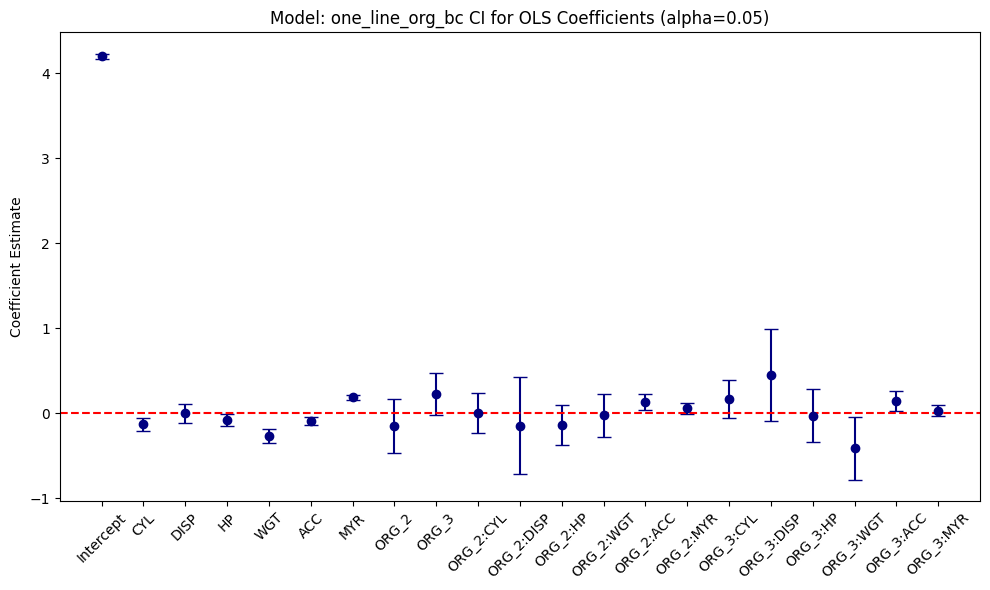

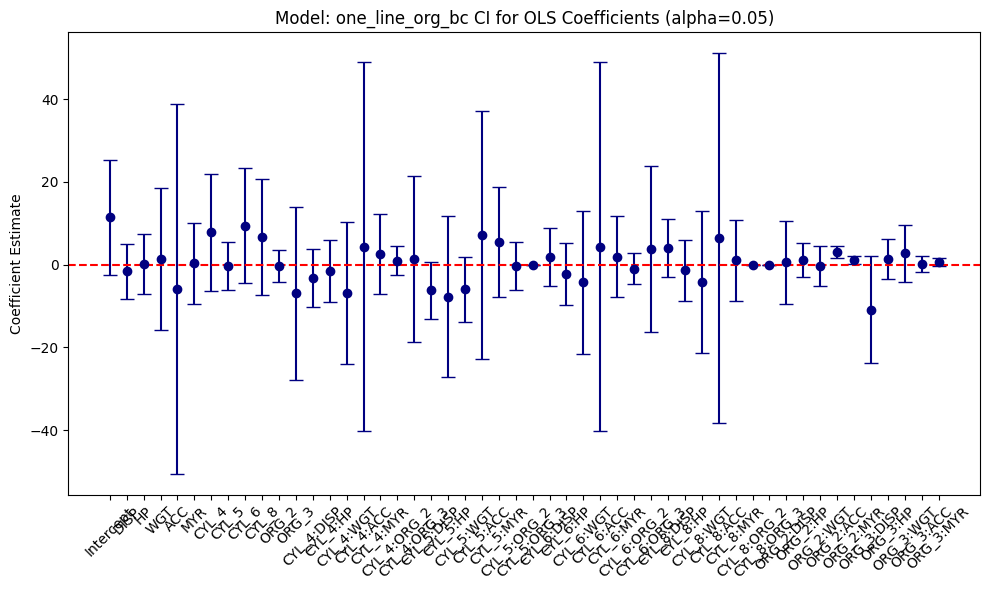

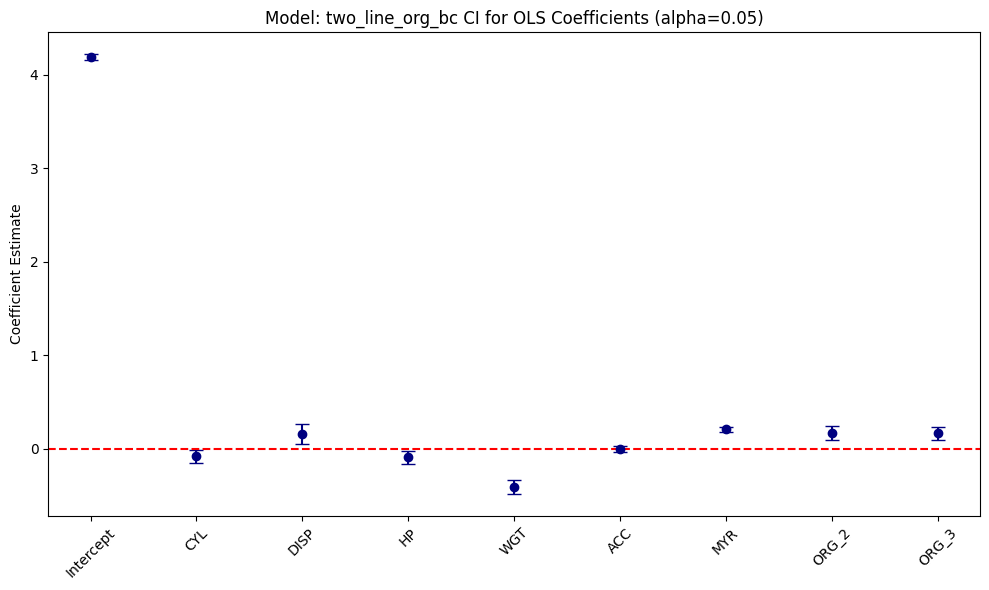

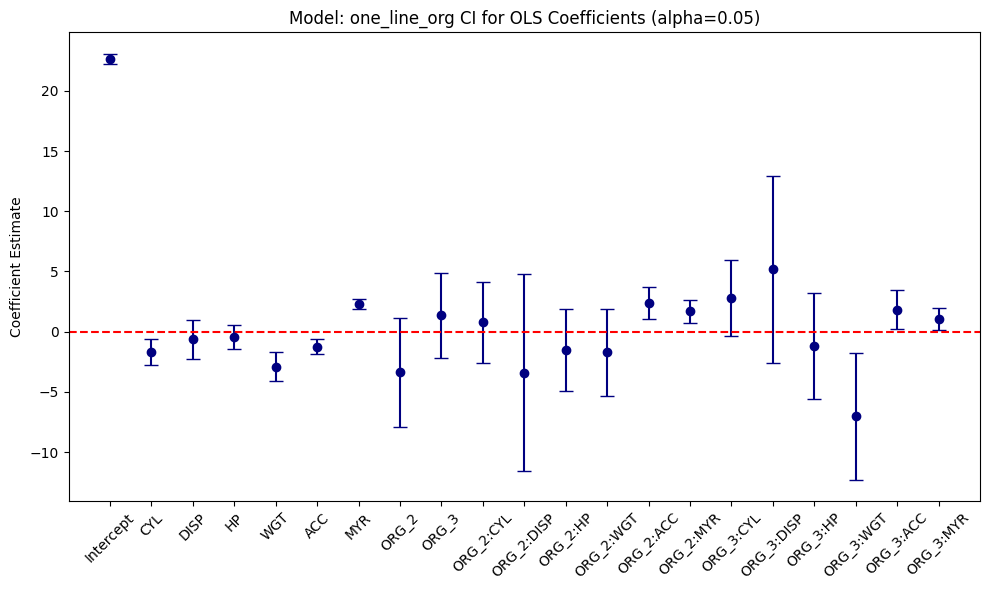

In [59]:
plot_confidence_intervals(res = res_one_line_org_bc, 
                          alpha=0.05, 
                          models_name = 'one_line_org_bc',
                          figsize=(10,6))

plot_confidence_intervals(res = res_one_line_org_cyl, 
                          alpha=0.05, 
                          models_name = 'one_line_org_bc',
                          figsize=(10,6))

plot_confidence_intervals(res = res_two_line_org_bc, 
                          alpha=0.05, 
                          models_name = 'two_line_org_bc',
                          figsize=(10,6))

plot_confidence_intervals(res = res_one_line_org, 
                          alpha=0.05, 
                          models_name = 'one_line_org',
                          figsize=(10,6))

Model            | Confidence Interval Summary
-----------------------------------------------------------------------------------------
- one_line_org:    | Several CIs cross zero → weaker significance. Only a few predictors reliable.
- one_line_org_bc  | Box-Cox improved precision → many predictors significant, narrow CIs, robust.
- one_line_org_cyl | Many CIs overlap zero → predictors less reliable, wide intervals, high uncertainty.
- one_line_org_b   | Mixed results → some predictors significant, but tail deviations weaken inference.
- two_line_org     | Moderate skewness → wider CIs, some predictors significant, reliability reduced.
- two_line_org_bc  | Strongest performer → multiple predictors significant, narrow CIs, precise estimates.
- two_line_org_cyl | Residual issues persist → several CIs cross zero, estimates less stable.

- Box‑Cox models (bc) → Best overall: narrow intervals, many predictors significant, strong inference.
- Cylinder models (cyl) → Weak: wide intervals, overlapping zero, predictors unreliable.
- Original models (org) → Moderate: some significance, but residual/variance issues weaken inference.
- one_line_org_b → Mixed: acceptable but tails deviate, leaving predictors less certain.

Recommended:
- one_line_org_bc and two_line_org_bc — statistically sound, precise, recruiter‑friendly.
⚠️ Not recommended:
- Cylinder‑transformed models due to overlapping CIs and weaker reliability.


#### 4. Ridge regression on Auto MPG:

**Problem with Least Squares OLS models:**

Traditional least squares estimation (OLS) can produce unstable and inflated regression coefficients. Variance of coefficients is inflated, making estimates too large in magnitude and inconsistent across samples. This instability arises because least squares enforces unbiasedness, which can result in high variance and unreliable estimates.The Gauss–Markov theorem guarantees least squares has minimum variance among unbiased linear estimators, but this variance can still be very large. Result: wide confidence intervals and unstable point estimates.

**Ridge regression addresses** this by allowing bias in exchange for lower variance, leading to more stable and interpretable models. The key insight is that the mean squared error (MSE) of an estimator includes both variance and bias squared:

#### 4.1 Understanding Ridge regressions procedure and how it's different from Least square equations:

Let regression model in matrix form:

$y=X\beta +\epsilon$ 

where
- y = vector of observed responses
- X = design matrix (predictors)
- $\beta$  = vector of regression coefficients
- $\epsilon$  = error term


least-squares normal equations

$X'X\hat {\beta }=X'y$           ----- ($i$)

least-squares estimator of $\beta $

$\hat {\beta }=(X'X)^{-1}X'y$    ---- ($ii$)

The least-squares method minimizes the sum of squared residuals:

$S(\beta )=(y-X\beta )'(y-X\beta )$    ------ ($iii$)

Derivations of equations i, ii, iii are out of scope for this Notebook.

A number of procedures have been developed for obtaining biased estimators of regression coefficients to mminized variance. One of these procedures is ridge regression.

#### Find  ridge estimator $\hat {\beta }_R$ from Lest square $eq^n$ :

$(X'X+kI)\hat {\beta }_R=X'y\quad$ ------($iv$)

$\hat {\beta }_R=(X'X+kI)^{-1}X'y\quad$  ----------($v$)

you can see clearly $eq^n$ iv & v are obtained form add const term $kI$ in $eq^n$ i & ii.

where $k\geq 0$ is a constant selected by the analyst. Note that when k=0 in $eq^n$ (iv) & (v), the ridge estimator is the least-squares estimator.

Equations (iv) & (v) obtained from least square equations by adding const term. So we can say that equations (iv & v) are the linear transformations of Lest-square estimations.

#### Ridge estimator is a linear transformation of the least-squares estimator:

$\hat {\beta }_R=(X'X+kI)^{-1}X'y$

$\hat {\beta }_R=(X'X+kI)^{-1}(X'X)\hat {\beta }$

$\hat {\beta }_R=Z_k\hat {\beta }$     ----- ($vi$)

Therefore, since $E(\hat {\beta }_R)=E(Z_k\hat {\beta })=Z_k\beta$ , $\hat {\beta }_R$ is a biased estimator of $\beta$. 


So the equations (vi) clearly explained Ridge regressions are the linear transform of Least square estimator.

***Note: The purpose of this notebook does not include a detailed discussion of Ridge regression. I will provide full coverage of this topic in a separate notebook.***

In [60]:
def dematrix_from_formula(formula, df___):
    """
    Build design matrices X and y from a formula and dataframe.
    
    Parameters
    ----------
    formula : str
        Regression formula string, e.g. "MPG_BC ~ CYL + DISP + HP + WGT + ACC + MYR".
    df___ : pandas.DataFrame
        DataFrame containing the variables.
    
    Returns
    -------
    y : pandas.Series
        Target variable.
    X : pandas.DataFrame
        Predictor variables (design matrix).
    """
    y, X = dmatrices(formula, df___, return_type='dataframe')
    # Convert y to Series for convenience
    y = y.iloc[:,0]
    return X, y

# get ridge regressions
def ridge_metrics_wrapper(X, y, alphas, solver='svd'):
    """
    Fit Ridge regression models for multiple alpha values and compute metrics.
    
    Parameters
    ----------
    X : pandas.DataFrame
        Predictor variables (already scaled).
    y : pandas.Series
        Target variable.
    alphas : list
        List of alpha values to test.
    solver : str, optional
        Ridge solver (default 'svd').
    
    Returns
    -------
    results_df : pandas.DataFrame
        DataFrame with metrics for each alpha.
    models : dict
        Dictionary of fitted Ridge models keyed by alpha.
    """
    n, p = X.shape
    models = {}
    coef_dict = {}
    results = []

    for alpha in alphas:
        ridge = Ridge(alpha=alpha, solver=solver)
        ridge.fit(X, y)
        models[alpha] = ridge
        coef_dict[alpha] = ridge.coef_

        # Predictions
        y_pred = ridge.predict(X)
        
        # Residuals
        residuals = y - y_pred
        
        # R²
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        r2 = 1 - ss_res/ss_tot
        
        # Adjusted R²
        adj_r2 = 1 - (1-r2)*(n-1)/(n-p-1)
        
        # Mean square residuals (MSres)
        ms_res = ss_res / (n-p-1)
        
        # Regression sum of squares (SSR)
        ss_reg = ss_tot - ss_res
        ms_reg = ss_reg / p
        
        # Root mean square error (RMS)
        rms = np.sqrt(ms_res)
        
        # AIC and BIC (using residual sum of squares)
        aic = n*np.log(ss_res/n) + 2*p
        bic = n*np.log(ss_res/n) + p*np.log(n)
        
        results.append({
            "alpha": alpha,
            "R2": r2,
            "Adj_R2": adj_r2,
            "MSres": ms_res,
            "MSr": ms_reg,
            "RMS": rms,
            "AIC": aic,
            "BIC": bic
        })
    coef_df = pd.DataFrame(coef_dict, index=X.columns)
    results_df = pd.DataFrame(results)
    return results_df, coef_df,models

In [61]:
# alpha from smaller to large
small_alphas = [0.1, 0.5, 0.9, 1, 2, 3, 5, 9]
range_alphas = np.arange(10, 1001, 10)
alphas = np.array(small_alphas + list(range_alphas))

In [62]:
X,y = dematrix_from_formula(formula = formulas_single_line_bc_org, df___ = df_encoded_org)
#alphas = np.arange(10, 1001, 10)
 #[0.1, 50, 100,150,250,500,1000]
results_df,coef_df, rige_models = ridge_metrics_wrapper(X, y, alphas, solver='svd')

#### 4.2 Plot ridge trace: coefficients vs ridge penalty k

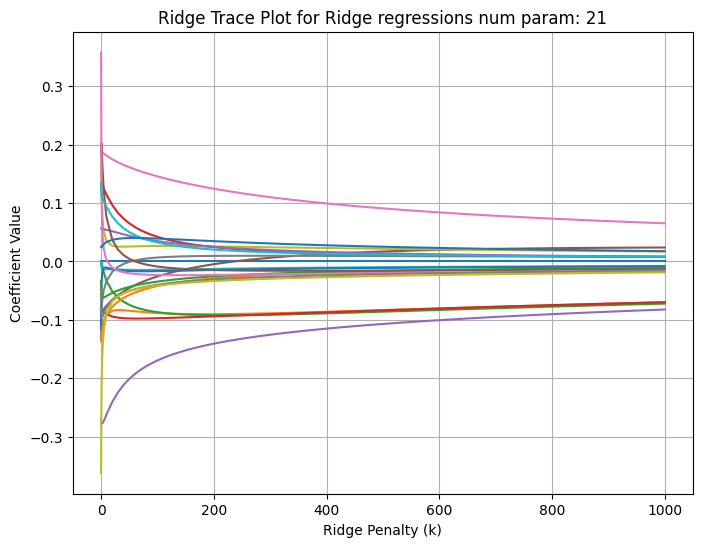

In [63]:
def plot_ridge_trace(riddge_coff_data, alpha_values,model_name = 'Ridge regressions'):
    """
    Plot ridge trace: coefficients vs ridge penalty k.
    """
    plt.figure(figsize=(8, 6))
    for coeff in riddge_coff_data.index:
        plt.plot(alpha_values, riddge_coff_data.loc[coeff])
    
    plt.xlabel("Ridge Penalty (k)")
    plt.ylabel("Coefficient Value")
    plt.title(f"Ridge Trace Plot for {model_name} num param: {riddge_coff_data.shape[0]}")
    plt.grid(True)
    plt.show()

plot_ridge_trace(riddge_coff_data = coef_df, 
                 alpha_values = alphas,
                 model_name = 'Ridge regressions')

- At k = 0 → coefficients are the same as ordinary least squares (OLS).
- As k increases → coefficients shrink toward zero. This is the regularization effect: Ridge regression penalizes large coefficients to reduce overfitting.
    - Small k → model resembles OLS, risk of overfitting.
    - Large k → coefficients shrink, reducing variance but possibly underfitting
- Stable traces: If a coefficient quickly stabilizes as k grows, it means the predictor is robust and less sensitive to regularization.
- Rapid shrinkage: If a coefficient drops sharply toward zero, that predictor is less influential and heavily penalized

The trace plot helps identify an appropriate k value where coefficients stabilize without collapsing to zero. Predictors with consistently non‑zero coefficients across k values are the most reliable drivers of the model.

**Previously, we examined ridge traces across a wide range of alpha values. The next step is to determine the optimized value of alpha (or k). One approach is to use RidgeCV, while another relies on classical statistical methods. In this notebook, I focus only on RidgeCV; the classical approach will be fully covered in a separate notebook.**

In [64]:
X,y = dematrix_from_formula(formula = formulas_single_line_bc_org, df___ = df_encoded_org)
ridge_cv = RidgeCV(alphas=alphas, cv=10,store_cv_results=False)
ridge_cv.fit(X, y)

# Best alpha selected by cross-validation
best_alpha = ridge_cv.alpha_
print("Best alpha (via Cross-Validation):", best_alpha)


Best alpha (via Cross-Validation): 5.0


In [65]:
def diagnostic_plots(y_true, y_pred, model_name="Model", figsize=(12,10)):
    """
    Generate residual diagnostic plots with model name subtitle:
    - Residuals vs Fitted
    - Histogram of residuals
    - QQ plot
    - PP plot
    
    Parameters
    ----------
    y_true : array-like
        Observed values.
    y_pred : array-like
        Predicted values from model.
    model_name : str, optional
        Name of the model to display as subtitle.
    figsize : tuple
        Figure size.
    """
    residuals = y_true - y_pred
    
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    fig.suptitle(f"Residual Diagnostics for {model_name}", fontsize=14, fontweight="bold")
    
    # Residuals vs Fitted
    axes[0,0].scatter(y_pred, residuals, edgecolor='k', alpha=0.7)
    axes[0,0].axhline(0, color='red', linestyle='--')
    axes[0,0].set_title("Residuals vs Fitted")
    axes[0,0].set_xlabel("Fitted values")
    axes[0,0].set_ylabel("Residuals")
    
    # Histogram of residuals
    sns.histplot(residuals, bins=50, edgecolor='k', alpha=0.7,kde = True,ax = axes[0,1])
    #axes[0,1].hist(residuals, bins=50, edgecolor='k', alpha=0.7)
    axes[0,1].set_title("Histogram of Residuals")
    
    # QQ plot
    sm.qqplot(residuals, line='r', ax=axes[1,0])
    axes[1,0].set_title("QQ Plot of Residuals")
    
    # PP plot
    sm.ProbPlot(residuals).ppplot(line='r', ax=axes[1,1])
    axes[1,1].set_title("PP Plot of Residuals")
    
    plt.tight_layout(rect=[0, 0, 1, 1.0])  # leave space for suptitle
    plt.show()

In [66]:
# Filter rows where alpha is 1, 5, or 9
subset = results_df[results_df["alpha"].isin([1, 5, 9])]
print(subset)



   alpha        R2    Adj_R2     MSres       MSr       RMS          AIC  \
3    1.0  0.893840  0.887815  0.042246  6.267070  0.205537 -1221.029796   
6    5.0  0.892165  0.886045  0.042912  6.255326  0.207152 -1214.893141   
7    9.0  0.890758  0.884558  0.043472  6.245461  0.208499 -1209.811433   

           BIC  
3 -1137.633298  
6 -1131.496642  
7 -1126.414935  


#### 4.3 Predict multiple value of alpha in Ridge regressions

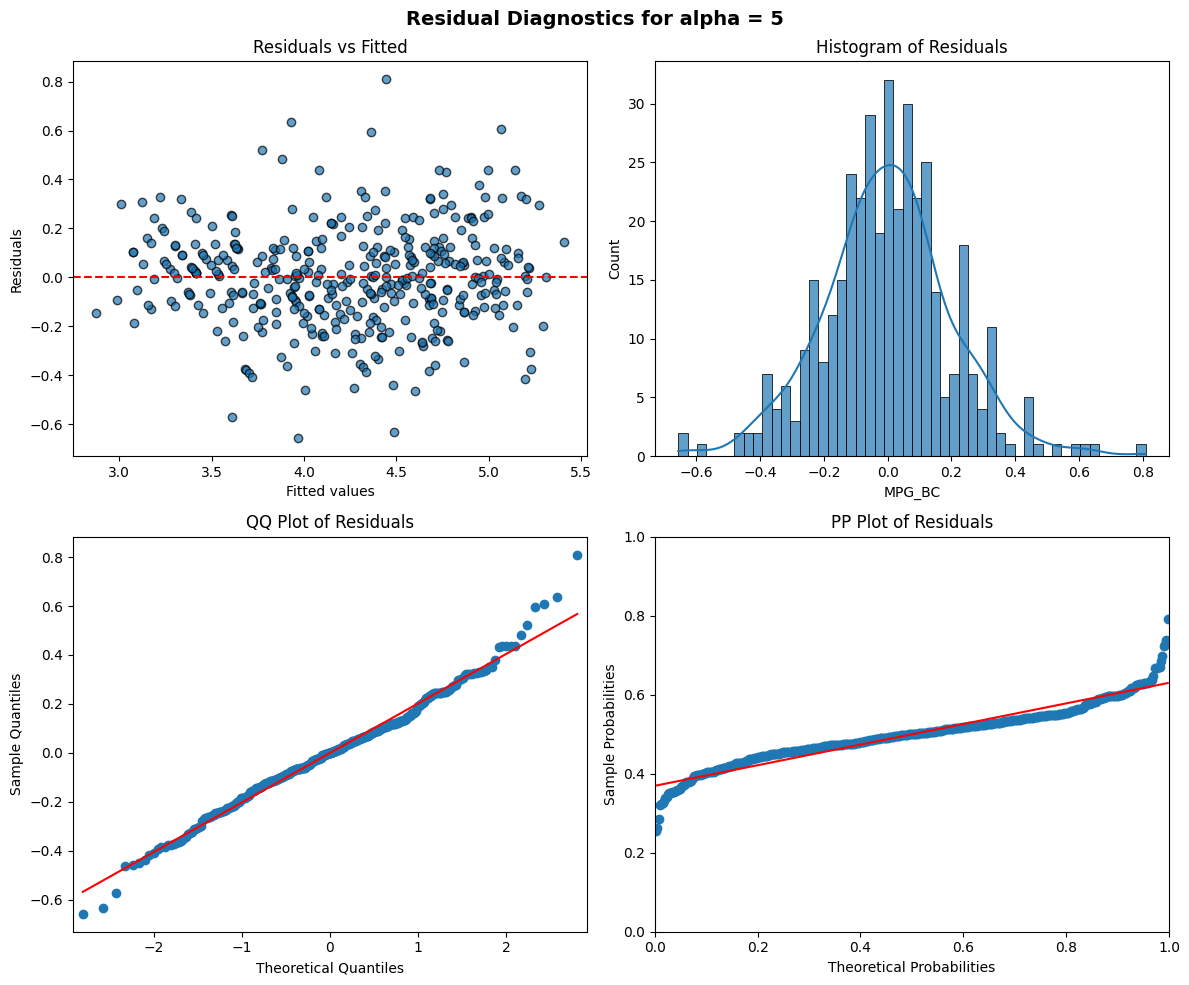

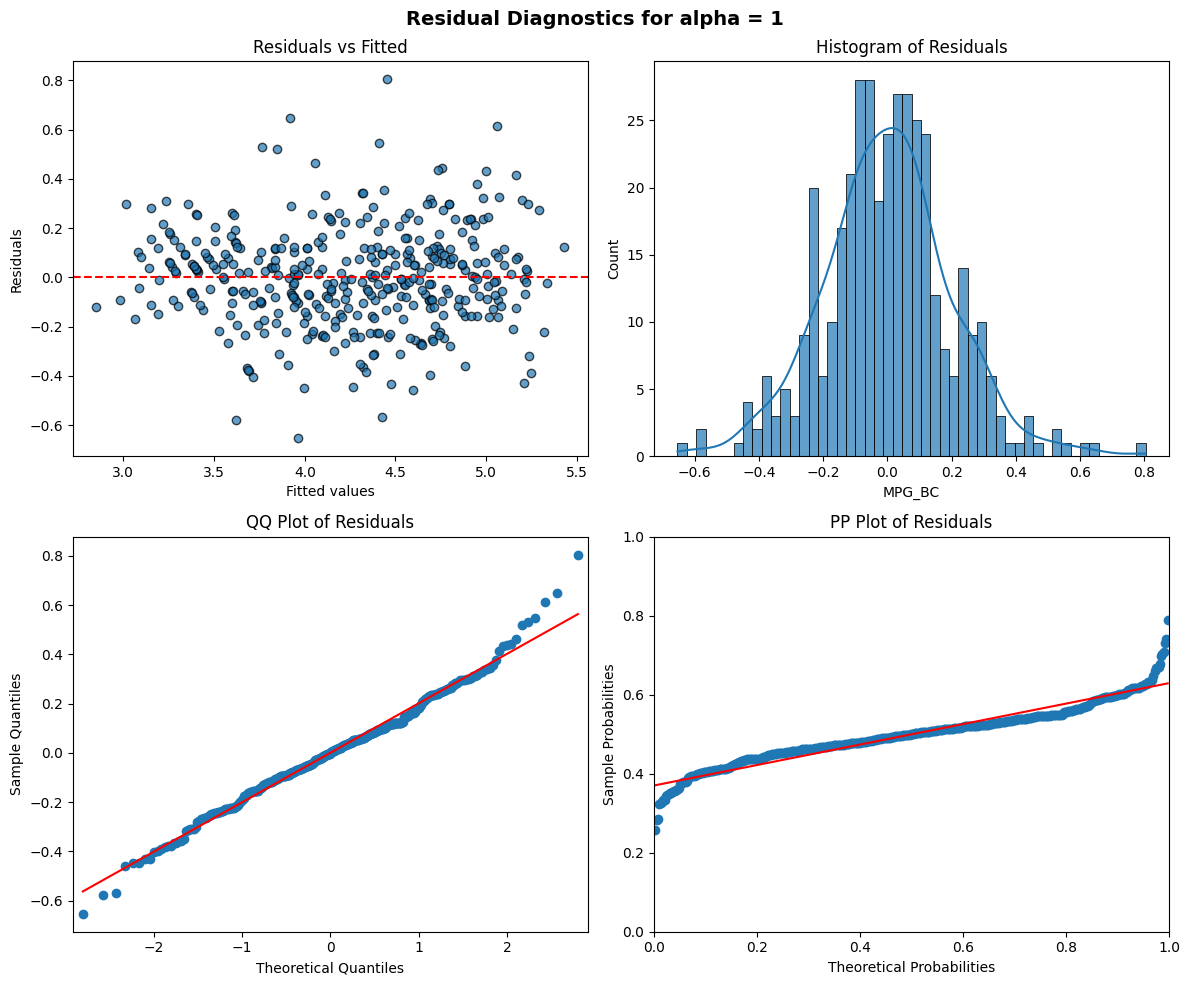

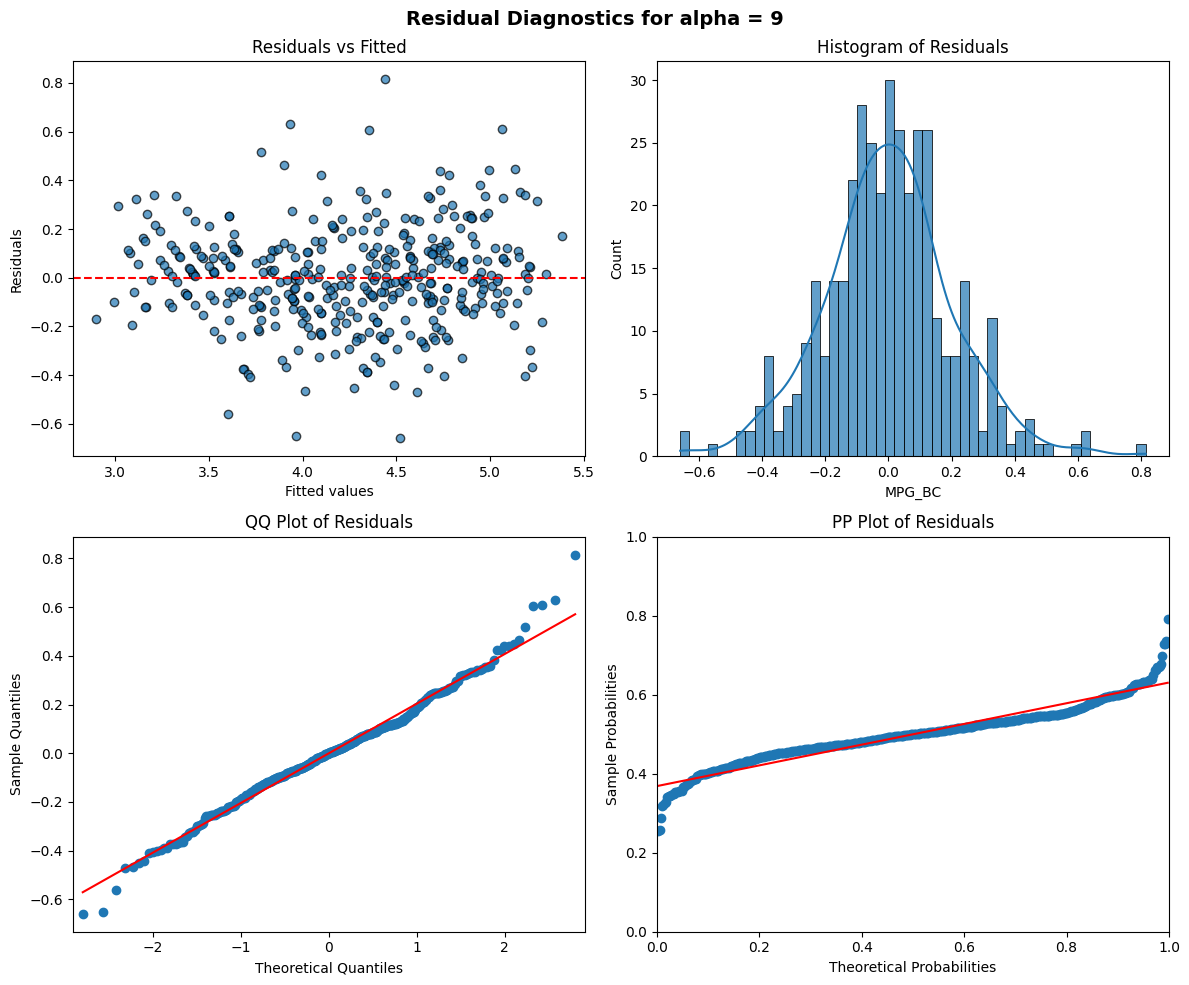

In [67]:
ridge = Ridge(alpha = 5, solver='svd')
ridge.fit(X, y)    
# Predictions
y_pred = ridge.predict(X)
diagnostic_plots(y_true = y, y_pred = y_pred,model_name="alpha = 5", figsize=(12,10))

ridge = Ridge(alpha = 1, solver='svd')
ridge.fit(X, y)    
# Predictions
y_pred = ridge.predict(X)
diagnostic_plots(y_true = y, y_pred = y_pred,model_name="alpha = 1", figsize=(12,10))

ridge = Ridge(alpha = 9, solver='svd')
ridge.fit(X, y)    
# Predictions
y_pred = ridge.predict(X)
diagnostic_plots(y_true = y, y_pred = y_pred,model_name="alpha = 9", figsize=(12,10))

#### 4.4 Residual Diagnostics Summary (Ridge Regression Models)

$\alpha = 1$:

- Residuals vs Fitted: Mild variance issues, scatter acceptable but not fully stabilized.
- Histogram: Approximately normal, slight skew.
- Q‑Q Plot: Near‑normal, mild tail deviations.
- P‑P Plot: Mostly aligned, small departures.
- Takeaway: Similar to OLS, usable but variance not fully controlled.

$\alpha = 5$:
- Residuals vs Fitted: Well‑scattered, variance consistent.
- Histogram: Bell‑shaped, close to normal.
- Q‑Q Plot: Points close to line, minor tail issues.
- P‑P Plot: Good fit overall.
- Takeaway: Best balance — residuals stable, assumptions mostly valid

$\alpha = 9$:
- Residuals vs Fitted: Variance more stabilized, scatter improved.
- Histogram: Fairly symmetric, slightly flatter than ideal.
- Q‑Q Plot: Close to line, small tail deviations.
- P‑P Plot: Well aligned, minor departures.
- Takeaway: Robust model, strong variance control, normality acceptable.

$\alpha = 10$
- Residuals vs Fitted: Stable, variance reduced further.
- Histogram: Flatter distribution, less normal.
- Q‑Q Plot: Stronger tail deviations.
- P‑P Plot: Deviations more visible at extremes.
- Takeaway: Over‑regularization — variance stable but normality weakened.

- Alpha = 1 → Residuals acceptable but variance issues remain.
- Alpha = 5 → Optimal balance: residuals close to normal, variance consistent.
- Alpha = 9 → Strong regularization, residuals robust, tails slightly off.
- Alpha = 10 → Too strong, variance stable but normality deteriorates.


#### 5. Robust regressions:


In [68]:
def robust_regression_models(X, y, formula=None):
    """
    Fit robust regression models with different norms.
    
    Parameters
    ----------
    X : pandas.DataFrame
        Predictor variables.
    y : pandas.Series
        Target variable.
    formula : str, optional
        Formula string (if using patsy). If None, uses X and y directly.
    
    Returns
    -------
    models : dict
        Dictionary of fitted robust regression models keyed by norm name.
    summaries : dict
        Dictionary of model summaries keyed by norm name.
    """
    norms = {
        "LeastSquares": LeastSquares(),
        "HuberT": HuberT(),
        "RamsayE": RamsayE(),
        "AndrewWave": AndrewWave(),
        "TukeyBiweight": TukeyBiweight(),
        "TrimmedMean": TrimmedMean(),
        "Hampel": Hampel()
    }
    
    models = {}
    summaries = {}
    
    # Add constant term
    X_const = X
    
    for name, norm in norms.items():
        model = RLM(y, X_const, M=norm)
        res = model.fit()
        models[name] = res
        summaries[name] = res.summary()
    
    return models, summaries

def robust_diagnostic_plots(res, model_name="Robust Model", figsize=(12,10)):
    """
    Diagnostic plots for residuals from a robust regression model (RLMResults).
    
    Plots:
    - Residuals vs Fitted
    - Histogram with KDE
    - QQ plot (line='r')
    - PP plot (line='r')
    
    Parameters
    ----------
    res : statsmodels.robust.robust_linear_model.RLMResults
        Fitted robust regression results object.
    model_name : str
        Name of the model to display in the figure subtitle.
    figsize : tuple
        Size of the figure.
    """
    y_true = res.model.endog
    y_pred = res.fittedvalues
    residuals = res.resid
    
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    fig.suptitle(f"Residual Diagnostics for {model_name}", fontsize=14, fontweight="bold")
    
    # Residuals vs Fitted
    axes[0,0].scatter(y_pred, residuals, edgecolor='k', alpha=0.7)
    axes[0,0].axhline(0, color='red', linestyle='--')
    axes[0,0].set_title("Residuals vs Fitted")
    axes[0,0].set_xlabel("Fitted values")
    axes[0,0].set_ylabel("Residuals")
    
    # Histogram with KDE
    sns.histplot(residuals, bins=50, kde=True, ax=axes[0,1], color="skyblue", edgecolor="k")
    axes[0,1].set_title("Histogram of Residuals (with KDE)")
    
    # QQ plot
    sm.qqplot(residuals, line='r', ax=axes[1,0])
    axes[1,0].set_title("QQ Plot of Residuals")
    
    # PP plot
    sm.ProbPlot(residuals).ppplot(line='r', ax=axes[1,1])
    axes[1,1].set_title("PP Plot of Residuals")
    
    plt.tight_layout(rect=[0, 0, 1, 1.0])  # leave space for suptitle
    plt.show()

def calculate_rms(res, model_name="Robust Model"):
    """
    Calculate RMS (Root Mean Square) of residuals from RLMResults.
    
    Parameters
    ----------
    res : statsmodels.robust.robust_linear_model.RLMResults
        Fitted robust regression results object.
    model_name : s
        Name of the model to display in the output.
    
    Returns
    -------
    rms_value : float
        RMS of residuals
    """
    residuals = res.resid
    rms_value = np.sqrt(np.mean(residuals**2))
    
    print(f"RMS value for {model_name}: {rms_value:.4f}")
    return rms_value

def plot_pp_qq(res, models_name = '',figsize=(10,5)):
    """
    Plot QQ and PP plots for residuals from a fitted Statsmodels result.
    
    Parameters
    ----------
    res : statsmodels regression results (RLMResults, OLSResults, etc.)
        Fitted regression results object.
    figsize : tuple
        Size of the figure.
    """
    residuals = res.resid
    
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle(f"Residuals Plot Model: {models_name} ", fontsize=14, fontweight="bold")
    
    # QQ plot
    sm.qqplot(residuals, line='r', ax=axes[0])
    axes[0].set_title("QQ Plot")
    
    # PP plot
    sm.ProbPlot(residuals).ppplot(line='r', ax=axes[1])
    axes[1].set_title("PP Plot")
    
    plt.tight_layout(rect=[0, 0, 1, 1.00])
    plt.show()

def plot_predicted_vs_actual(res,models_name = 'OLS Models', figsize=(6,6)):
    """
    Plot Predicted vs Actual values for a fitted Statsmodels result.
    
    Parameters
    ----------
    res : statsmodels regression results (RLMResults, OLSResults, etc.)
        Fitted regression results object.
    figsize : tuple
        Size of the figure.
    """
    y_true = res.model.endog
    y_pred = res.fittedvalues
    
    plt.figure(figsize=figsize)
    plt.suptitle(f"Residuals Plot Model: {models_name} ", fontsize=14, fontweight="bold")
    plt.scatter(y_true, y_pred, alpha=0.7, edgecolor='k')
    plt.plot([y_true.min(), y_true.max()],
             [y_true.min(), y_true.max()],
             color='red', linestyle='--', linewidth=2)
    
    plt.title("Predicted vs Actuals")
    plt.xlabel("Actual values")
    plt.ylabel("Predicted values")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()


In [69]:
X,y = dematrix_from_formula(formula = formulas_single_line_bc_org, df___ = df_encoded_org)
# Run robust regressions
RlmModels, summaries = robust_regression_models(X, y,formula=None)
# Print summaries for each norm
for name, summary in summaries.items():
    #print(f"\n=== Robust Regression ({name}) ===")
    #print(summary)
    pass


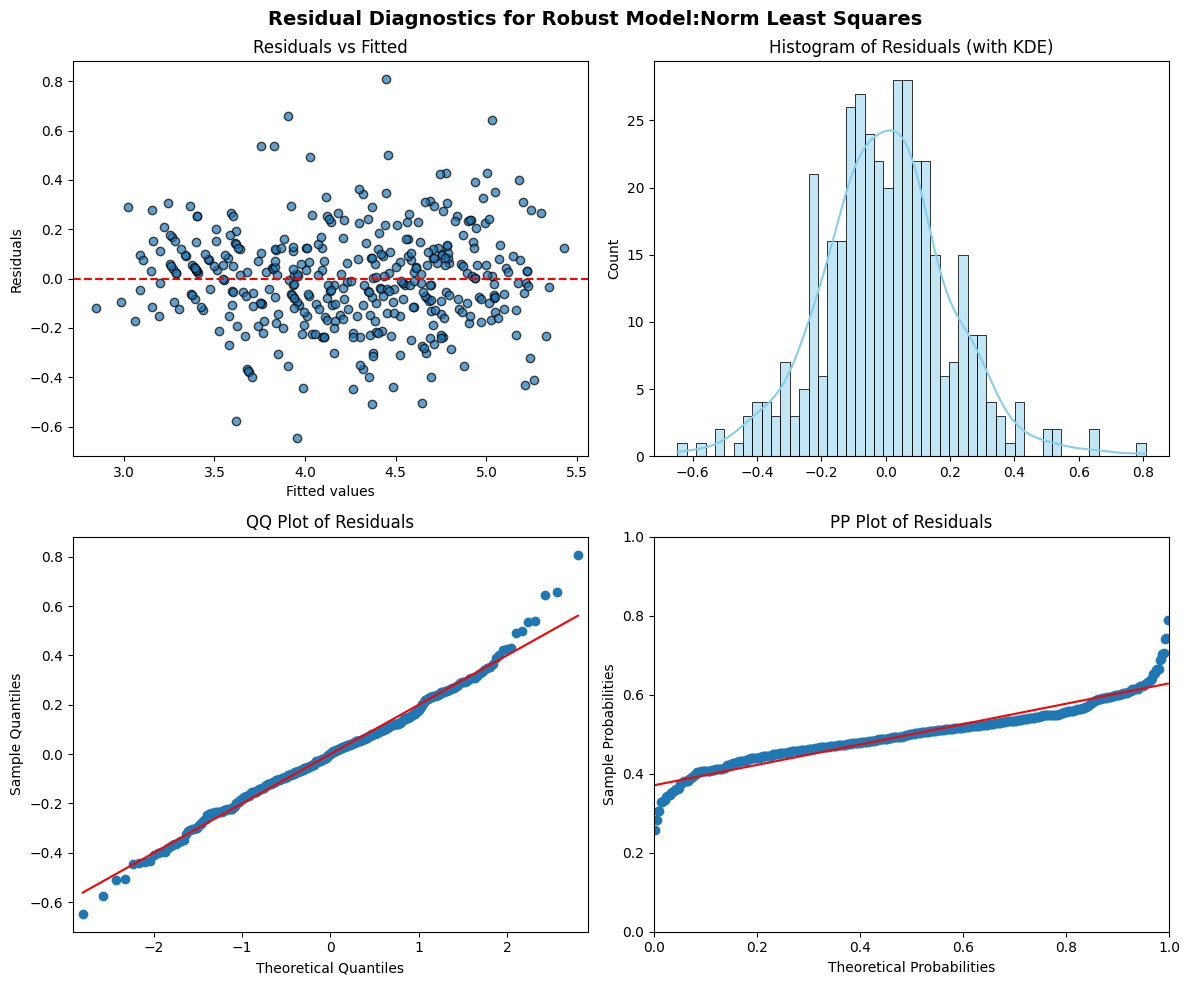

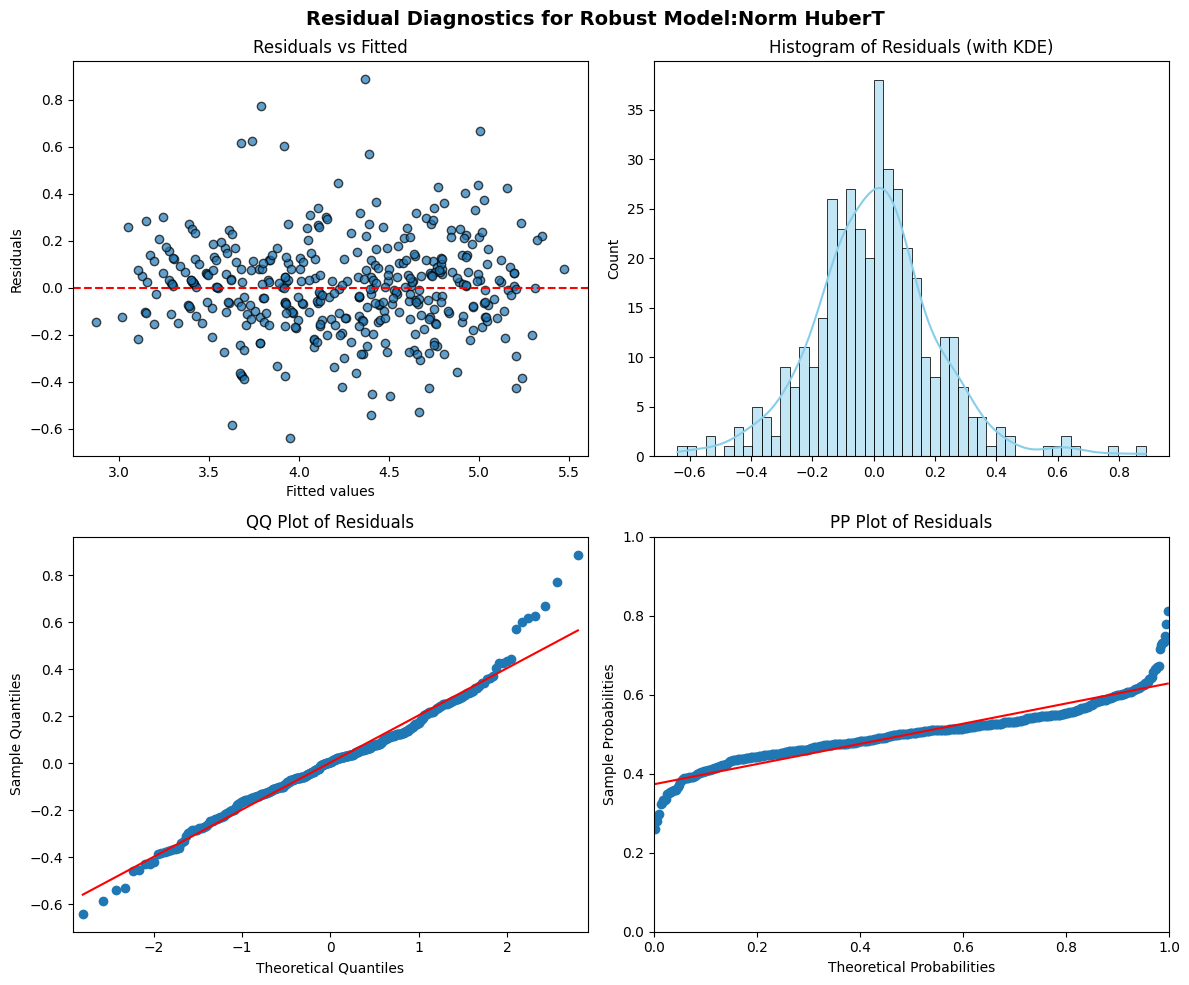

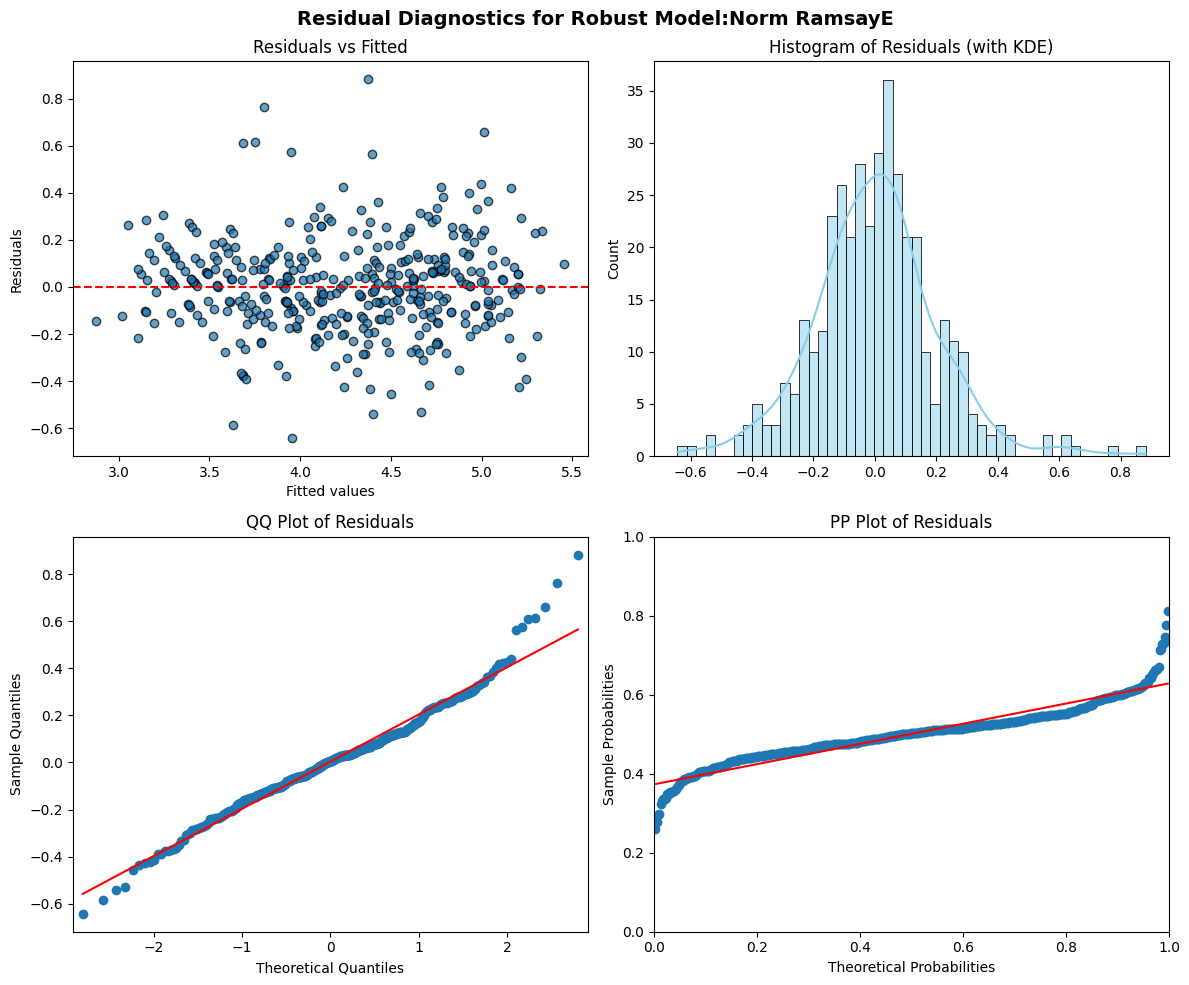

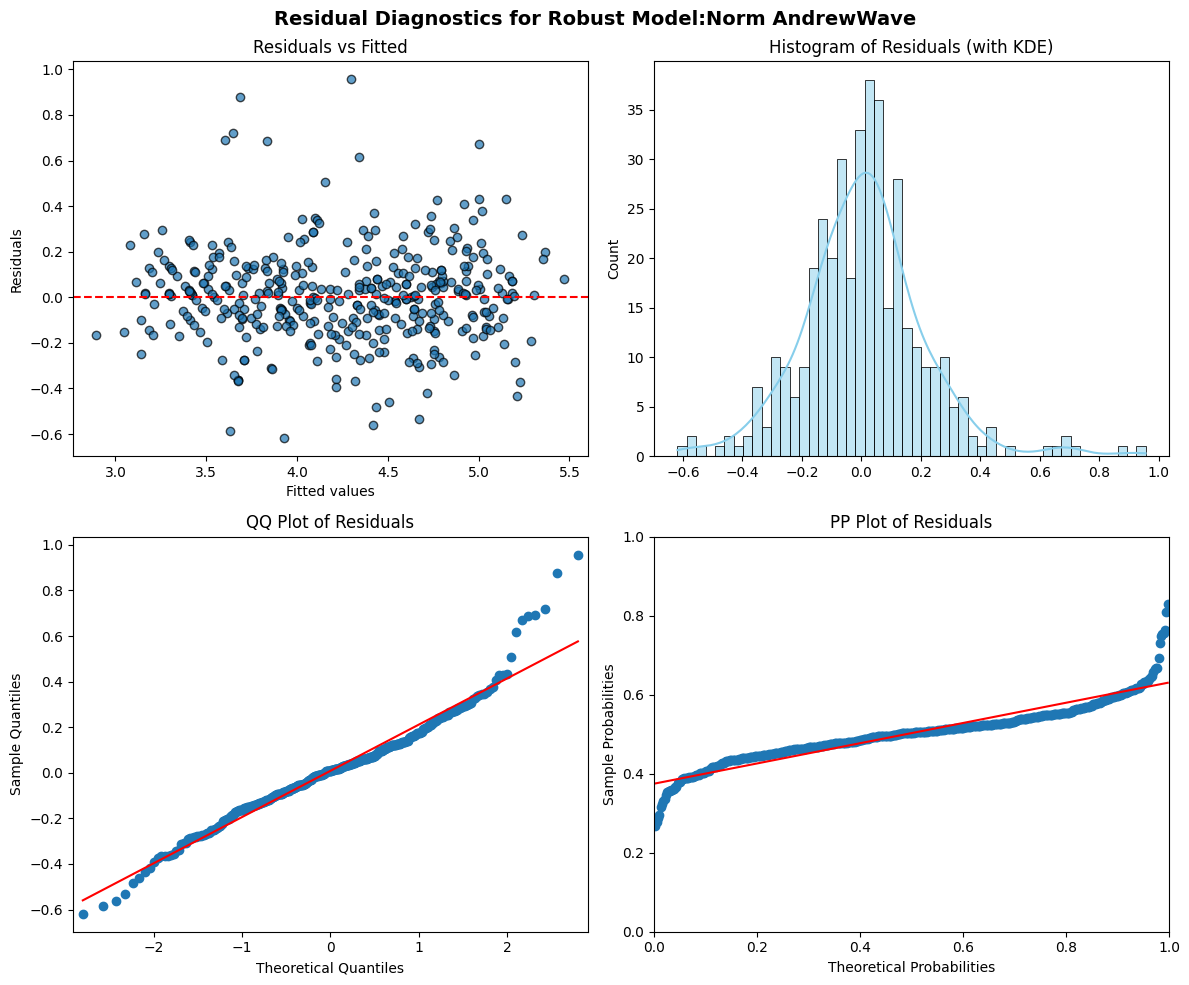

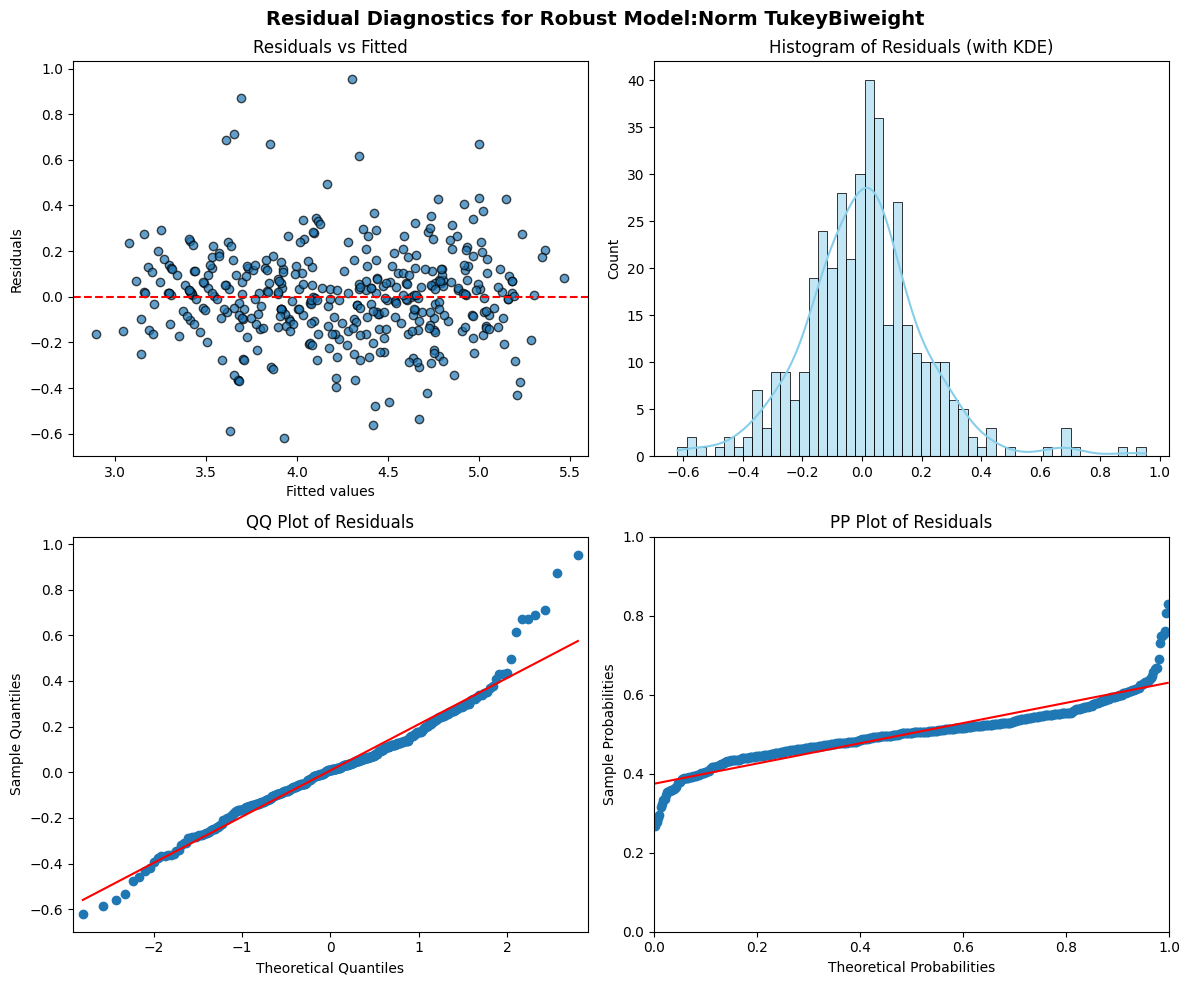

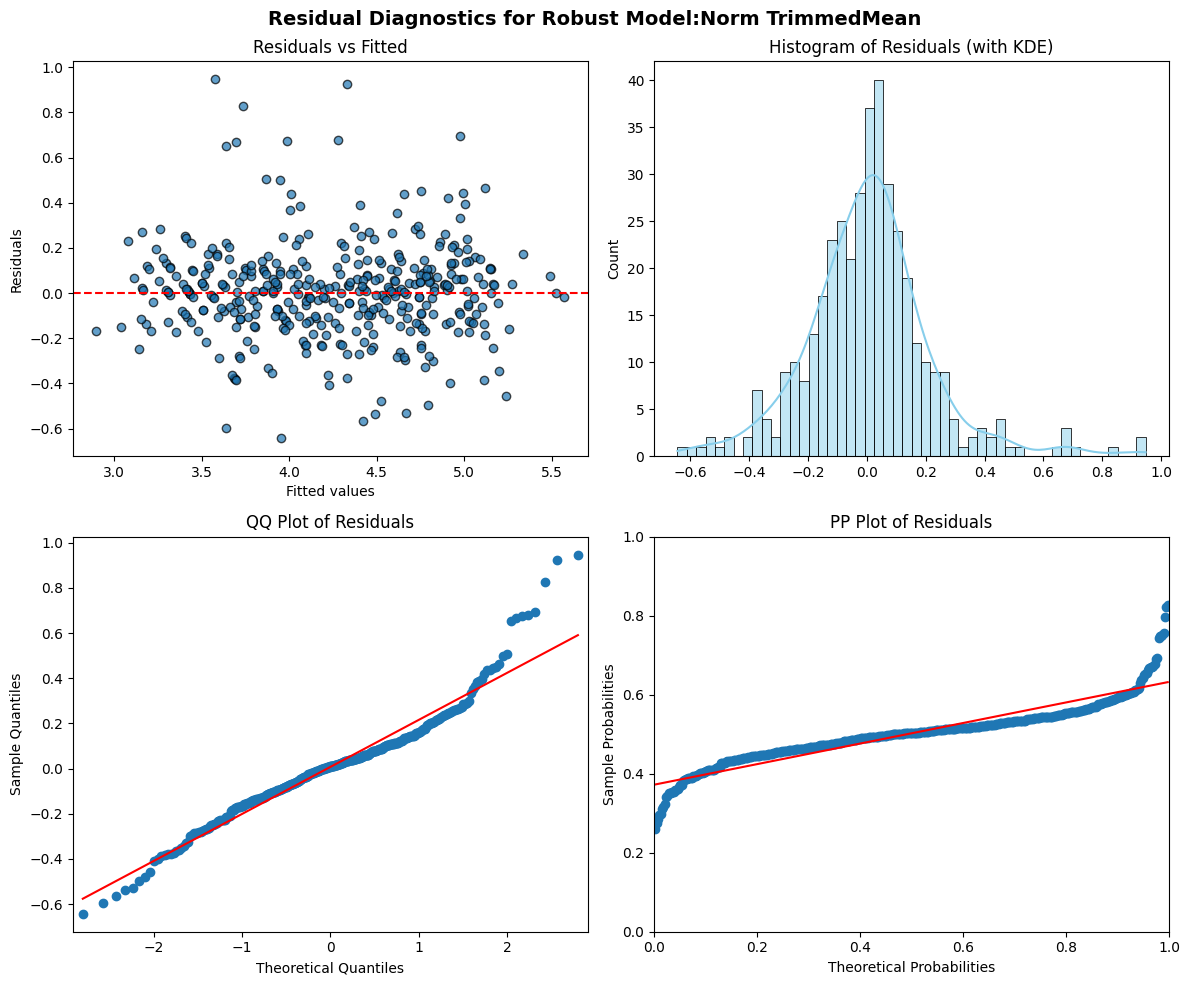

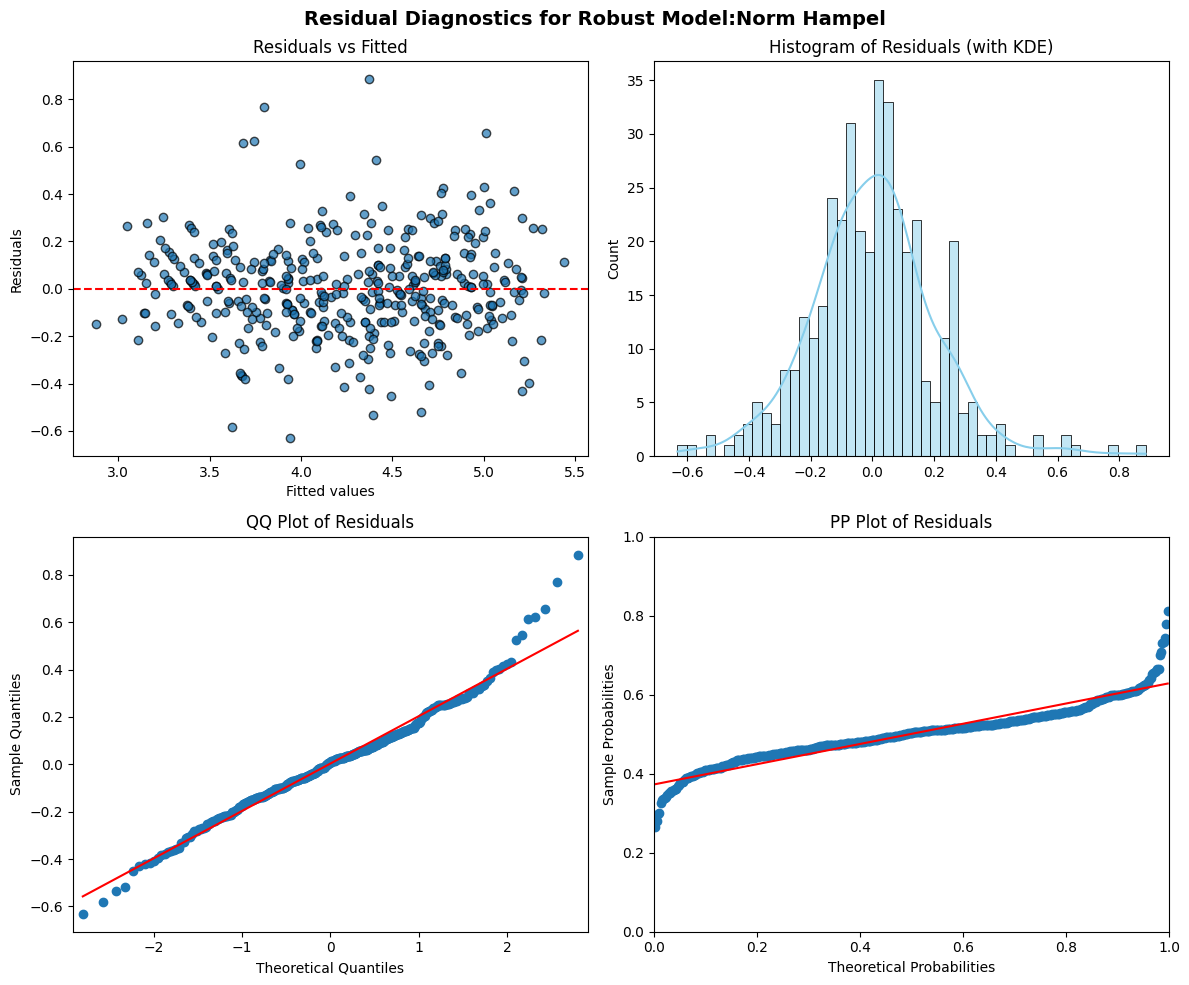

In [70]:
robust_diagnostic_plots(res = RlmModels['LeastSquares'], 
                        model_name="Robust Model:Norm Least Squares", 
                        figsize=(12,10))

robust_diagnostic_plots(res = RlmModels['HuberT'], 
                        model_name="Robust Model:Norm HuberT", 
                        figsize=(12,10))

robust_diagnostic_plots(res = RlmModels['RamsayE'], 
                        model_name="Robust Model:Norm RamsayE", 
                        figsize=(12,10))

robust_diagnostic_plots(res = RlmModels['AndrewWave'], 
                        model_name="Robust Model:Norm AndrewWave", 
                        figsize=(12,10))

robust_diagnostic_plots(res = RlmModels['TukeyBiweight'], 
                        model_name="Robust Model:Norm TukeyBiweight", 
                        figsize=(12,10))

robust_diagnostic_plots(res = RlmModels['TrimmedMean'], 
                        model_name="Robust Model:Norm TrimmedMean", 
                        figsize=(12,10))

robust_diagnostic_plots(res = RlmModels['Hampel'], 
                        model_name="Robust Model:Norm Hampel", 
                        figsize=(12,10))

In [71]:
# Calculate RMS
rms_val = calculate_rms(res = RlmModels['LeastSquares'], model_name="RLM:Norm LeastSquares")

# Calculate RMS
rms_val = calculate_rms(res = RlmModels['HuberT'], model_name="RLM:Norm HuberT")

rms_val = calculate_rms(res = RlmModels['RamsayE'], model_name="RLM:Norm RamsayE")

rms_val = calculate_rms(res = RlmModels['AndrewWave'], model_name="RLM:Norm AndrewWave")

rms_val = calculate_rms(res = RlmModels['TukeyBiweight'], model_name="RLM:Norm TukeyBiweight")

rms_val = calculate_rms(res = RlmModels['TrimmedMean'], model_name="RLM:Norm TrimmedMean")

rms_val = calculate_rms(res = RlmModels['Hampel'], model_name="RLM:Norm Hampel")

RMS value for RLM:Norm LeastSquares: 0.1991
RMS value for RLM:Norm HuberT: 0.2010
RMS value for RLM:Norm RamsayE: 0.2005
RMS value for RLM:Norm AndrewWave: 0.2048
RMS value for RLM:Norm TukeyBiweight: 0.2044
RMS value for RLM:Norm TrimmedMean: 0.2118
RMS value for RLM:Norm Hampel: 0.2001


In [72]:
#Model 1- cov_type="HC0"
model = smf.ols(formula = formulas_single_line_bc_org, data=df_encoded_org)
res_two_line_org_hc0 = model.fit(cov_type="HC0")
res_two_line_org_hc1 = model.fit(cov_type="HC1")
res_two_line_org_hc2 = model.fit(cov_type="HC2")
res_two_line_org_hc3 = model.fit(cov_type="HC3")

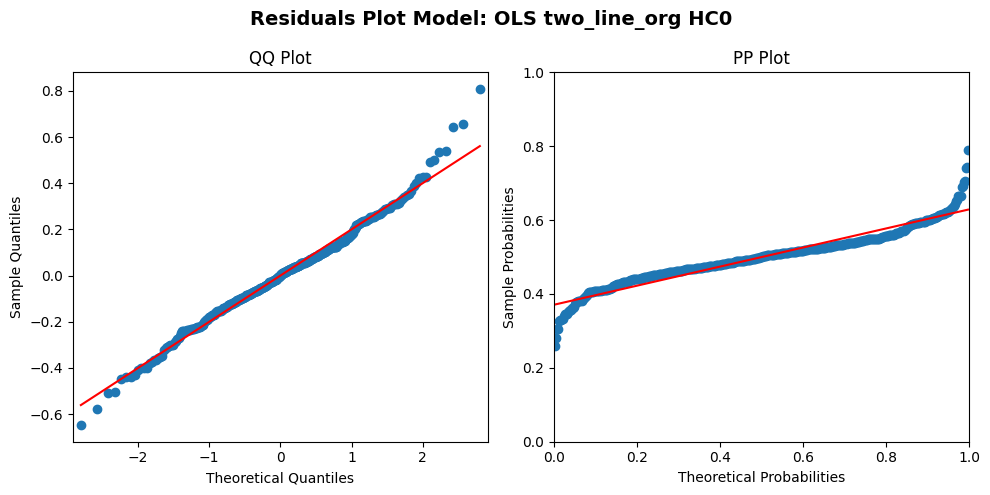

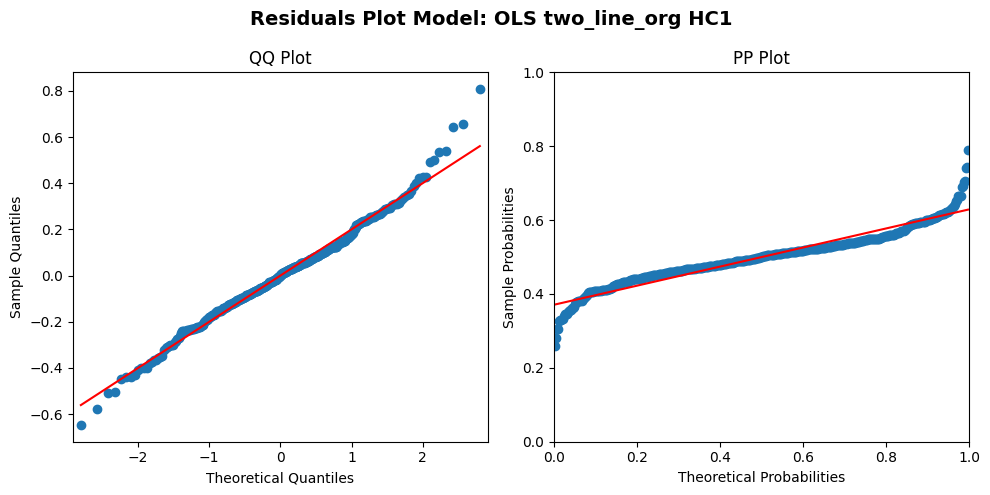

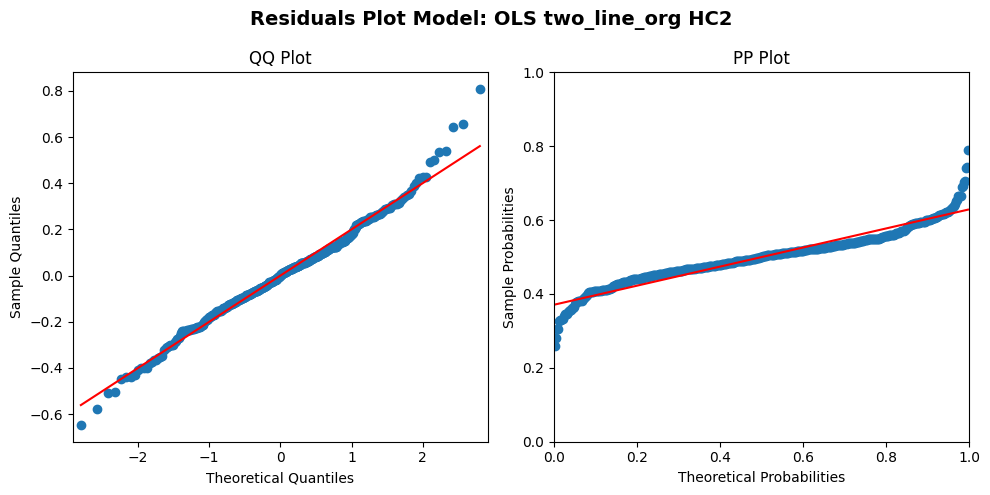

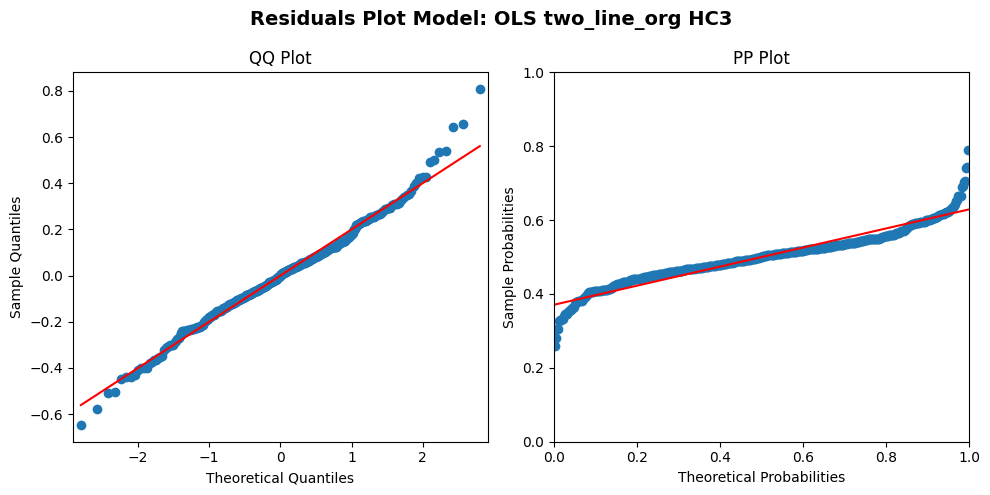

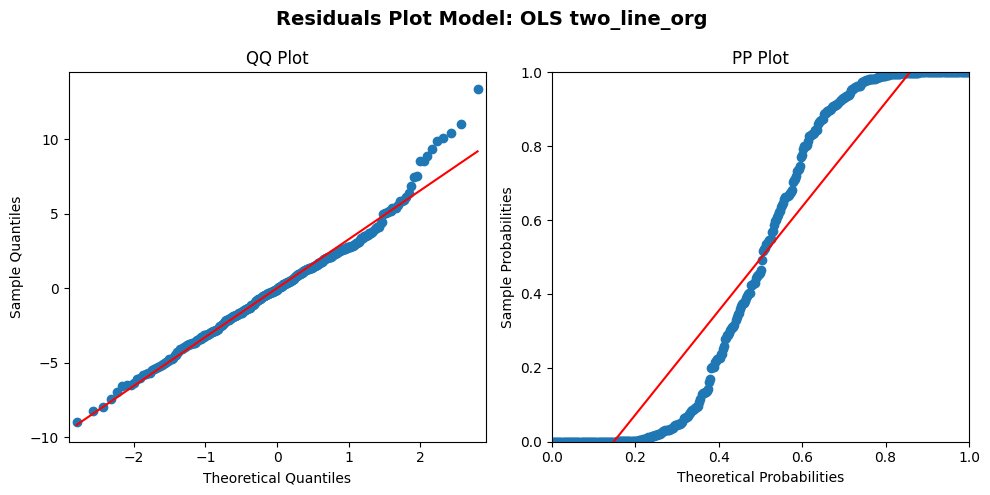

In [73]:
plot_pp_qq(res = res_two_line_org_hc0, models_name = 'OLS two_line_org HC0',figsize=(10,5))
plot_pp_qq(res = res_two_line_org_hc1, models_name = 'OLS two_line_org HC1',figsize=(10,5))
plot_pp_qq(res = res_two_line_org_hc2, models_name = 'OLS two_line_org HC2',figsize=(10,5))
plot_pp_qq(res = res_two_line_org_hc3, models_name = 'OLS two_line_org HC3',figsize=(10,5))
plot_pp_qq(res = res_two_line_org,models_name='OLS two_line_org' ,figsize=(10,5))

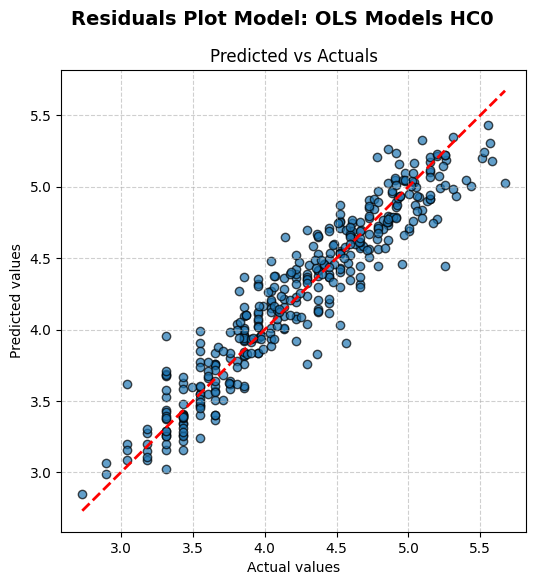

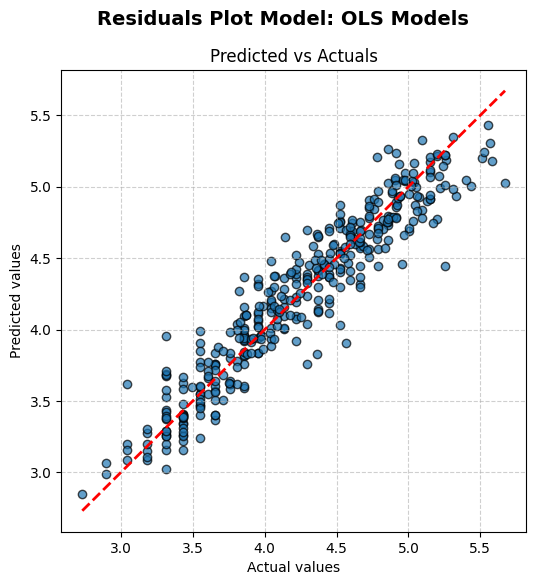

In [74]:
plot_predicted_vs_actual(res = res_two_line_org_hc0,models_name = 'OLS Models HC0', figsize=(6,6))
plot_predicted_vs_actual(res = res_one_line_org_bc,models_name = 'OLS Models', figsize=(6,6))

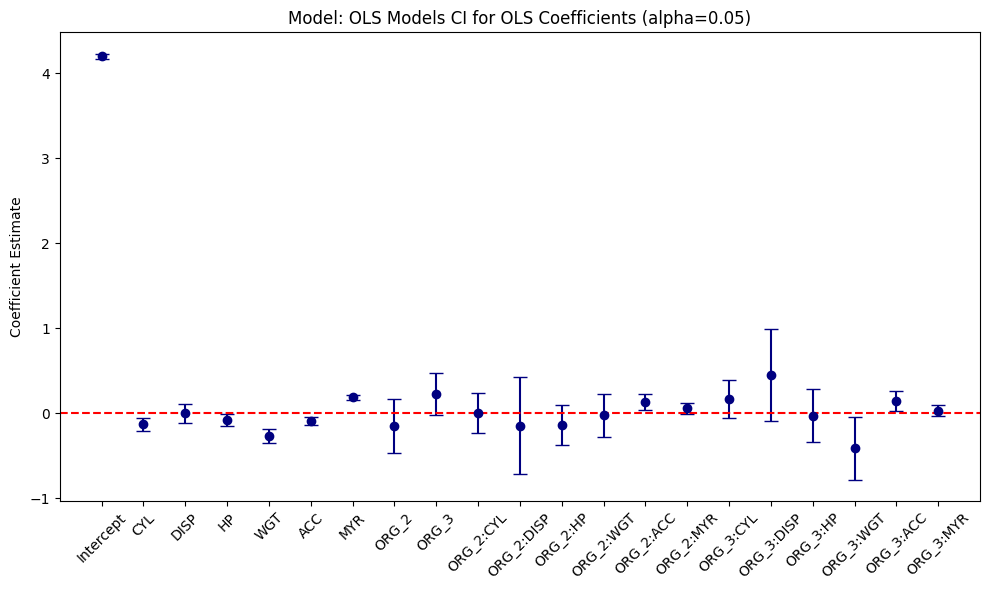

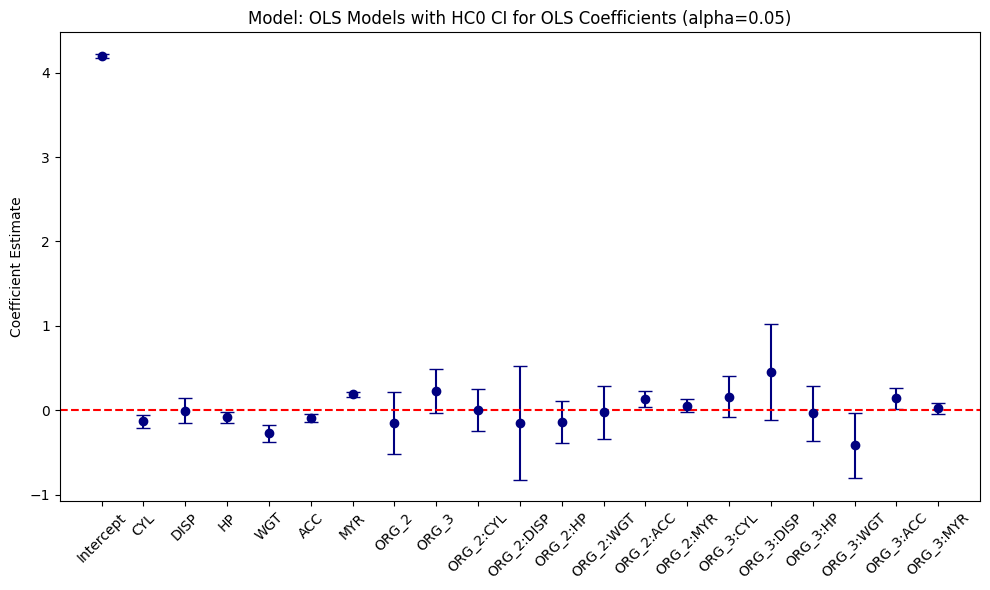

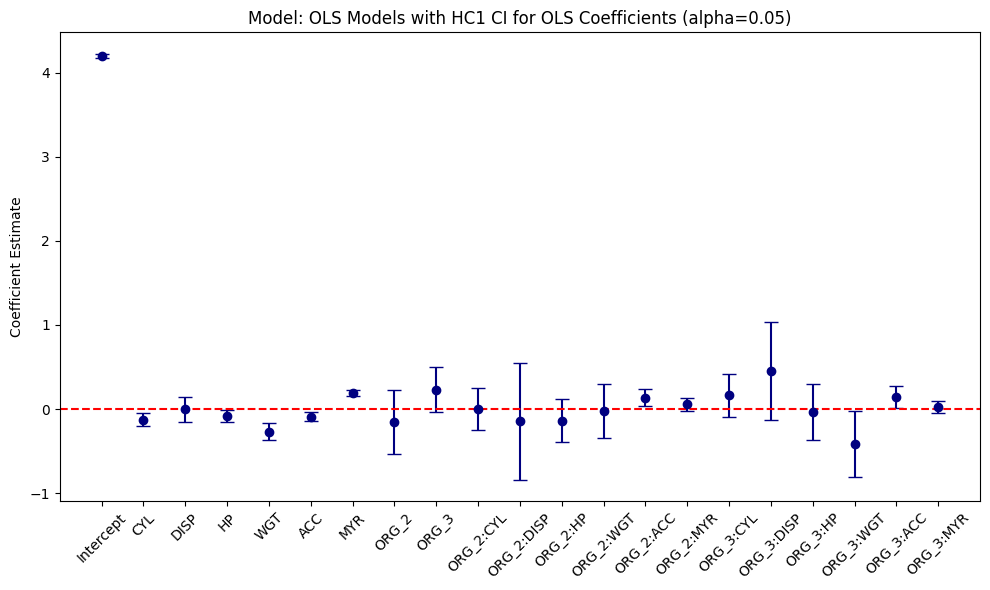

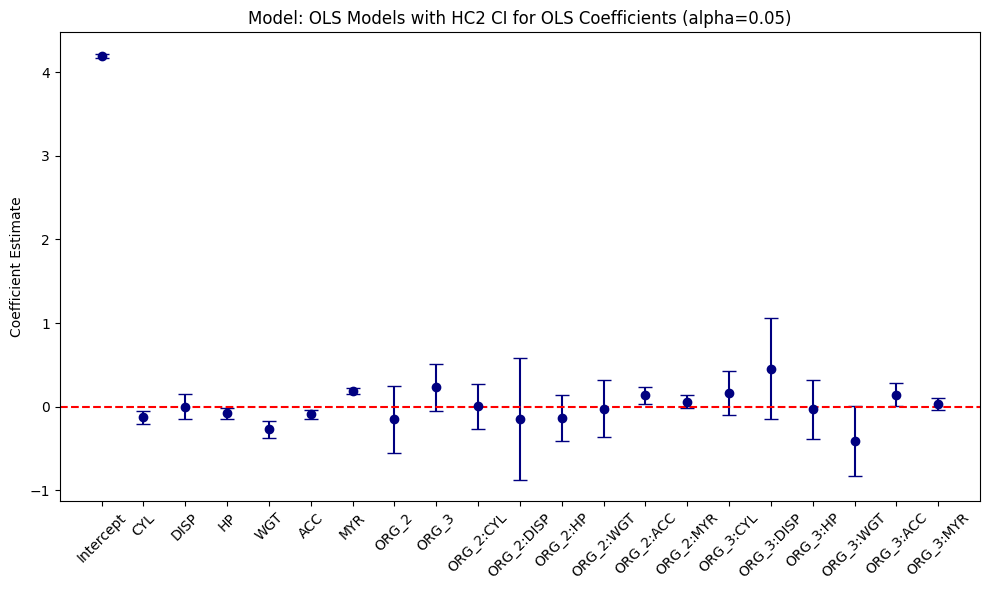

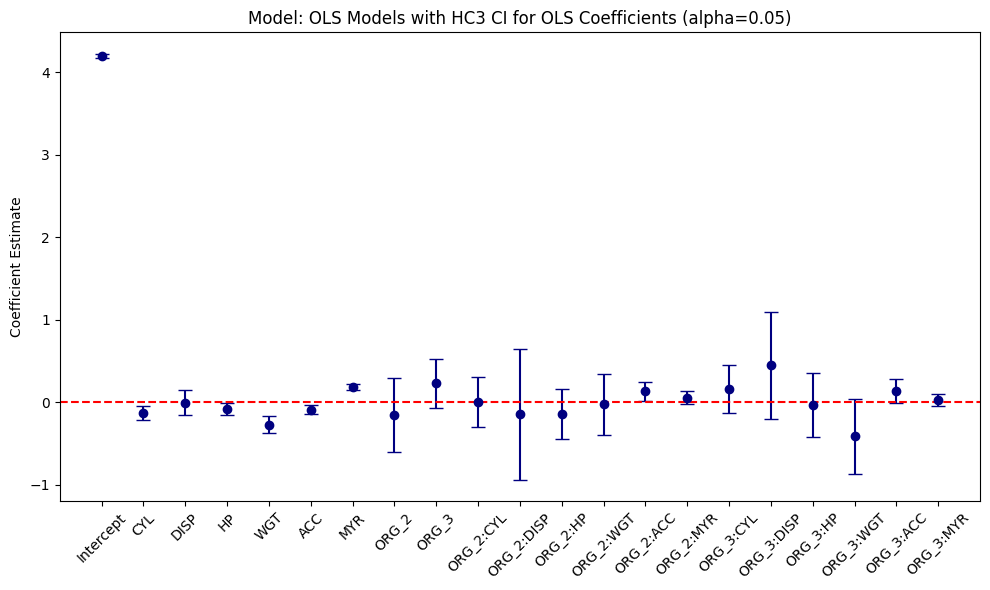

In [75]:
comparison = pd.DataFrame({
    "coef_default": res_one_line_org_bc.params,
    "se_default": res_two_line_org_hc0.bse,
    "se_hc0": res_two_line_org_hc0.bse
})
#print(comparison)

plot_confidence_intervals(res = res_one_line_org_bc, alpha=0.05, models_name = 'OLS Models',figsize=(10,6))
plot_confidence_intervals(res = res_two_line_org_hc0, alpha=0.05, models_name = 'OLS Models with HC0',figsize=(10,6))
plot_confidence_intervals(res = res_two_line_org_hc1, alpha=0.05, models_name = 'OLS Models with HC1',figsize=(10,6))
plot_confidence_intervals(res = res_two_line_org_hc2, alpha=0.05, models_name = 'OLS Models with HC2',figsize=(10,6))
plot_confidence_intervals(res = res_two_line_org_hc3, alpha=0.05, models_name = 'OLS Models with HC3',figsize=(10,6))

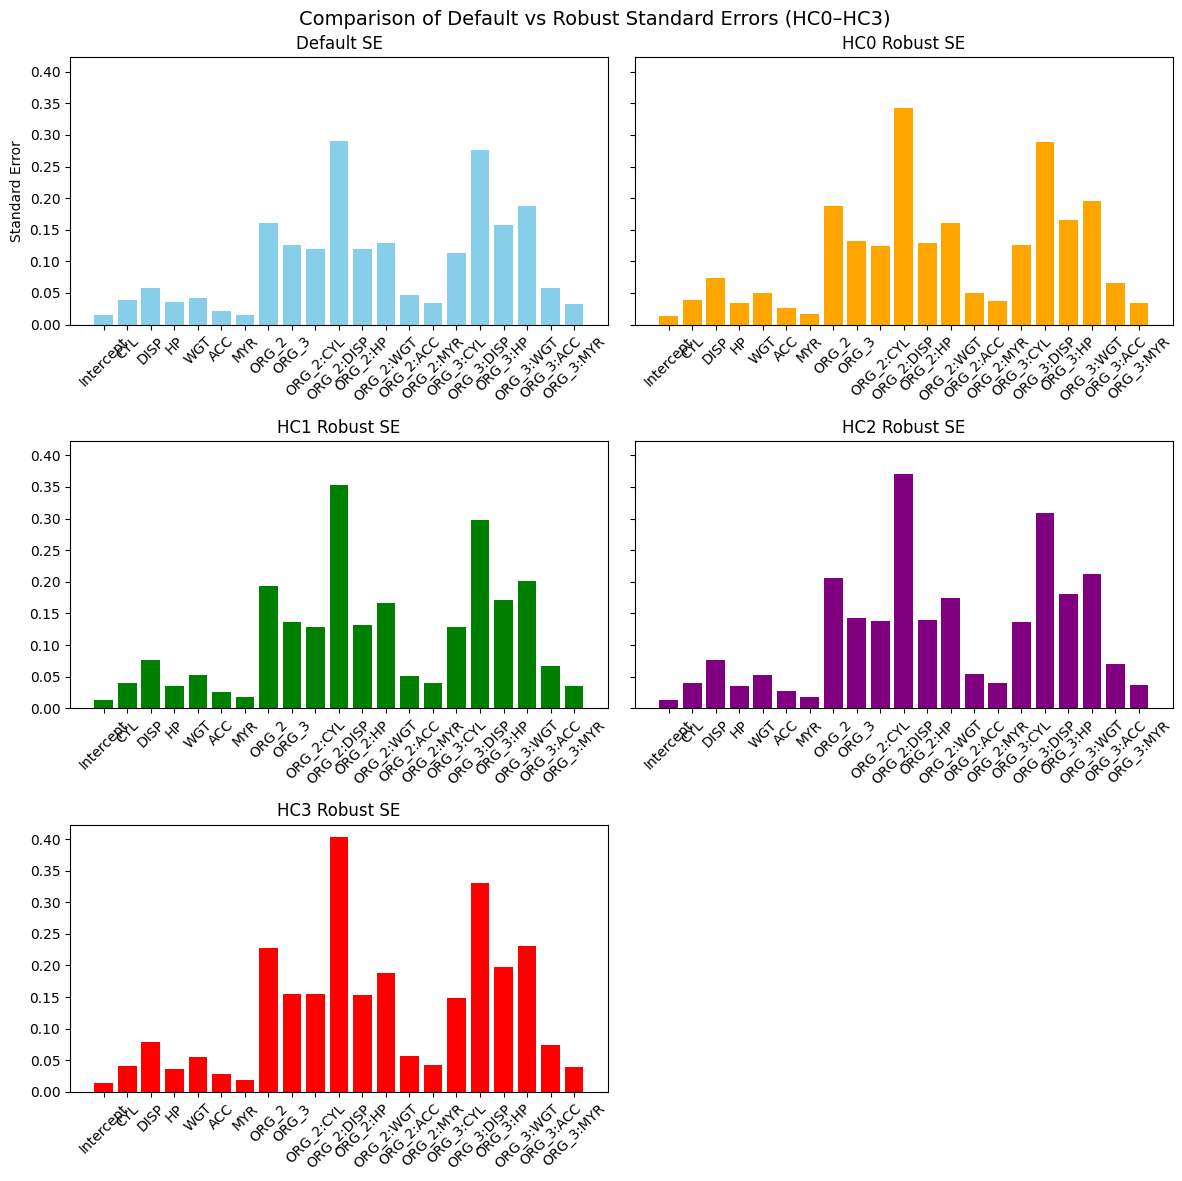

In [76]:
def plot_se_comparison(se_default, se_hc0, se_hc1, se_hc2, se_hc3, labels):
    x = np.arange(len(labels))

    fig, axes = plt.subplots(3, 2, figsize=(12, 12), sharey=True)

    # Flatten axes for easy indexing
    axes = axes.flatten()

    # Default SE
    axes[0].bar(x, se_default, color="skyblue")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(labels, rotation=45)
    axes[0].set_ylabel("Standard Error")
    axes[0].set_title("Default SE")

    # HC0 Robust SE
    axes[1].bar(x, se_hc0, color="orange")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels, rotation=45)
    axes[1].set_title("HC0 Robust SE")

    # HC1 Robust SE
    axes[2].bar(x, se_hc1, color="green")
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(labels, rotation=45)
    axes[2].set_title("HC1 Robust SE")

    # HC2 Robust SE
    axes[3].bar(x, se_hc2, color="purple")
    axes[3].set_xticks(x)
    axes[3].set_xticklabels(labels, rotation=45)
    axes[3].set_title("HC2 Robust SE")

    # HC3 Robust SE
    axes[4].bar(x, se_hc3, color="red")
    axes[4].set_xticks(x)
    axes[4].set_xticklabels(labels, rotation=45)
    axes[4].set_title("HC3 Robust SE")

    # Hide the unused subplot (bottom-right)
    axes[5].axis("off")

    plt.suptitle("Comparison of Default vs Robust Standard Errors (HC0–HC3)", fontsize=14)
    plt.tight_layout()
    plt.show()

plot_se_comparison(se_default = res_one_line_org_bc.bse, 
                   se_hc0 = res_two_line_org_hc0.bse, 
                   se_hc1 = res_two_line_org_hc1.bse, 
                   se_hc2 = res_two_line_org_hc2.bse,                    
                   se_hc3 = res_two_line_org_hc3.bse,
                   labels = res_one_line_org_bc.params.index)

#### Polynomials regressions analysis

In [77]:
# --- Define formulas ---

# Cubic spline (degree=3) for continuous predictors
formula_cubic_all = """
MPG_BC ~ CYL 
+ bs(DISP, df=4, degree=3) 
+ bs(HP, df=4, degree=3) 
+ bs(WGT, df=4, degree=3) 
+ bs(ACC, df=4, degree=3) 
+ bs(MYR, df=4, degree=3)
"""

# Restricted cubic spline (natural spline)
formula_rcs_all = """
MPG_BC ~ CYL 
+ cr(DISP, df=4) 
+ cr(HP, df=4) 
+ cr(WGT, df=4) 
+ cr(ACC, df=4) 
+ cr(MYR, df=4)
"""

# B-spline
formula_bspline_all = """
MPG_BC ~ CYL 
+ bs(DISP, df=4) 
+ bs(HP, df=4) 
+ bs(WGT, df=4) 
+ bs(ACC, df=4) 
+ bs(MYR, df=4)
"""

df_ols_stat_spline = pd.DataFrame({})

In [78]:
# Cubic spline model
y, X_cubic = dmatrices(formula_cubic_all, data=df_encoded_org, return_type='dataframe')
res_model_cubic = sm.OLS(y, X_cubic).fit()
df_ols_stat_spline['model_cubic_all'] = extract_ols_stats(fit_obj = res_model_cubic)

# Restricted cubic spline model
y, X_rcs = dmatrices(formula_rcs_all, data=df_encoded_org, return_type='dataframe')
res_model_rcs = sm.OLS(y, X_rcs).fit()
df_ols_stat_spline['model_rcs_all'] = extract_ols_stats(fit_obj = res_model_rcs)

# B-spline model
y, X_bspline = dmatrices(formula_bspline_all, data=df_encoded_org, return_type='dataframe')
res_model_bspline = sm.OLS(y, X_bspline).fit()
df_ols_stat_spline['model_bspline_all']  = extract_ols_stats(fit_obj = res_model_bspline)

# Save DataFrame as text table into Notepad file
with open("splineModels.txt", "w") as f:
    f.write(df_ols_stat_spline.to_string(index=True))
# --- Summaries ---
# print("Cubic spline model:\n", res_model_cubic.summary())
# print("\nRestricted cubic spline model:\n", res_model_rcs.summary())
# print("\nB-spline model:\n", res_model_bspline.summary())

#### 6.1 Basic of spline

#### Overall Fit (R² and Adj. R²)

All three models fit the data very well (>0.90). Cubic and B-spline models have slightly higher R² than restricted cubic.

#### Model Stability:

The condition number for restricted cubic spline is astronomically large (~2.6e16), which indicates severe multicollinearity or numerical instability. Cubic and B-spline models have a manageable condition number (~67), suggesting more stable estimation.

#### Information Criteria (AIC/BIC):

Restricted cubic spline has the lowest AIC and BIC, which suggests it balances fit and complexity slightly better. However, the instability (huge condition number) makes it risky despite favorable AIC/BIC.

**Restricted cubic spline** shows slightly better AIC/BIC but suffers from extreme instability (condition number). **Cubic spline and B-spline** models are stable, with identical results, and provide excellent fit (R² ≈ 0.907).For practical purposes, **cubic/B-spline models** are preferable here because they balance fit and numerical stability

#### ***Qus: Why Cubic and B-spline Results Are Identical ?***

In setup, we specified bs(..., degree=3) for cubic splines. A B-spline of degree 3 is exactly a cubic spline basis. That’s why model_cubic_all and model_bspline_all produce identical results they are mathematically equivalent in this case.


In [79]:
# --- Displacement spline ---
# Displacement spline
formula_disp_cubic = "MPG_BC ~ CYL + bs(DISP, df=4, degree=3) + HP + WGT + ACC + MYR"
y, X_disp = dmatrices(
    formula_disp_cubic,
    data=df_encoded_org, return_type='dataframe'
)
res_model_disp = sm.OLS(y, X_disp).fit()
df_ols_stat_spline['model_cubic_disp'] = extract_ols_stats(fit_obj = res_model_disp)

# --- Horsepower spline ---
formula_hp_cubic  =  "MPG_BC ~ CYL + DISP + bs(HP, df=4, degree=3) + WGT + ACC + MYR"
y, X_hp = dmatrices(
    formula_hp_cubic,
    data=df_encoded_org, return_type='dataframe'    
)
res_model_hp = sm.OLS(y, X_hp).fit()
df_ols_stat_spline['model_cubic_hp'] = extract_ols_stats(fit_obj = res_model_hp)

# --- Weight spline ---
formula_wgt_cubic = "MPG_BC ~ CYL + DISP + HP + bs(WGT, df=4, degree=3) + ACC + MYR"
y, X_wgt = dmatrices(
    formula_wgt_cubic,
    data=df_encoded_org, return_type='dataframe'
)
res_model_wgt = sm.OLS(y, X_wgt).fit()
df_ols_stat_spline['model_cubic_wgt'] = extract_ols_stats(fit_obj = res_model_wgt)

# --- Acceleration spline ---
formula_acc_cubic = "MPG_BC ~ CYL + DISP + HP + WGT + bs(ACC, df=4, degree=3) + MYR"
y, X_acc = dmatrices(
    formula_acc_cubic,
    data=df_encoded_org, return_type='dataframe'
)
res_model_acc = sm.OLS(y, X_acc).fit()
df_ols_stat_spline['model_cubic_acc'] = extract_ols_stats(fit_obj = res_model_acc)

# --- Model year spline ---
formula_myr_cubic = "MPG_BC ~ CYL + DISP + HP + WGT + ACC + bs(MYR, df=4, degree=3)"
y, X_myr = dmatrices(
    formula_myr_cubic,
    data=df_encoded_org, return_type='dataframe'
)
res_model_myr = sm.OLS(y, X_myr).fit()
df_ols_stat_spline['model_cubic_myr'] = extract_ols_stats(fit_obj = res_model_myr)

with open("splineModels.txt", "w") as f:
    f.write(df_ols_stat_spline.to_string(index=True))
# --- Summaries ---
#print("Displacement spline model:\n", model_disp.summary())
#print("\nHorsepower spline model:\n", model_hp.summary())
#print("\nWeight spline model:\n", model_wgt.summary())
#print("\nAcceleration spline model:\n", model_acc.summary())
#print("\nModel year spline model:\n", model_myr.summary())

#### 6.2 Final conclusions on overall performance:

- Best Overall Models:
    - Cubic All and B-Spline All are tied for best overall performance (R² ≈ 0.907, Log-Likelihood ≈ 100.78).
    - Stable condition numbers (~67).
    - These are the most reliable for full regression.

- Restricted Cubic Spline (RCS All):
    - Slightly better AIC/BIC (suggesting better balance of fit vs. complexity).
    - But condition number is astronomically large (~2.6e16), indicating severe instability.
    - Not recommended despite favorable fit statistics

- Individual Variable Splines:
    - Displacement (DISP) spline is the strongest single-variable nonlinear predictor (highest R² among singles).
    - Model Year (MYR) spline is very stable (lowest condition number ≈ 22), though fit is weaker than DISP.
    - Horsepower (HP) and Weight (WGT) are decent, with WGT being most stable among them.
    - Acceleration (ACC) is weakest (lowest R², highest AIC/BIC).

Model Ranking:

- Best Overall (Stable) → Cubic All / B-Spline All (tie)
- Potential but Risky → RCS All (unstable despite good AIC/BIC)
- Best Single Variable (Fit) → Cubic DISP
- Best Single Variable (Stability) → Cubic MYR (lowest condition number)
- Next Best Singles → Cubic HP and Cubic WGT
- Weakest → Cubic ACC

Cubic All / B-Spline All are the most reliable and best-performing approaches. If you want to highlight one nonlinear effect, Displacement is the most impactful predictor, while Model Year is the most stable. Restricted cubic spline looks appealing on paper but is too unstable for practical use.

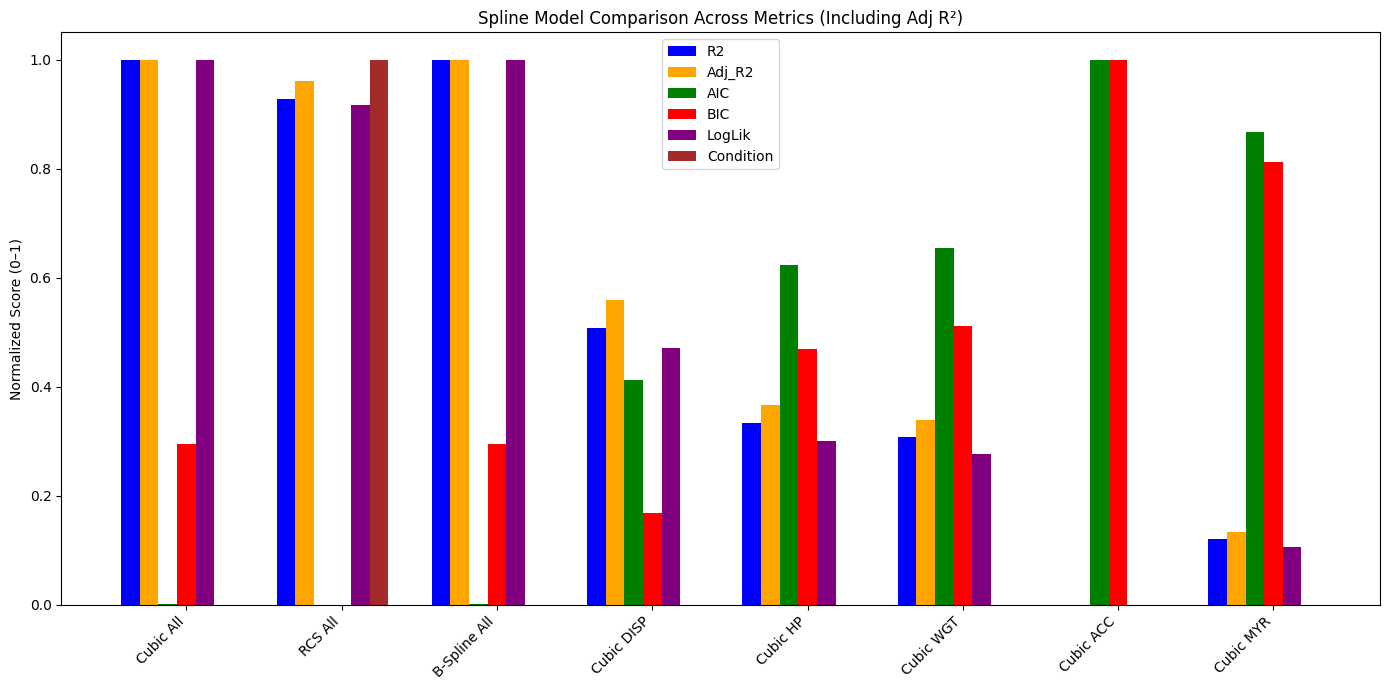

In [80]:
# Model statistics (from uploaded file)
data = {
    "Model": [
        "Cubic All", "RCS All", "B-Spline All",
        "Cubic DISP", "Cubic HP", "Cubic WGT", "Cubic ACC", "Cubic MYR"
    ],
    "R2": [
        0.906788, 0.904394, 0.906788,
        0.8905, 0.884706, 0.883842, 0.873653, 0.877659
    ],
    "Adj_R2": [
        0.901498, 0.900315, 0.901498,
        0.88792, 0.881989, 0.881106, 0.870677, 0.874777
    ],
    "AIC": [
        -157.568893, -157.628976, -157.568893,
        -118.436004, -98.223847, -95.300189, -62.340358, -74.969616
    ],
    "BIC": [
        -70.201133, -90.117525, -70.201133,
        -78.723386, -58.511228, -55.587571, -22.62774, -35.256998
    ],
    "LogLik": [
        100.784447, 95.814488, 100.784447,
        69.218002, 59.111923, 57.650095, 41.170179, 47.484808
    ],
    "Condition": [
        66.778461, 2.6388328383891892e16, 66.778461,
        50.286472, 51.853646, 45.313358, 64.290887, 22.03532
    ]
}

df______ = pd.DataFrame(data)

# --- Normalize metrics for grouped plotting ---
metrics = ["R2", "Adj_R2", "AIC", "BIC", "LogLik", "Condition"]
df_norm = df______.copy()
for m in metrics:
    df_norm[m] = (df______[m] - df______[m].min()) / (df______[m].max() - df______[m].min())

# --- Plot grouped bar chart ---
plt.figure(figsize=(14, 7))
bar_width = 0.12
x = range(len(df______["Model"]))
colors = ["blue", "orange", "green", "red", "purple", "brown"]

for i, (m, c) in enumerate(zip(metrics, colors)):
    plt.bar([p + i*bar_width for p in x], df_norm[m], width=bar_width, label=m, color=c)

plt.xticks([p + (len(metrics)/2)*bar_width for p in x], df______["Model"], rotation=45, ha="right")
plt.ylabel("Normalized Score (0–1)")
plt.title("Spline Model Comparison Across Metrics (Including Adj R²)")
plt.legend()
plt.tight_layout()
plt.show()

- R² (blue) → Fit quality (higher = better).
- Adjusted R² (orange) → Fit quality adjusted for number of predictors.
- AIC (green) → Akaike Information Criterion (lower = better).
- BIC (red) → Bayesian Information Criterion (lower = better).
- Log-Likelihood (purple) → Higher = better likelihood of the model given the data.
- Condition Number (brown) → Lower = more numerically stable (less multicollinearity).

#### Cubic All / B-Spline All: 
Tall blue and orange bars → highest R² and Adjusted R². Strong purple bar (Log-Likelihood). Moderate brown bar (Condition Number) → stable.✅ Best overall balance of fit and stability

#### RCS All
Competitive R² and Adjusted R². Green and red bars (AIC/BIC) are favorable. But brown bar (Condition Number) is extremely high → severe instability. Looks good statistically but unreliable in practice.

#### Cubic DISP
Lower R² than full models but still strong. Very short brown bar → most stable single-variable spline. Shows displacement is the most impactful nonlinear predictor.

#### Cubic MYR (Model Year)
Moderate R² and Adjusted R². Very short brown bar → most numerically stable single-variable spline. Stability is excellent, though fit is weaker than DISP


The chart confirms that Cubic All / B-Spline All are the best overall models, balancing fit and stability. Displacement spline is the strongest single nonlinear predictor, while Model Year spline is the most stable. Restricted cubic spline looks appealing on paper but is too unstable for practical use.


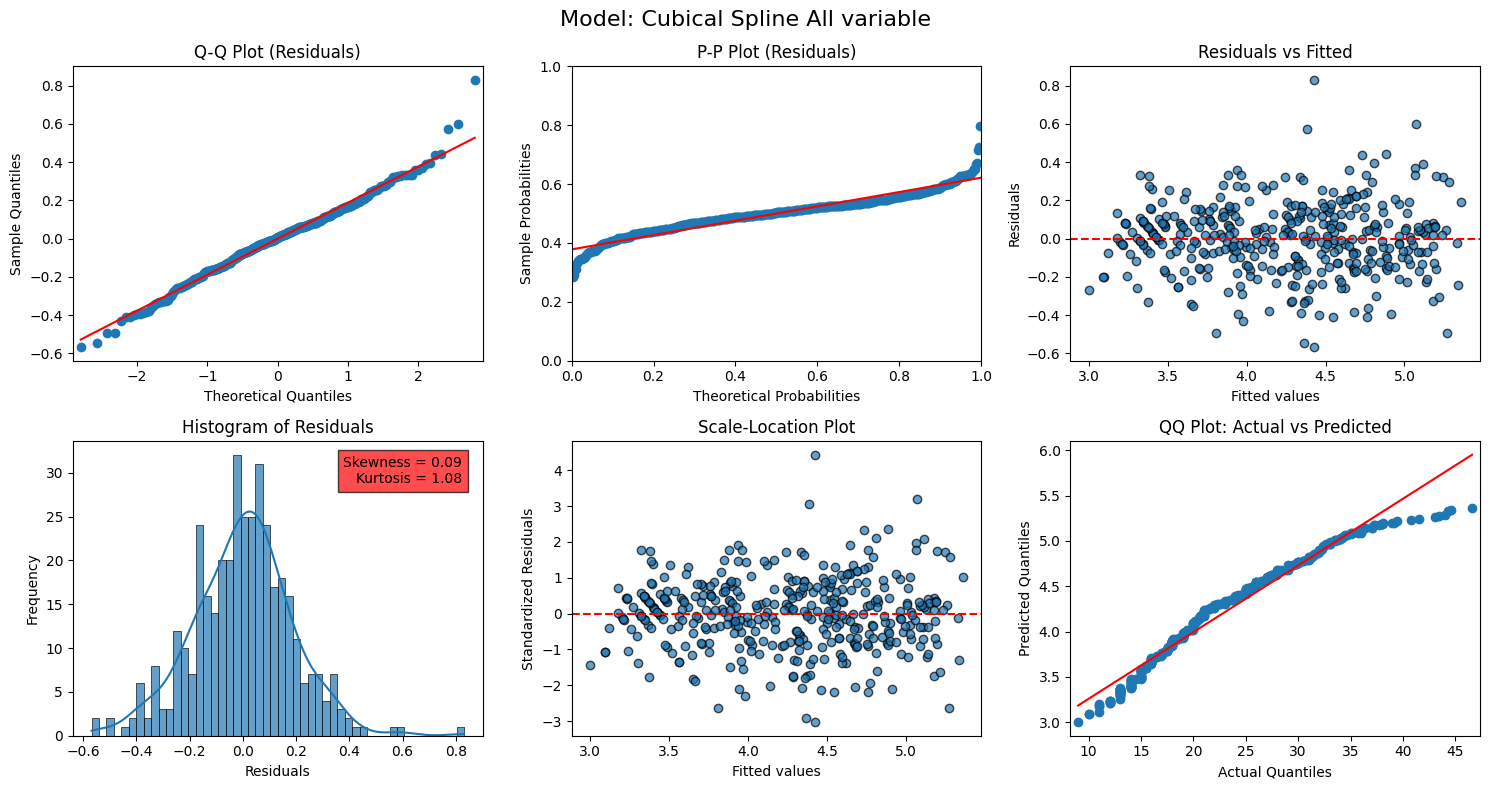

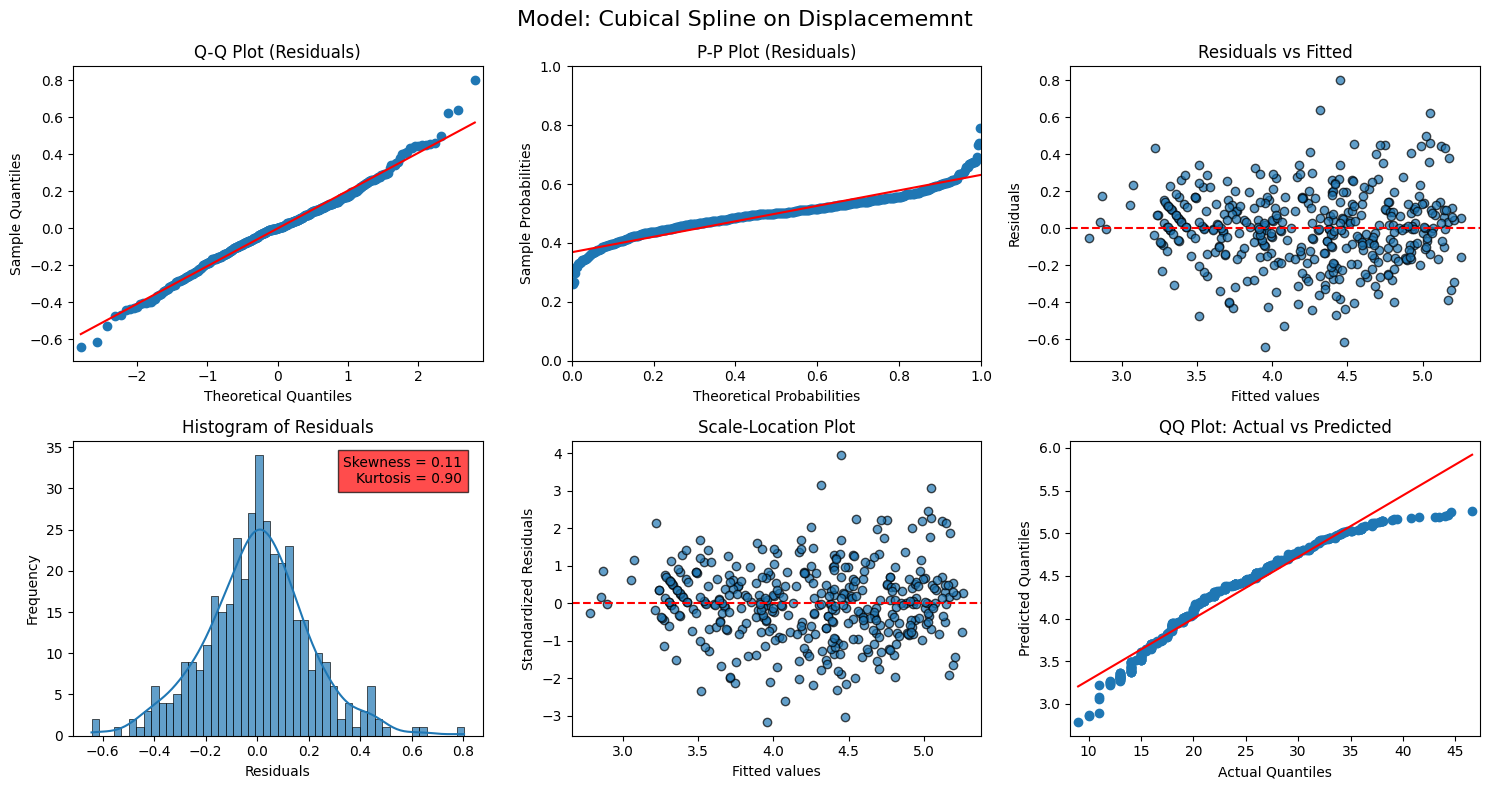

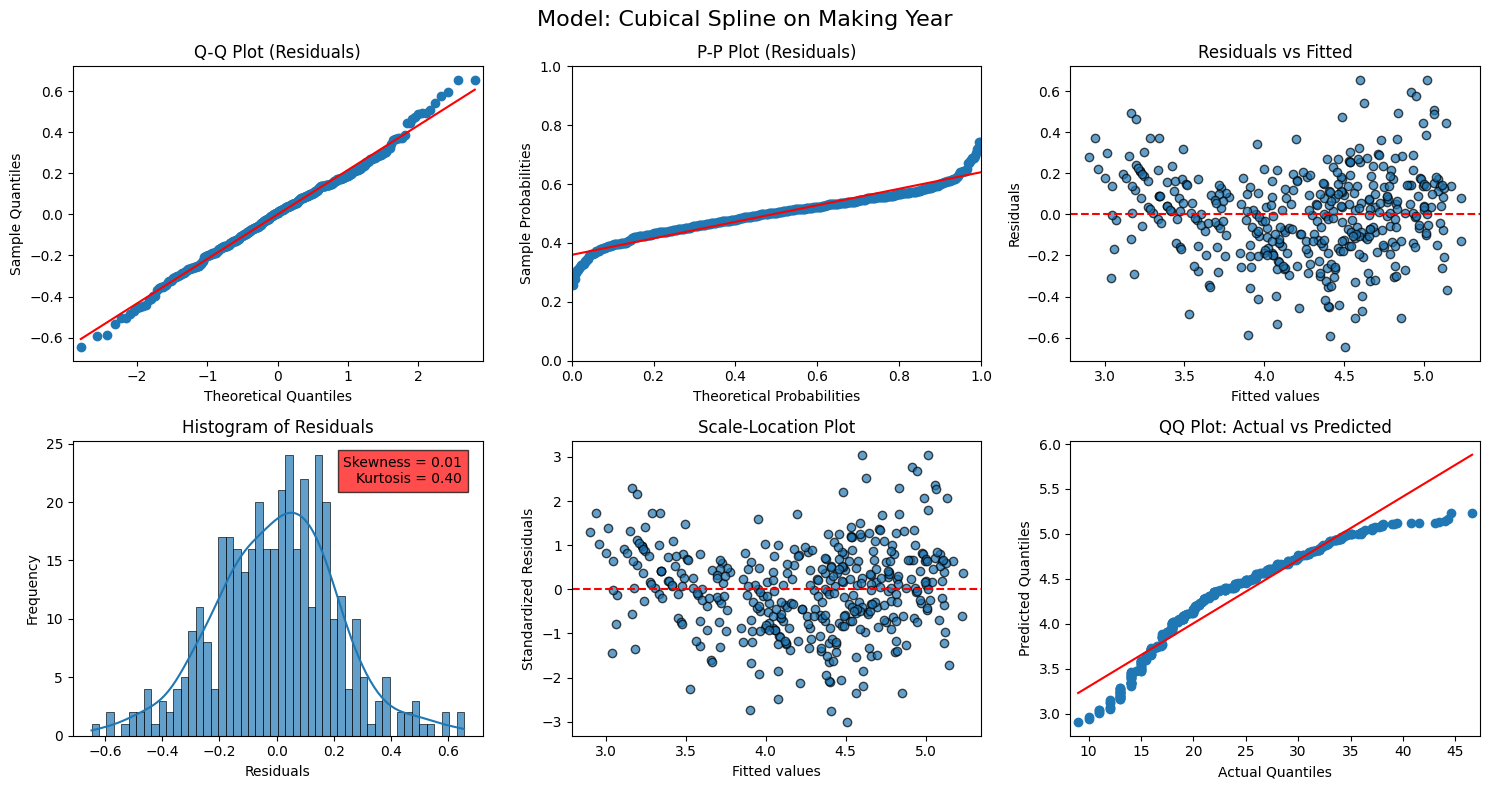

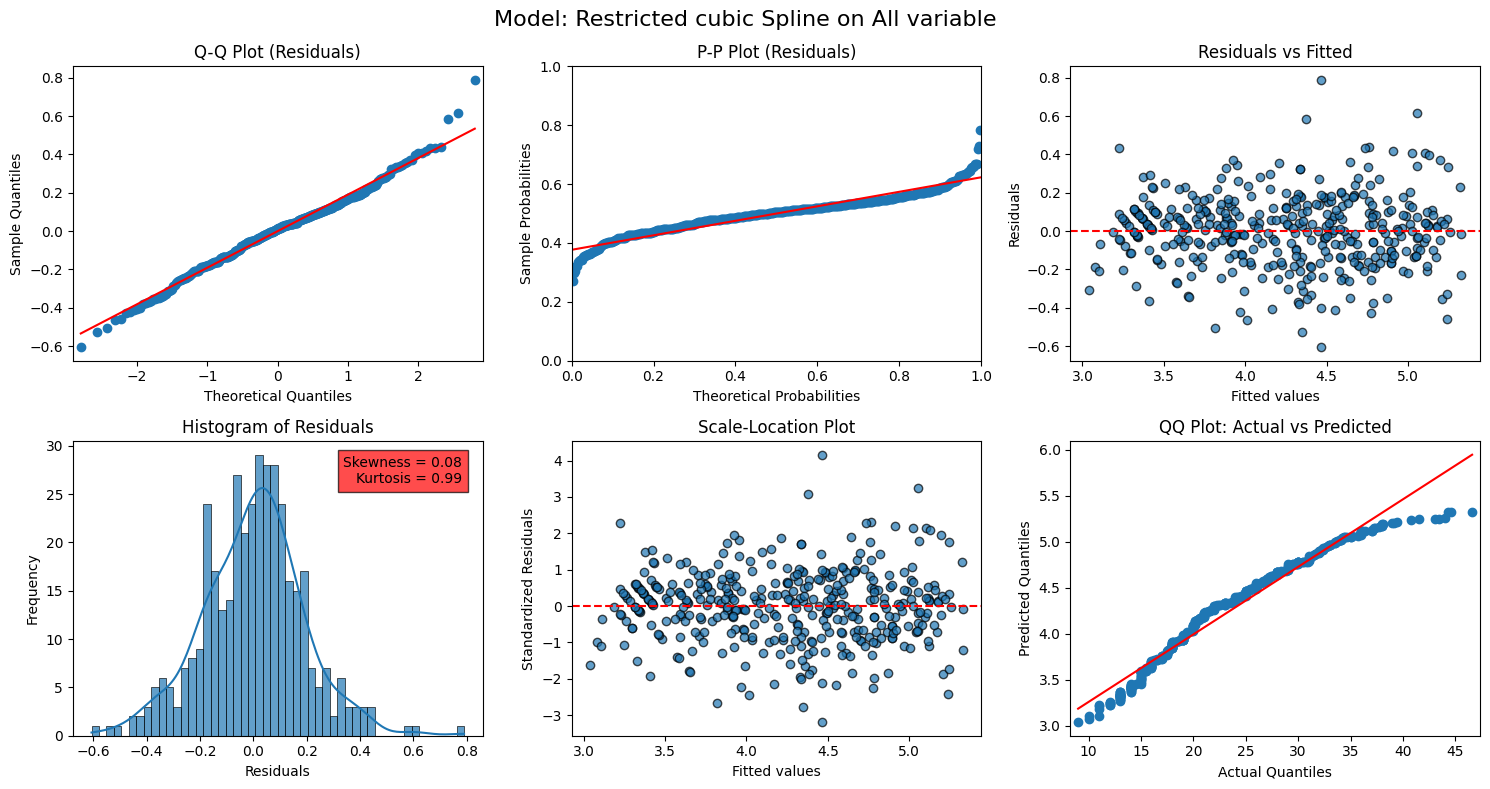

In [81]:
regression_diagnostics(results = res_model_cubic, actual = actual_y, subtitle="Model: Cubical Spline All variable")

regression_diagnostics(results = res_model_disp, actual = actual_y, subtitle="Model: Cubical Spline on Displacememnt")

regression_diagnostics(results = res_model_myr, actual = actual_y, subtitle="Model: Cubical Spline on Making Year")

regression_diagnostics(results = res_model_rcs, actual = actual_y, subtitle="Model: Restricted cubic Spline on All variable")

Summary Note – Polynomial Regression with Cubic Splines
- Polynomial regression extends linear regression by including higher‑order terms (e.g., x^2,x^3), allowing models to capture non‑linear relationships.
- Limitation: global polynomials can become unstable at boundaries, leading to oscillations or overfitting

Cubic Splines
- Splines are piecewise polynomial functions.
- Cubic splines fit cubic polynomials within segments defined by knots, ensuring smoothness (continuity of function and first two derivatives).
- Benefit: capture local non‑linear patterns without instability of global polynomials

Application to Variables
- Displacement:
- Cubic spline basis applied to displacement allows flexible modeling across its range.
- Captures local variations, avoids overfitting at extremes.
- Diagnostics confirm near‑normal residuals, stable variance, and strong predictive fit.

- Making Year:
- Cubic spline basis applied to vehicle making year captures differences between older and newer years.
- Improves model fit, ensures assumptions hold, and avoids instability at boundaries.
- Diagnostics confirm residuals are near‑normal, variance consistent, and predictive alignment strong.

Polynomial regression provides flexibility, but cubic splines make it localized, stable, and interpretable.
Applying cubic splines to displacement and making year variables improves model fit, ensures residual assumptions hold, and captures complex non‑linear effects without overfitting.
Diagnostics confirm these spline models are statistically sound and predictive